In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "catboost": "catboost",
}

for module_name, pip_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import json
import re
import textwrap
import unicodedata
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid", context="notebook")

try:
    from IPython import get_ipython

    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("Ambiente pronto para treinar e interpretar o surrogate multiclasse do Perfil Integrado (K=6).")
print("Versão do CatBoost:", CatBoostClassifier.__module__.split(".")[0])
print("Motor de SHAP:", "CatBoost nativo em lotes (modo estável)")


Ambiente pronto para treinar e interpretar o surrogate multiclasse do Perfil Integrado (K=6).
Versão do CatBoost: catboost
Motor de SHAP: CatBoost nativo em lotes (modo estável)


In [ ]:
# Configura??o padr?o para figuras vetoriais reprodut?veis
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


In [2]:
PROJECT_ROOT = Path.cwd()
INPUT_DIR = PROJECT_ROOT / "outputs_lca"
OUTPUT_ROOT = PROJECT_ROOT / "outputs_surrogate_perfil_integrado_xai"
FIG_DIR = OUTPUT_ROOT / "figuras"
TABLE_DIR = OUTPUT_ROOT / "tabelas"
MODEL_DIR = OUTPUT_ROOT / "modelos"

for directory in [OUTPUT_ROOT, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INPUT_FILES = {
    "base_com_classes": INPUT_DIR / "Base Com Classes Perfil Integrado.parquet",
    "posteriores": INPUT_DIR / "Posteriores Perfil Integrado.parquet",
    "tabela_interpretativa": INPUT_DIR / "Tabela Interpretativa Perfil Integrado.csv",
    "resumo_classes": INPUT_DIR / "Resumo Classes Perfil Integrado.csv",
    "encoders": INPUT_DIR / "Encoders Perfil Integrado.json",
}

FEATURE_COLUMNS = [
    "Sexo",
    "Faixa Etária",
    "Raça Cor",
    "Estado Civil",
    "Escolaridade",
    "Ocupação Macro",
    "Região Residência",
    "Deslocamento Geográfico",
    "Local Ocorrência Consolidado",
    "Mecanismo Lesão Autoprovocada",
    "Indício Transtorno Mental",
    "Indício Transtorno Por Substâncias",
]

EXPECTED_K = 6
LOW_CONFIDENCE_THRESHOLD = 0.60
IGNORED_LABEL = "Ignorado Ou Não Preenchido"
MISSING_TOKEN = "__MISSING__"
RANDOM_STATE = 42
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

SHAP_SAMPLE_SIZE = 6000
INTERACTION_SAMPLE_SIZE = 1500
ALE_SAMPLE_SIZE = 20000
NATIVE_SHAP_BATCH_SIZE = 1000
LOCAL_SHAP_BATCH_SIZE = 64
TOP_SHAP_FEATURES_GLOBAL = 10
TOP_SHAP_FEATURES_BY_CLASS = 6
TOP_CATEGORY_PLOT_FEATURES_GLOBAL = 4
TOP_CATEGORY_PLOT_FEATURES_BY_CLASS = 2
TOP_CATEGORIES_PER_PLOT = 8
TOP_INTERACTIONS_TO_REPORT = 15
TOP_INTERACTIONS_TO_PLOT = 4
LOCAL_TOP_FEATURES_WATERFALL = 10

ORDERED_CATEGORIES = {
    "Faixa Etária": [
        "<15",
        "15-24",
        "25-34",
        "35-44",
        "45-59",
        "60-74",
        "75+",
        "Ignorado Ou Não Preenchido",
    ],
    "Escolaridade": [
        "Sem Escolaridade",
        "Fundamental I",
        "Fundamental II",
        "Médio",
        "Superior",
        "Ignorado Ou Não Preenchido",
    ],
}

CATBOOST_PARAMS = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1:average=Macro",
    "iterations": 1500,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 8.0,
    "random_seed": RANDOM_STATE,
    "thread_count": -1,
    "verbose": 200,
    "allow_writing_files": False,
    "od_type": "Iter",
    "od_wait": 100,
}

SCENARIOS = {
    "A": {
        "nome": "Cenário A",
        "descricao": "Treino sem pesos, usando todos os registros com o mesmo peso.",
        "use_sample_weight": False,
    },
    "B": {
        "nome": "Cenário B",
        "descricao": "Treino ponderado por posterior_max do LCA.",
        "use_sample_weight": True,
    },
}

GENERATED_FILES = []

print("Projeto:", PROJECT_ROOT)
print("Entrada:", INPUT_DIR)
print("Saída:", OUTPUT_ROOT)
print("Features do surrogate:", len(FEATURE_COLUMNS))


Projeto: c:\Users\anami\Downloads\TCC Aninha
Entrada: c:\Users\anami\Downloads\TCC Aninha\outputs_lca
Saída: c:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai
Features do surrogate: 12


In [3]:
MERGE_KEY_CANDIDATES = ["Índice Original", "Indice Original", "indice_original", "index_original"]
CLASS_CANDIDATES = ["Classe Lca", "Classe LCA", "classe_lca"]
POSTERIOR_MAX_CANDIDATES = ["Prob Max Classe", "Probabilidade Posterior Máxima", "posterior_max", "prob_max_classe"]
LOW_CONF_CANDIDATES = ["Baixa Confiança", "Baixa Confianca", "flag_baixa_confianca", "baixa_confianca"]


def normalize_text(value: Any) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^0-9a-zA-Z]+", "_", text.strip().lower())
    return re.sub(r"_+", "_", text).strip("_")


def assert_required_files(file_map: dict[str, Path]) -> None:
    missing = [name for name, path in file_map.items() if not path.exists()]
    if missing:
        details = "\n".join(f"- {name}: {file_map[name]}" for name in missing)
        raise FileNotFoundError(f"Arquivos obrigatórios não encontrados:\n{details}")


def make_json_serializable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(key): make_json_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [make_json_serializable(value) for value in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def register_file(path: Path, label: str, kind: str) -> Path:
    resolved = path.resolve()
    GENERATED_FILES.append({"artefato": label, "tipo": kind, "caminho": str(resolved)})
    return resolved


def save_json(data: Any, path: Path) -> Path:
    path.write_text(
        json.dumps(make_json_serializable(data), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return register_file(path, path.stem, "json")


def save_text(text: str, path: Path) -> Path:
    path.write_text(str(text), encoding="utf-8")
    return register_file(path, path.stem, "txt")


def save_table(df: pd.DataFrame, path: Path, index: bool = False) -> Path:
    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=index)
    else:
        df.to_csv(path, index=index, encoding="utf-8-sig")
    return register_file(path, path.stem, path.suffix.lower().lstrip("."))


def save_figure(fig: plt.Figure, filename: str, label: str) -> list[Path]:
    path = FIG_DIR / filename
    stem = path.with_suffix("")
    saved_paths = []
    for suffix in [".pdf", ".svg", ".png"]:
        output_path = stem.with_suffix(suffix)
        kwargs = {"bbox_inches": "tight"}
        if suffix == ".png":
            kwargs["dpi"] = 180
        fig.savefig(output_path, **kwargs)
        register_file(output_path, label, suffix.lstrip("."))
        saved_paths.append(output_path)
    return saved_paths


def find_first_existing_column(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def sanitize_feature_frame(df: pd.DataFrame, feature_columns: list[str] = FEATURE_COLUMNS) -> pd.DataFrame:
    missing = [col for col in feature_columns if col not in df.columns]
    if missing:
        raise KeyError(f"Features obrigatórias ausentes: {missing}")
    out = df.loc[:, feature_columns].copy()
    for col in feature_columns:
        out[col] = out[col].astype("string").fillna(MISSING_TOKEN)
    return out


def flatten_predictions(pred: Any) -> np.ndarray:
    arr = np.asarray(pred)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.ravel()
    return arr


def safe_series_equal(left: pd.Series | None, right: pd.Series | None) -> bool:
    if left is None or right is None:
        return True
    return left.reset_index(drop=True).equals(right.reset_index(drop=True))


def relative_class_distribution(y: pd.Series) -> pd.DataFrame:
    counts = y.value_counts(dropna=False).sort_index()
    pct = counts / counts.sum()
    return pd.DataFrame(
        {
            "classe_lca": counts.index.astype(int),
            "n_registros": counts.values.astype(int),
            "proporcao": pct.values.astype(float),
        }
    )


def stratified_sample(
    df: pd.DataFrame,
    stratify_col: str,
    max_rows: int,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    if len(df) <= max_rows:
        return df.copy().reset_index(drop=True)

    frac = max_rows / len(df)
    parts = []
    for _, group in df.groupby(stratify_col, dropna=False, group_keys=False):
        n = min(len(group), max(1, int(round(len(group) * frac))))
        parts.append(group.sample(n=n, random_state=random_state))

    sampled = pd.concat(parts, ignore_index=False).drop_duplicates()
    if len(sampled) > max_rows:
        sampled = sampled.sample(n=max_rows, random_state=random_state)
    return sampled.sort_index().reset_index(drop=True)


def limit_categories(series: pd.Series, top_n: int = TOP_CATEGORIES_PER_PLOT) -> pd.Series:
    s = series.astype("string").fillna(MISSING_TOKEN)
    keep = s.value_counts(dropna=False).head(top_n).index
    return s.where(s.isin(keep), other="Demais Categorias")


In [4]:
def infer_probability_columns(columns: list[str]) -> dict[int, str]:
    mapping: dict[int, str] = {}
    for col in columns:
        normalized = normalize_text(col)
        match = re.search(r"(?:prob_classe|posterior_classe)_(\d+)$", normalized)
        if match:
            mapping[int(match.group(1))] = col
            continue
        match = re.search(r"(\d+)$", col.strip())
        if match and "classe" in normalized and "prob" in normalized:
            mapping[int(match.group(1))] = col
    if not mapping:
        raise ValueError("Nenhuma coluna de probabilidade posterior por classe foi identificada.")
    return dict(sorted(mapping.items(), key=lambda item: item[0]))


def rename_probability_columns(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[int]]:
    prob_map = infer_probability_columns(df.columns.tolist())
    rename_map = {original: f"posterior_classe_{class_id}" for class_id, original in prob_map.items()}
    renamed = df.rename(columns=rename_map).copy()
    class_ids = sorted(prob_map)
    probability_columns = [f"posterior_classe_{class_id}" for class_id in class_ids]
    return renamed, probability_columns, class_ids


def validate_feature_columns(base_df: pd.DataFrame, expected_features: list[str]) -> None:
    missing = [col for col in expected_features if col not in base_df.columns]
    if missing:
        raise KeyError(
            "A base com classes não contém todas as 12 features esperadas do Perfil Integrado. "
            f"Ausentes: {missing}"
        )


def standardize_base_with_classes(base_df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str]]:
    validate_feature_columns(base_df, FEATURE_COLUMNS)
    columns = base_df.columns.tolist()

    merge_key = find_first_existing_column(columns, MERGE_KEY_CANDIDATES)
    class_col = find_first_existing_column(columns, CLASS_CANDIDATES)
    prob_max_col = find_first_existing_column(columns, POSTERIOR_MAX_CANDIDATES)
    low_conf_col = find_first_existing_column(columns, LOW_CONF_CANDIDATES)

    if merge_key is None:
        raise KeyError("Nenhuma coluna de chave foi encontrada na base com classes.")
    if class_col is None:
        raise KeyError("Nenhuma coluna de classe LCA foi encontrada na base com classes.")

    rename_map = {
        merge_key: "id_registro",
        class_col: "classe_lca_base",
    }
    if prob_max_col is not None:
        rename_map[prob_max_col] = "posterior_max_base"
    if low_conf_col is not None:
        rename_map[low_conf_col] = "flag_baixa_confianca_base"

    standardized = base_df.rename(columns=rename_map).copy()
    metadata = {
        "merge_key": merge_key,
        "class_col": class_col,
        "prob_max_col": prob_max_col,
        "low_conf_col": low_conf_col,
    }
    return standardized, metadata


def standardize_posteriores(posterior_df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    columns = posterior_df.columns.tolist()
    merge_key = find_first_existing_column(columns, MERGE_KEY_CANDIDATES)
    class_col = find_first_existing_column(columns, CLASS_CANDIDATES)
    prob_max_col = find_first_existing_column(columns, POSTERIOR_MAX_CANDIDATES)
    low_conf_col = find_first_existing_column(columns, LOW_CONF_CANDIDATES)

    if merge_key is None:
        raise KeyError("Nenhuma coluna de chave foi encontrada na base de posteriores.")
    if class_col is None:
        raise KeyError("Nenhuma coluna de classe LCA foi encontrada na base de posteriores.")

    renamed, probability_columns, class_ids = rename_probability_columns(posterior_df)
    rename_map = {
        merge_key: "id_registro",
        class_col: "classe_lca_post",
    }
    if prob_max_col is not None:
        rename_map[prob_max_col] = "posterior_max_post"
    if low_conf_col is not None:
        rename_map[low_conf_col] = "flag_baixa_confianca_post"

    standardized = renamed.rename(columns=rename_map).copy()
    metadata = {
        "merge_key": merge_key,
        "class_col": class_col,
        "prob_max_col": prob_max_col,
        "low_conf_col": low_conf_col,
        "probability_columns": probability_columns,
        "class_ids": class_ids,
    }
    return standardized, metadata


In [5]:
def validate_encoders(encoders: dict[str, Any], expected_features: list[str]) -> pd.DataFrame:
    missing = sorted(set(expected_features) - set(encoders.keys()))
    extra = sorted(set(encoders.keys()) - set(expected_features))
    rows = []
    for feature in expected_features:
        encoder_info = encoders.get(feature, {})
        category_map = encoder_info.get("Categoria Para Codigo", {})
        rows.append(
            {
                "feature": feature,
                "presente_no_encoder": feature in encoders,
                "n_categorias_encoder": len(category_map),
            }
        )
    validation_df = pd.DataFrame(rows)
    validation_df["status"] = np.where(validation_df["presente_no_encoder"], "ok", "erro")
    if missing:
        raise KeyError(f"Encoders sem todas as 12 features esperadas: {missing}")
    if extra:
        print("Features extras no encoder:", extra)
    return validation_df


def standardize_resumo_classes(resumo_df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {col: normalize_text(col) for col in resumo_df.columns}
    out = resumo_df.rename(columns=rename_map).copy()
    required = {"classe_lca", "prevalencia_classe", "numero_de_registros"}
    if not required.issubset(out.columns):
        raise KeyError(f"Resumo de classes sem colunas mínimas esperadas. Encontradas: {out.columns.tolist()}")
    if "probabilidade_posterior_media" in out.columns:
        out = out.rename(columns={"probabilidade_posterior_media": "posterior_media_classe"})
    elif "posterior_media" in out.columns:
        out = out.rename(columns={"posterior_media": "posterior_media_classe"})
    out["classe_lca"] = out["classe_lca"].astype(int)
    return out.sort_values("classe_lca").reset_index(drop=True)


def standardize_interpretation_table(interpret_df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {col: normalize_text(col) for col in interpret_df.columns}
    out = interpret_df.rename(columns=rename_map).copy()
    required = {"classe_lca", "nome_interpretativo_sugerido", "descricao_narrativa_curta"}
    if not required.issubset(out.columns):
        raise KeyError(
            "Tabela interpretativa sem colunas esperadas. "
            f"Encontradas: {out.columns.tolist()}"
        )
    out["classe_lca"] = out["classe_lca"].astype(int)
    return out.sort_values("classe_lca").reset_index(drop=True)


def build_class_metadata(
    resumo_df: pd.DataFrame,
    interpret_df: pd.DataFrame,
) -> pd.DataFrame:
    keep_cols = [
        "classe_lca",
        "nome_interpretativo_sugerido",
        "descricao_narrativa_curta",
        "top_categorias_por_indicador",
    ]
    keep_cols = [col for col in keep_cols if col in interpret_df.columns]
    meta = resumo_df.merge(interpret_df[keep_cols], on="classe_lca", how="left")
    meta["nome_interpretativo_sugerido"] = meta["nome_interpretativo_sugerido"].fillna(
        meta["classe_lca"].map(lambda value: f"Classe {int(value)}")
    )
    meta["rotulo_curto"] = meta["classe_lca"].map(lambda value: f"Classe {int(value)}")
    meta["rotulo_perfil"] = meta.apply(
        lambda row: f"Classe {int(row['classe_lca'])} | {row['nome_interpretativo_sugerido']}",
        axis=1,
    )
    return meta.sort_values("classe_lca").reset_index(drop=True)


def merge_lca_outputs(
    base_df: pd.DataFrame,
    posterior_df: pd.DataFrame,
    probability_columns: list[str],
    class_ids: list[int],
) -> pd.DataFrame:
    merged = base_df.merge(
        posterior_df,
        on="id_registro",
        how="inner",
        validate="one_to_one",
    )
    if merged.empty:
        raise ValueError("A união entre base com classes e posteriores resultou em base vazia.")

    if not safe_series_equal(merged.get("classe_lca_base"), merged.get("classe_lca_post")):
        raise ValueError("A classe hard do LCA diverge entre a base com classes e a base de posteriores.")

    merged["classe_lca"] = merged["classe_lca_post"].astype(int)
    posterior_matrix = merged[probability_columns].to_numpy(dtype=float)

    if posterior_matrix.shape[1] != EXPECTED_K:
        raise ValueError(
            "O número de colunas de probabilidade posterior não coincide com o K esperado. "
            f"Esperado={EXPECTED_K}, encontrado={posterior_matrix.shape[1]}"
        )

    posterior_max_calculated = posterior_matrix.max(axis=1)
    posterior_order = np.argsort(posterior_matrix, axis=1)
    top1_idx = posterior_order[:, -1]
    top2_idx = posterior_order[:, -2]
    predicted_class_from_posteriors = np.array([class_ids[idx] for idx in top1_idx], dtype=int)
    margin_top2 = posterior_matrix[np.arange(len(merged)), top1_idx] - posterior_matrix[np.arange(len(merged)), top2_idx]

    if not np.array_equal(predicted_class_from_posteriors, merged["classe_lca"].to_numpy(dtype=int)):
        raise ValueError("A classe LCA não coincide com o argmax das probabilidades posteriores.")

    if "posterior_max_post" in merged.columns:
        if not np.allclose(
            merged["posterior_max_post"].to_numpy(dtype=float),
            posterior_max_calculated,
            atol=1e-8,
        ):
            raise ValueError("A coluna de posterior máximo diverge do máximo real dos posteriores.")
        merged["posterior_max"] = merged["posterior_max_post"].astype(float)
    else:
        merged["posterior_max"] = posterior_max_calculated

    merged["margem_top2"] = margin_top2.astype(float)
    merged["flag_baixa_confianca"] = merged["posterior_max"] < LOW_CONFIDENCE_THRESHOLD

    ordered_cols = (
        ["id_registro"]
        + FEATURE_COLUMNS
        + ["classe_lca", "posterior_max", "margem_top2", "flag_baixa_confianca"]
        + probability_columns
    )
    remaining_cols = [col for col in merged.columns if col not in ordered_cols]
    return merged.loc[:, ordered_cols + remaining_cols].copy()


def validate_against_summary(merged_df: pd.DataFrame, resumo_df: pd.DataFrame) -> pd.DataFrame:
    observed = relative_class_distribution(merged_df["classe_lca"]).rename(
        columns={"n_registros": "n_observado", "proporcao": "proporcao_observada"}
    )
    check = observed.merge(
        resumo_df[["classe_lca", "numero_de_registros", "prevalencia_classe"]],
        on="classe_lca",
        how="outer",
        validate="one_to_one",
    )
    check["dif_registros"] = check["n_observado"] - check["numero_de_registros"]
    check["dif_proporcao"] = check["proporcao_observada"] - check["prevalencia_classe"]
    return check.sort_values("classe_lca").reset_index(drop=True)


def compute_cardinality_review(df: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in feature_columns:
        series = df[col].astype("string").fillna(MISSING_TOKEN)
        mode = series.mode(dropna=False)
        rows.append(
            {
                "feature": col,
                "cardinalidade": int(series.nunique(dropna=False)),
                "pct_ignorado_ou_nao_preenchido": float((series == IGNORED_LABEL).mean()),
                "pct_missing_token": float((series == MISSING_TOKEN).mean()),
                "categoria_mais_frequente": str(mode.iloc[0]) if not mode.empty else "",
                "pct_categoria_mais_frequente": float(series.value_counts(normalize=True, dropna=False).iloc[0]),
            }
        )
    return pd.DataFrame(rows).sort_values(["cardinalidade", "feature"], ascending=[False, True]).reset_index(drop=True)


In [6]:
assert_required_files(INPUT_FILES)

base_raw = pd.read_parquet(INPUT_FILES["base_com_classes"])
posteriores_raw = pd.read_parquet(INPUT_FILES["posteriores"])
tabela_interpretativa_raw = pd.read_csv(INPUT_FILES["tabela_interpretativa"])
resumo_classes_raw = pd.read_csv(INPUT_FILES["resumo_classes"])
with INPUT_FILES["encoders"].open("r", encoding="utf-8") as fp:
    encoders = json.load(fp)

raw_shapes_df = pd.DataFrame(
    [
        {"artefato": "base_com_classes", "shape": base_raw.shape},
        {"artefato": "posteriores", "shape": posteriores_raw.shape},
        {"artefato": "tabela_interpretativa", "shape": tabela_interpretativa_raw.shape},
        {"artefato": "resumo_classes", "shape": resumo_classes_raw.shape},
    ]
)
display(raw_shapes_df)
display(base_raw.head(3))
display(posteriores_raw.head(3))
display(tabela_interpretativa_raw.head(3))
display(resumo_classes_raw.head(3))

encoder_validation_df = validate_encoders(encoders, FEATURE_COLUMNS)
resumo_classes_df = standardize_resumo_classes(resumo_classes_raw)
tabela_interpretativa_df = standardize_interpretation_table(tabela_interpretativa_raw)
class_metadata_df = build_class_metadata(resumo_classes_df, tabela_interpretativa_df)

base_std, base_meta = standardize_base_with_classes(base_raw)
posteriores_std, posteriores_meta = standardize_posteriores(posteriores_raw)

if len(posteriores_meta["class_ids"]) != EXPECTED_K:
    raise ValueError(
        f"K inferido a partir dos posteriores diferente do esperado. "
        f"Esperado={EXPECTED_K}, encontrado={posteriores_meta['class_ids']}"
    )

class_labels = posteriores_meta["class_ids"]
class_to_position = {int(cls): pos for pos, cls in enumerate(class_labels)}
class_short_map = dict(zip(class_metadata_df["classe_lca"], class_metadata_df["rotulo_curto"]))
class_profile_map = dict(zip(class_metadata_df["classe_lca"], class_metadata_df["rotulo_perfil"]))
class_name_map = dict(zip(class_metadata_df["classe_lca"], class_metadata_df["nome_interpretativo_sugerido"]))
class_palette = dict(zip(class_labels, sns.color_palette("tab10", n_colors=len(class_labels))))

merged_lca_df = merge_lca_outputs(
    base_df=base_std,
    posterior_df=posteriores_std,
    probability_columns=posteriores_meta["probability_columns"],
    class_ids=class_labels,
)

summary_check_df = validate_against_summary(merged_lca_df, resumo_classes_df)
if not np.allclose(summary_check_df["dif_registros"].fillna(0).to_numpy(), 0):
    raise ValueError("A distribuição observada diverge do resumo oficial do LCA.")

cardinality_df = compute_cardinality_review(merged_lca_df, FEATURE_COLUMNS)
class_distribution_df = relative_class_distribution(merged_lca_df["classe_lca"]).merge(
    class_metadata_df[["classe_lca", "nome_interpretativo_sugerido", "rotulo_curto", "rotulo_perfil"]],
    on="classe_lca",
    how="left",
)

review_summary_df = pd.DataFrame(
    [
        {"indicador": "n_registros", "valor": int(len(merged_lca_df))},
        {"indicador": "n_features_surrogate", "valor": int(len(FEATURE_COLUMNS))},
        {"indicador": "n_classes_lca", "valor": int(merged_lca_df["classe_lca"].nunique())},
        {
            "indicador": "pct_baixa_confianca_lca",
            "valor": float(merged_lca_df["flag_baixa_confianca"].mean()),
        },
        {
            "indicador": "posterior_max_media",
            "valor": float(merged_lca_df["posterior_max"].mean()),
        },
        {
            "indicador": "margem_top2_media",
            "valor": float(merged_lca_df["margem_top2"].mean()),
        },
    ]
)

display(encoder_validation_df)
display(pd.DataFrame([base_meta]))
display(pd.DataFrame([posteriores_meta]))
display(class_metadata_df)
display(summary_check_df)
display(class_distribution_df)
display(cardinality_df)
display(review_summary_df)

save_table(encoder_validation_df, TABLE_DIR / "validacao_encoders.csv")
save_table(class_metadata_df, TABLE_DIR / "metadados_classes_lca.csv")
save_table(summary_check_df, TABLE_DIR / "checagem_resumo_classes_lca.csv")
save_table(class_distribution_df, TABLE_DIR / "distribuicao_classes_lca.csv")
save_table(cardinality_df, TABLE_DIR / "cardinalidade_e_ignorados_por_variavel.csv")
save_table(review_summary_df, TABLE_DIR / "resumo_revisao_base.csv")
save_table(merged_lca_df, TABLE_DIR / "base_unificada_validada_surrogate.parquet")


,artefato,shape
0,base_com_classes,"(191025, 16)"
1,posteriores,"(191025, 10)"
2,tabela_interpretativa,"(6, 7)"
3,resumo_classes,"(6, 4)"


,Índice Original,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias,Classe Lca,Prob Max Classe,Baixa Confiança
0,0,Masculino,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não,0,0.999813,False
1,1,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não,0,0.996763,False
2,2,Masculino,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não,0,0.999813,False


,Índice Original,Prob Classe 0,Prob Classe 1,Prob Classe 2,Prob Classe 3,Prob Classe 4,Prob Classe 5,Classe Lca,Prob Max Classe,Baixa Confiança
0,0,0.999813,0.000002,0.000185,1.329601e-17,3.225348e-19,5.885814e-20,0,0.999813,False
1,1,0.996763,0.000042,0.003155,3.967948e-05,4.010701e-20,8.030454e-07,0,0.996763,False
2,2,0.999813,0.000002,0.000185,1.329601e-17,3.225348e-19,5.885814e-20,0,0.999813,False


,Classe Lca,Prevalência,Número De Registros,Posterior Média,Top Categorias Por Indicador,Nome Interpretativo Sugerido,Descrição Narrativa Curta
0,0,0.129122,23401,0.851426,"Deslocamento Geográfico: Outra Uf (Lift 1.10, Pct Condicional 0.01); Escolaridade: Médio (Lift 1.68, Pct Condicional 0.33); Estado Civil: Solteiro (Lift 1.87, Pct Condicional 0.96); Faixa Etária: ...",Feminino | <15 | Estudante,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Médio; Estado Civil: Solteiro; Faixa Etária: <15; Indício Transtorno Mental: Não; Indício Transtorno Por Substânc...
1,1,0.093699,17691,0.821101,"Deslocamento Geográfico: Outro Município Mesma Uf (Lift 3.27, Pct Condicional 0.36); Escolaridade: Ignorado Ou Não Preenchido (Lift 1.18, Pct Condicional 0.35); Estado Civil: Viúvo (Lift 1.31, Pct...",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe marcada principalmente por Deslocamento Geográfico: Outro Município Mesma Uf; Escolaridade: Ignorado Ou Não Preenchido; Estado Civil: Viúvo; Faixa Etária: Ignorado Ou Não Preenchido; Indíci...
2,2,0.244711,46352,0.844911,"Deslocamento Geográfico: Outra Uf (Lift 1.05, Pct Condicional 0.01); Escolaridade: Sem Escolaridade (Lift 1.98, Pct Condicional 0.08); Estado Civil: Ignorado Ou Não Preenchido (Lift 1.27, Pct Cond...",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Sem Escolaridade; Estado Civil: Ignorado Ou Não Preenchido; Faixa Etária: Ignorado Ou Não Preenchido; Indício Tra...


,Classe Lca,Prevalência Classe,Número De Registros,Probabilidade Posterior Média
0,0,0.129122,23401,0.851426
1,1,0.093699,17691,0.821101
2,2,0.244711,46352,0.844911


...

,classe_lca,n_observado,proporcao_observada,numero_de_registros,prevalencia_classe,dif_registros,dif_proporcao
0,0,23401,0.122502,23401,0.129122,0,-0.006620
1,1,17691,0.092611,17691,0.093699,0,-0.001088
2,2,46352,0.242649,46352,0.244711,0,-0.002062
3,3,21874,0.114509,21874,0.118748,0,-0.004240
4,4,30076,0.157445,30076,0.163192,0,-0.005746
5,5,51631,0.270284,51631,0.250528,0,0.019756


,classe_lca,n_registros,proporcao,nome_interpretativo_sugerido,rotulo_curto,rotulo_perfil
0,0,23401,0.122502,Feminino | <15 | Estudante,Classe 0,Classe 0 | Feminino | <15 | Estudante
1,1,17691,0.092611,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção
2,2,46352,0.242649,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária
3,3,21874,0.114509,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público
4,4,30076,0.157445,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista
5,5,51631,0.270284,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção


,feature,cardinalidade,pct_ignorado_ou_nao_preenchido,pct_missing_token,categoria_mais_frequente,pct_categoria_mais_frequente
0,Ocupação Macro,11,0.000000,0.0,Desocupado Ou Não Informado,0.246706
1,Mecanismo Lesão Autoprovocada,10,0.000000,0.0,"Enforcamento, Estrangulamento E Sufocação",0.688344
2,Faixa Etária,8,0.002015,0.0,45-59,0.235126
3,Local Ocorrência Consolidado,7,0.000000,0.0,Residência,0.644177
4,Escolaridade,6,0.300065,0.0,Ignorado Ou Não Preenchido,0.300065
5,Raça Cor,6,0.020851,0.0,Branca,0.484612
6,Estado Civil,5,0.078969,0.0,Solteiro,0.514608
7,Região Residência,5,0.000000,0.0,Sudeste,0.369606
8,Deslocamento Geográfico,3,0.000000,0.0,Mesmo Município,0.879026
9,Sexo,3,0.000173,0.0,Masculino,0.784269


,indicador,valor
0,n_registros,191025.000000
1,n_features_surrogate,12.000000
2,n_classes_lca,6.000000
3,pct_baixa_confianca_lca,0.162743
4,posterior_max_media,0.826000
5,margem_top2_media,0.688607


WindowsPath('C:/Users/anami/Downloads/TCC Aninha/outputs_surrogate_perfil_integrado_xai/tabelas/base_unificada_validada_surrogate.parquet')

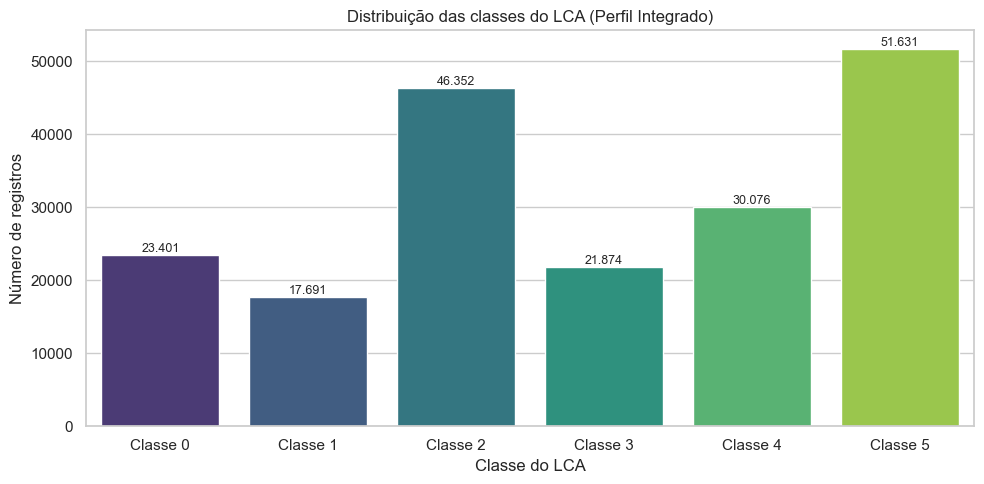

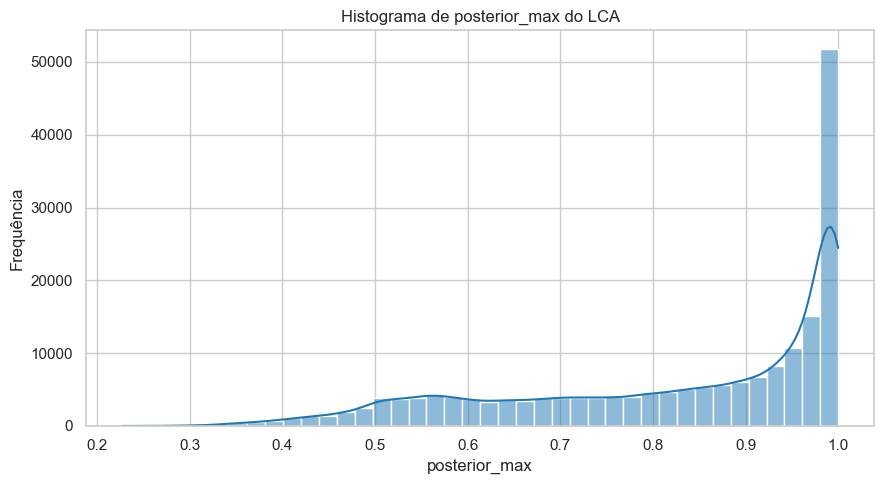

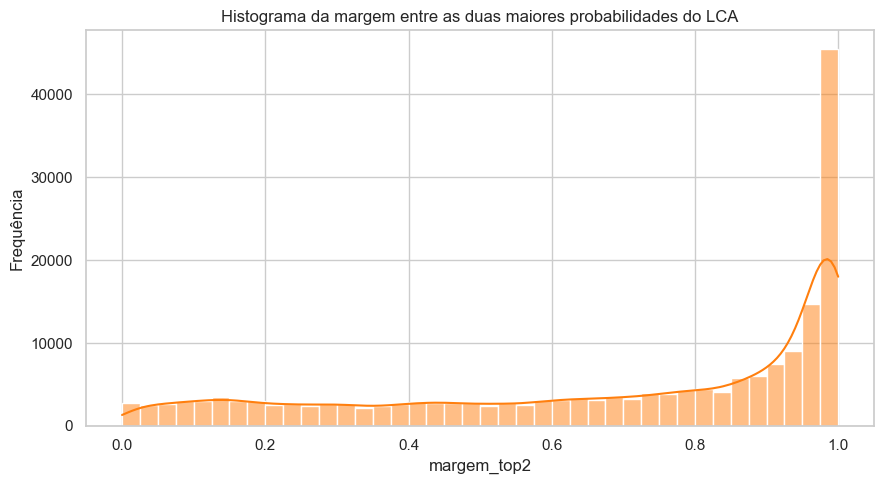

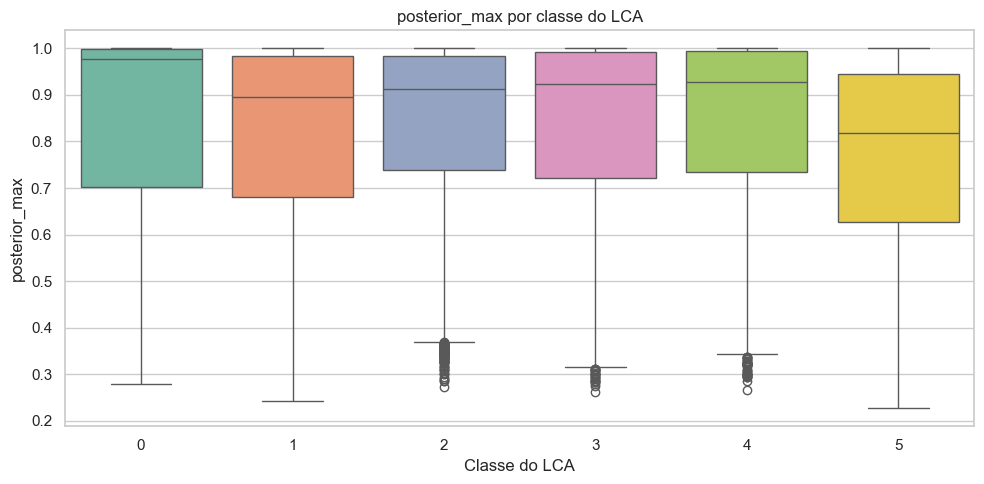

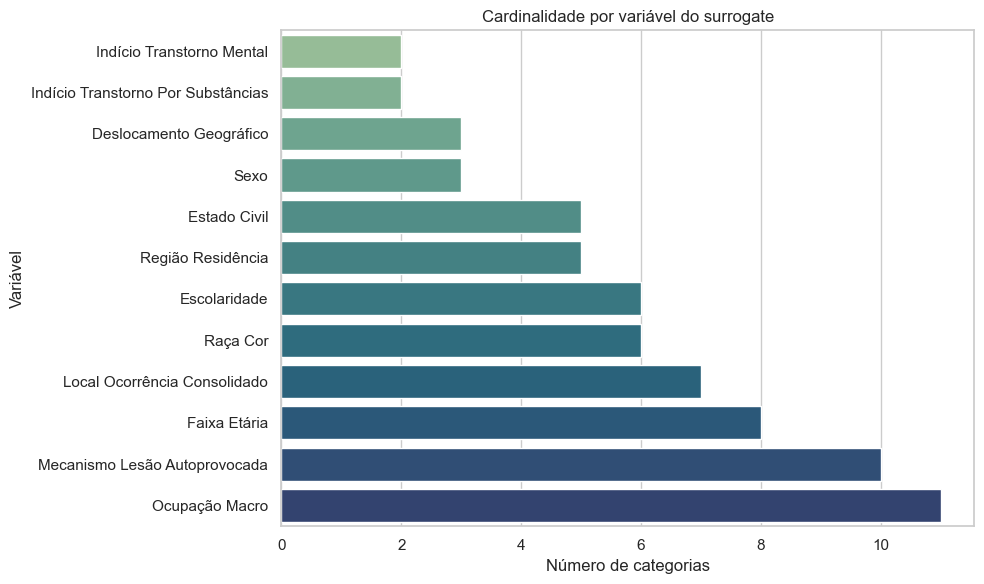

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = class_distribution_df.sort_values("classe_lca").copy()
sns.barplot(data=plot_df, x="rotulo_curto", y="n_registros", palette="viridis", ax=ax)
ax.set_title("Distribuição das classes do LCA (Perfil Integrado)")
ax.set_xlabel("Classe do LCA")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=0)
for patch, value in zip(ax.patches, plot_df["n_registros"]):
    ax.annotate(f"{int(value):,}".replace(",", "."), (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
save_figure(fig, "distribuicao_classes_lca.png", "distribuicao_classes_lca")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(merged_lca_df["posterior_max"], bins=40, kde=True, color="#1f77b4", ax=ax)
ax.set_title("Histograma de posterior_max do LCA")
ax.set_xlabel("posterior_max")
ax.set_ylabel("Frequência")
fig.tight_layout()
save_figure(fig, "histograma_posterior_max_lca.png", "histograma_posterior_max_lca")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(merged_lca_df["margem_top2"], bins=40, kde=True, color="#ff7f0e", ax=ax)
ax.set_title("Histograma da margem entre as duas maiores probabilidades do LCA")
ax.set_xlabel("margem_top2")
ax.set_ylabel("Frequência")
fig.tight_layout()
save_figure(fig, "histograma_margem_top2_lca.png", "histograma_margem_top2_lca")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=merged_lca_df, x="classe_lca", y="posterior_max", palette="Set2", ax=ax)
ax.set_title("posterior_max por classe do LCA")
ax.set_xlabel("Classe do LCA")
ax.set_ylabel("posterior_max")
fig.tight_layout()
save_figure(fig, "boxplot_posterior_max_por_classe_lca.png", "boxplot_posterior_max_por_classe_lca")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = cardinality_df.sort_values("cardinalidade", ascending=True)
sns.barplot(data=plot_df, x="cardinalidade", y="feature", palette="crest", ax=ax)
ax.set_title("Cardinalidade por variável do surrogate")
ax.set_xlabel("Número de categorias")
ax.set_ylabel("Variável")
fig.tight_layout()
save_figure(fig, "cardinalidade_por_variavel.png", "cardinalidade_por_variavel")
plt.show()
plt.close(fig)


In [8]:
def build_modeling_frame(merged_df: pd.DataFrame) -> pd.DataFrame:
    required = FEATURE_COLUMNS + ["id_registro", "classe_lca", "posterior_max", "margem_top2", "flag_baixa_confianca"]
    missing = [col for col in required if col not in merged_df.columns]
    if missing:
        raise KeyError(f"Colunas obrigatórias ausentes para modelagem: {missing}")
    return merged_df.loc[:, required].copy()


def create_split_indices(df: pd.DataFrame) -> dict[str, np.ndarray]:
    idx_all = df.index.to_numpy()
    y = df["classe_lca"].astype(int)

    idx_train_val, idx_test = train_test_split(
        idx_all,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    val_relative_size = VALIDATION_SIZE / (1 - TEST_SIZE)
    idx_train, idx_val = train_test_split(
        idx_train_val,
        test_size=val_relative_size,
        random_state=RANDOM_STATE,
        stratify=df.loc[idx_train_val, "classe_lca"].astype(int),
    )

    return {
        "train": np.sort(idx_train),
        "val": np.sort(idx_val),
        "test": np.sort(idx_test),
        "train_val": np.sort(idx_train_val),
    }


def build_split_frame(df: pd.DataFrame, split_indices: dict[str, np.ndarray]) -> pd.DataFrame:
    split_series = pd.Series(index=df.index, dtype="string")
    for split_name in ["train", "val", "test"]:
        split_series.loc[split_indices[split_name]] = split_name
    return pd.DataFrame(
        {
            "indice_df": df.index,
            "id_registro": df["id_registro"].values,
            "split": split_series.values,
        }
    )


def build_catboost_classifier(iterations: int | None = None, use_early_stopping: bool = True) -> CatBoostClassifier:
    params = CATBOOST_PARAMS.copy()
    if iterations is not None:
        params["iterations"] = int(iterations)
    if not use_early_stopping:
        params.pop("od_type", None)
        params.pop("od_wait", None)
    return CatBoostClassifier(**params)


def extract_xyw(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, np.ndarray]:
    X = sanitize_feature_frame(df, FEATURE_COLUMNS)
    y = df["classe_lca"].astype(int).copy()
    sample_weight = np.clip(df["posterior_max"].to_numpy(dtype=float), 1e-6, None)
    return X, y, sample_weight


def evaluate_predictions(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    class_labels: list[int],
) -> dict[str, Any]:
    y_true_arr = np.asarray(y_true, dtype=int)
    y_pred_arr = np.asarray(y_pred, dtype=int)

    accuracy = accuracy_score(y_true_arr, y_pred_arr)
    balanced_acc = balanced_accuracy_score(y_true_arr, y_pred_arr)
    macro_f1 = f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0)

    report_dict = classification_report(
        y_true_arr,
        y_pred_arr,
        labels=class_labels,
        target_names=[f"Classe {cls}" for cls in class_labels],
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "grupo"})

    conf = confusion_matrix(y_true_arr, y_pred_arr, labels=class_labels)
    conf_df = pd.DataFrame(
        conf,
        index=[f"Classe {cls}" for cls in class_labels],
        columns=[f"Classe {cls}" for cls in class_labels],
    )

    precision, recall, f1_values, support = precision_recall_fscore_support(
        y_true_arr,
        y_pred_arr,
        labels=class_labels,
        zero_division=0,
    )
    n_preditos = conf.sum(axis=0)
    per_class_df = pd.DataFrame(
        {
            "classe_lca": class_labels,
            "precision": precision,
            "recall": recall,
            "f1": f1_values,
            "support": support.astype(int),
            "n_preditos": n_preditos.astype(int),
            "support_pct": support / support.sum(),
        }
    )
    per_class_df["rotulo_curto"] = per_class_df["classe_lca"].map(class_short_map)
    per_class_df["rotulo_perfil"] = per_class_df["classe_lca"].map(class_profile_map)

    summary_metrics = {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    }
    return {
        "summary_metrics": summary_metrics,
        "classification_report_df": report_df,
        "confusion_matrix_df": conf_df,
        "per_class_df": per_class_df,
    }


def build_prediction_frame(
    model: CatBoostClassifier,
    df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    X = sanitize_feature_frame(df, FEATURE_COLUMNS)
    pred = flatten_predictions(model.predict(X)).astype(int)
    prob = model.predict_proba(X)

    prediction_df = df.loc[:, ["id_registro"] + FEATURE_COLUMNS + ["classe_lca", "posterior_max", "margem_top2", "flag_baixa_confianca"]].copy()
    prediction_df["split"] = split_name
    prediction_df["classe_prevista_catboost"] = pred
    for pos, cls in enumerate(model.classes_):
        prediction_df[f"prob_catboost_classe_{int(cls)}"] = prob[:, pos]
    prob_cols = [col for col in prediction_df.columns if col.startswith("prob_catboost_classe_")]
    sorted_prob = np.sort(prob, axis=1)
    prediction_df["prob_max_catboost"] = prediction_df[prob_cols].max(axis=1)
    prediction_df["margem_top2_catboost"] = sorted_prob[:, -1] - sorted_prob[:, -2]
    prediction_df["acertou_classe"] = prediction_df["classe_lca"] == prediction_df["classe_prevista_catboost"]
    return prediction_df


def fit_single_scenario(
    scenario_key: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    class_labels: list[int],
) -> dict[str, Any]:
    scenario_config = SCENARIOS[scenario_key]
    X_train, y_train, sample_weight = extract_xyw(train_df)
    X_val, y_val, _ = extract_xyw(val_df)

    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=FEATURE_COLUMNS,
        weight=sample_weight if scenario_config["use_sample_weight"] else None,
    )
    val_pool = Pool(
        data=X_val,
        label=y_val,
        cat_features=FEATURE_COLUMNS,
    )

    model = build_catboost_classifier(use_early_stopping=True)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_pred = flatten_predictions(model.predict(X_val)).astype(int)
    val_prob = model.predict_proba(X_val)
    evaluation = evaluate_predictions(y_val, val_pred, class_labels)

    validation_predictions = val_df.loc[:, ["id_registro"] + FEATURE_COLUMNS + ["classe_lca", "posterior_max", "margem_top2", "flag_baixa_confianca"]].copy()
    validation_predictions["classe_prevista_catboost"] = val_pred
    for pos, cls in enumerate(model.classes_):
        validation_predictions[f"prob_catboost_classe_{int(cls)}"] = val_prob[:, pos]
    prob_cols = [col for col in validation_predictions.columns if col.startswith("prob_catboost_classe_")]
    validation_predictions["prob_max_catboost"] = validation_predictions[prob_cols].max(axis=1)
    validation_predictions["acertou_classe"] = validation_predictions["classe_lca"] == validation_predictions["classe_prevista_catboost"]

    return {
        "scenario_key": scenario_key,
        "scenario_nome": scenario_config["nome"],
        "scenario_descricao": scenario_config["descricao"],
        "use_sample_weight": scenario_config["use_sample_weight"],
        "model": model,
        "best_iteration": int(model.get_best_iteration()) if model.get_best_iteration() is not None else -1,
        "validation": evaluation,
        "validation_predictions": validation_predictions,
    }


In [9]:
def compare_scenarios(results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for scenario_key, result in results.items():
        metrics = result["validation"]["summary_metrics"]
        rows.append(
            {
                "scenario_key": scenario_key,
                "scenario_nome": result["scenario_nome"],
                "descricao": result["scenario_descricao"],
                "usa_peso_posterior_max": result["use_sample_weight"],
                "accuracy_val": metrics["accuracy"],
                "balanced_accuracy_val": metrics["balanced_accuracy"],
                "macro_f1_val": metrics["macro_f1"],
                "weighted_f1_val": metrics["weighted_f1"],
                "best_iteration": result["best_iteration"],
            }
        )
    comparison = pd.DataFrame(rows).sort_values(
        by=["macro_f1_val", "balanced_accuracy_val", "accuracy_val", "scenario_key"],
        ascending=[False, False, False, True],
    )
    comparison["ranking"] = range(1, len(comparison) + 1)
    comparison["criterio_escolha"] = "macro_f1_val > balanced_accuracy_val > accuracy_val"
    return comparison.reset_index(drop=True)


def retrain_final_model(
    scenario_key: str,
    train_val_df: pd.DataFrame,
    reference_best_iteration: int,
) -> CatBoostClassifier:
    X_train_val, y_train_val, sample_weight = extract_xyw(train_val_df)
    use_weights = SCENARIOS[scenario_key]["use_sample_weight"]
    final_iterations = reference_best_iteration + 1 if reference_best_iteration is not None and reference_best_iteration >= 0 else CATBOOST_PARAMS["iterations"]
    final_iterations = max(final_iterations, 50)

    train_val_pool = Pool(
        data=X_train_val,
        label=y_train_val,
        cat_features=FEATURE_COLUMNS,
        weight=sample_weight if use_weights else None,
    )

    model = build_catboost_classifier(iterations=final_iterations, use_early_stopping=False)
    model.fit(train_val_pool, verbose=200)
    return model


def feature_importance_table(model: CatBoostClassifier) -> pd.DataFrame:
    importance_df = model.get_feature_importance(prettified=True).rename(
        columns={"Feature Id": "feature", "Importances": "importance"}
    )
    importance_df["ordem"] = range(1, len(importance_df) + 1)
    return importance_df.loc[:, ["ordem", "feature", "importance"]]


def plot_confusion_heatmap(conf_df: pd.DataFrame, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def plot_metric_by_class(per_class_df: pd.DataFrame, metric_col: str, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = per_class_df.sort_values("classe_lca").copy()
    sns.barplot(data=plot_df, x="rotulo_curto", y=metric_col, palette="Set2", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Classe")
    ax.set_ylabel(metric_col)
    ax.set_ylim(0, 1.05)
    for patch, value in zip(ax.patches, plot_df[metric_col]):
        ax.annotate(f"{value:.3f}", (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def plot_scenario_comparison(scenario_comparison_df: pd.DataFrame, filename: str) -> None:
    plot_df = scenario_comparison_df.melt(
        id_vars=["scenario_key", "scenario_nome"],
        value_vars=["accuracy_val", "balanced_accuracy_val", "macro_f1_val", "weighted_f1_val"],
        var_name="metrica",
        value_name="valor",
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=plot_df, x="metrica", y="valor", hue="scenario_nome", ax=ax)
    ax.set_title("Comparação entre cenários na validação")
    ax.set_xlabel("Métrica")
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1.05)
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def determine_fidelity_level(metrics: dict[str, float]) -> str:
    mean_score = np.mean([
        metrics["accuracy"],
        metrics["balanced_accuracy"],
        metrics["macro_f1"],
        metrics["weighted_f1"],
    ])
    if mean_score >= 0.90:
        return "muito alta"
    if mean_score >= 0.80:
        return "alta"
    if mean_score >= 0.70:
        return "moderada"
    if mean_score >= 0.60:
        return "razoável"
    return "baixa"


def determine_xai_readiness(metrics: dict[str, float], per_class_df: pd.DataFrame) -> str:
    min_recall = float(per_class_df["recall"].min())
    min_f1 = float(per_class_df["f1"].min())
    if (
        metrics["accuracy"] >= 0.80
        and metrics["balanced_accuracy"] >= 0.75
        and metrics["macro_f1"] >= 0.75
        and min_recall >= 0.50
        and min_f1 >= 0.50
    ):
        return "Apto para a etapa interpretativa do artigo/TCC."
    if (
        metrics["accuracy"] >= 0.70
        and metrics["balanced_accuracy"] >= 0.65
        and metrics["macro_f1"] >= 0.65
    ):
        return "Parcialmente apto para a etapa interpretativa, com cautela nas classes mais difíceis."
    return "Ainda não apto para interpretação final sem ressalvas."


,split,n_registros,percentual
0,train,133717,0.699997
1,val,28654,0.150001
2,test,28654,0.150001
3,train_val,162371,0.849999


,classe_lca,n_registros,proporcao,split
0,0,16381,0.122505,train
1,1,12383,0.092606,train
2,2,32446,0.242647,train
3,3,15312,0.114510,train
4,4,21054,0.157452,train
5,5,36141,0.270280,train
6,0,3510,0.122496,val
7,1,2654,0.092622,val
8,2,6953,0.242654,val
9,3,3281,0.114504,val


Treinando Cenário A...
0:	learn: 0.7137569	test: 0.7151398	best: 0.7151398 (0)	total: 1.72s	remaining: 43m 4s
200:	learn: 0.9469652	test: 0.9494406	best: 0.9494406 (200)	total: 8m 26s	remaining: 54m 32s
400:	learn: 0.9673151	test: 0.9666242	best: 0.9668451 (399)	total: 25m 27s	remaining: 1h 9m 47s
600:	learn: 0.9716904	test: 0.9704467	best: 0.9704812 (598)	total: 38m 32s	remaining: 57m 39s
800:	learn: 0.9750451	test: 0.9731925	best: 0.9734104 (794)	total: 56m 13s	remaining: 49m 3s
1000:	learn: 0.9770497	test: 0.9745474	best: 0.9746584 (996)	total: 1h 5m 3s	remaining: 32m 25s
1200:	learn: 0.9787009	test: 0.9761766	best: 0.9762683 (1196)	total: 1h 11m 36s	remaining: 17m 49s
1400:	learn: 0.9802637	test: 0.9773689	best: 0.9775849 (1387)	total: 1h 18m 47s	remaining: 5m 34s
1499:	learn: 0.9809006	test: 0.9781418	best: 0.9781418 (1497)	total: 1h 24m 45s	remaining: 0us

bestTest = 0.978141814
bestIteration = 1497

Shrink model to first 1498 iterations.


,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,0.979444,0.977039,0.978142,0.979436


,classe_lca,precision,recall,f1,support,n_preditos,support_pct,rotulo_curto,rotulo_perfil
0,0,0.986514,0.979487,0.982988,3510,3485,0.122496,Classe 0,Classe 0 | Feminino | <15 | Estudante
1,1,0.971970,0.966843,0.969399,2654,2640,0.092622,Classe 1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção
2,2,0.978614,0.987200,0.982888,6953,7014,0.242654,Classe 2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária
3,3,0.980591,0.970131,0.975333,3281,3246,0.114504,Classe 3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público
4,4,0.978000,0.975615,0.976806,4511,4500,0.157430,Classe 4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista
5,5,0.979920,0.982957,0.981436,7745,7769,0.270294,Classe 5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção


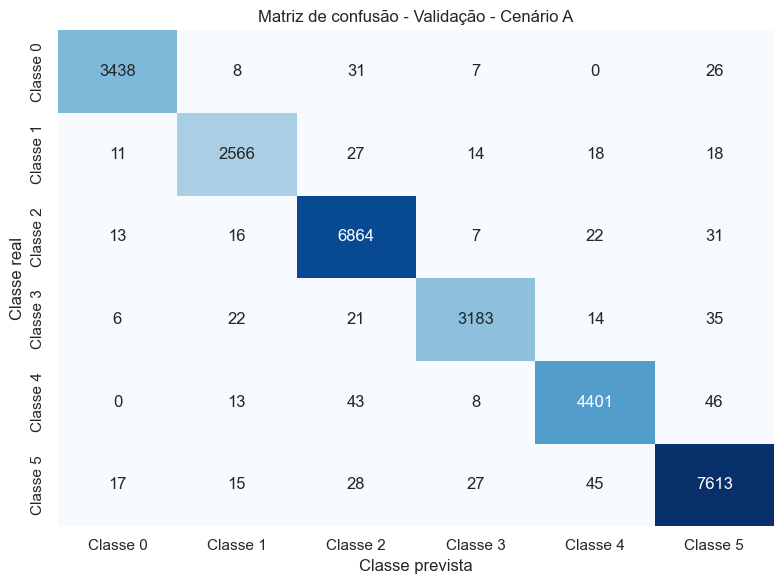

Treinando Cenário B...
0:	learn: 0.7514469	test: 0.7149792	best: 0.7149792 (0)	total: 5.3s	remaining: 2h 12m 32s
200:	learn: 0.9642812	test: 0.9455102	best: 0.9455102 (200)	total: 15m 51s	remaining: 1h 42m 31s
400:	learn: 0.9752089	test: 0.9596934	best: 0.9599692 (394)	total: 29m 1s	remaining: 1h 19m 33s
600:	learn: 0.9785254	test: 0.9638018	best: 0.9641380 (591)	total: 38m 18s	remaining: 57m 17s
800:	learn: 0.9809193	test: 0.9673742	best: 0.9673742 (797)	total: 52m 17s	remaining: 45m 38s
1000:	learn: 0.9824426	test: 0.9687675	best: 0.9689917 (970)	total: 1h 7m 30s	remaining: 33m 39s
1200:	learn: 0.9840213	test: 0.9710128	best: 0.9710128 (1200)	total: 1h 24m 17s	remaining: 20m 59s
1400:	learn: 0.9851085	test: 0.9725324	best: 0.9730684 (1382)	total: 1h 41m 44s	remaining: 7m 11s
1499:	learn: 0.9855625	test: 0.9735134	best: 0.9739964 (1463)	total: 1h 50m 30s	remaining: 0us

bestTest = 0.9739964172
bestIteration = 1463

Shrink model to first 1464 iterations.


,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,0.97571,0.972418,0.973996,0.975695


,classe_lca,precision,recall,f1,support,n_preditos,support_pct,rotulo_curto,rotulo_perfil
0,0,0.982461,0.973504,0.977962,3510,3478,0.122496,Classe 0,Classe 0 | Feminino | <15 | Estudante
1,1,0.966527,0.957423,0.961953,2654,2629,0.092622,Classe 1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção
2,2,0.974794,0.984467,0.979606,6953,7022,0.242654,Classe 2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária
3,3,0.977812,0.967083,0.972418,3281,3245,0.114504,Classe 3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público
4,4,0.977217,0.969851,0.973520,4511,4477,0.157430,Classe 4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista
5,5,0.974881,0.982182,0.978518,7745,7803,0.270294,Classe 5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção


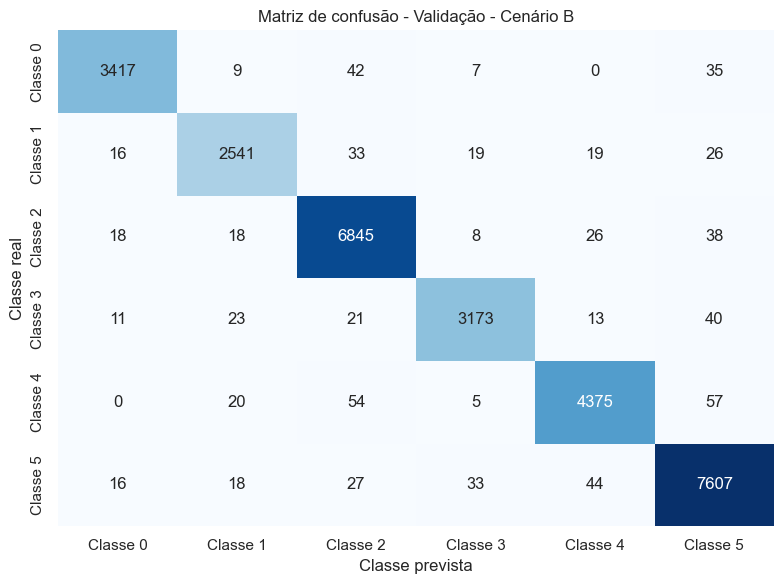

,scenario_key,scenario_nome,descricao,usa_peso_posterior_max,accuracy_val,balanced_accuracy_val,macro_f1_val,weighted_f1_val,best_iteration,ranking,criterio_escolha
0,A,Cenário A,"Treino sem pesos, usando todos os registros com o mesmo peso.",False,0.979444,0.977039,0.978142,0.979436,1497,1,macro_f1_val > balanced_accuracy_val > accuracy_val
1,B,Cenário B,Treino ponderado por posterior_max do LCA.,True,0.975710,0.972418,0.973996,0.975695,1463,2,macro_f1_val > balanced_accuracy_val > accuracy_val


Melhor cenário selecionado: Cenário A A
Best iteration de referência: 1497
0:	learn: 0.7138856	total: 4.54s	remaining: 1h 53m 15s
200:	learn: 0.9473986	total: 14m 20s	remaining: 1h 32m 29s
400:	learn: 0.9677721	total: 35m 20s	remaining: 1h 36m 41s
600:	learn: 0.9736515	total: 55m 33s	remaining: 1h 22m 55s
800:	learn: 0.9763060	total: 1h 16m 1s	remaining: 1h 6m 9s
1000:	learn: 0.9781077	total: 1h 27m 8s	remaining: 43m 15s
1200:	learn: 0.9796464	total: 1h 39m 14s	remaining: 24m 32s
1400:	learn: 0.9813236	total: 1h 58m 14s	remaining: 8m 11s
1497:	learn: 0.9818946	total: 2h 9m 31s	remaining: 0us


,scenario_key,scenario_nome,accuracy,balanced_accuracy,macro_f1,weighted_f1,n_total,n_train,n_val,n_test,fidelity_nivel,xai_readiness
0,A,Cenário A,0.979654,0.977698,0.978106,0.979648,191025,133717,28654,28654,muito alta,Apto para a etapa interpretativa do artigo/TCC.


,classe_lca,precision,recall,f1,support,n_preditos,support_pct,rotulo_curto,rotulo_perfil
0,0,0.984046,0.984046,0.984046,3510,3510,0.122496,Classe 0,Classe 0 | Feminino | <15 | Estudante
1,1,0.970443,0.964959,0.967693,2654,2639,0.092622,Classe 1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção
2,2,0.982640,0.985042,0.983840,6953,6970,0.242654,Classe 2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária
3,3,0.973756,0.972569,0.973163,3281,3277,0.114504,Classe 3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público
4,4,0.979560,0.977389,0.978473,4511,4501,0.157430,Classe 4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista
5,5,0.980663,0.982182,0.981422,7745,7757,0.270294,Classe 5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção


,grupo,precision,recall,f1-score,support
0,Classe 0,0.984046,0.984046,0.984046,3510.000000
1,Classe 1,0.970443,0.964959,0.967693,2654.000000
2,Classe 2,0.982640,0.985042,0.983840,6953.000000
3,Classe 3,0.973756,0.972569,0.973163,3281.000000
4,Classe 4,0.979560,0.977389,0.978473,4511.000000
5,Classe 5,0.980663,0.982182,0.981422,7745.000000
6,accuracy,0.979654,0.979654,0.979654,0.979654
7,macro avg,0.978518,0.977698,0.978106,28654.000000
8,weighted avg,0.979646,0.979654,0.979648,28654.000000


,Classe 0,Classe 1,Classe 2,Classe 3,Classe 4,Classe 5
Classe 0,3454,9,31,9,0,7
Classe 1,6,2561,27,14,17,29
Classe 2,17,14,6849,16,19,38
Classe 3,10,15,13,3191,14,38
Classe 4,0,14,30,20,4409,38
Classe 5,23,26,20,27,42,7607


,ordem,feature,importance
0,1,Faixa Etária,19.284729
1,2,Ocupação Macro,16.507579
2,3,Região Residência,14.731159
3,4,Escolaridade,12.139556
4,5,Mecanismo Lesão Autoprovocada,9.232158
5,6,Estado Civil,8.843982
6,7,Raça Cor,7.857647
7,8,Local Ocorrência Consolidado,5.819807
8,9,Sexo,2.511839
9,10,Deslocamento Geográfico,1.852898


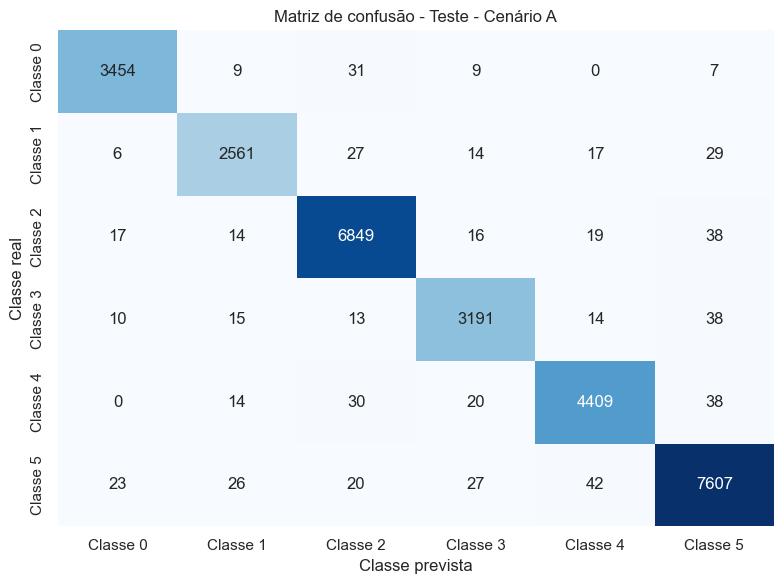

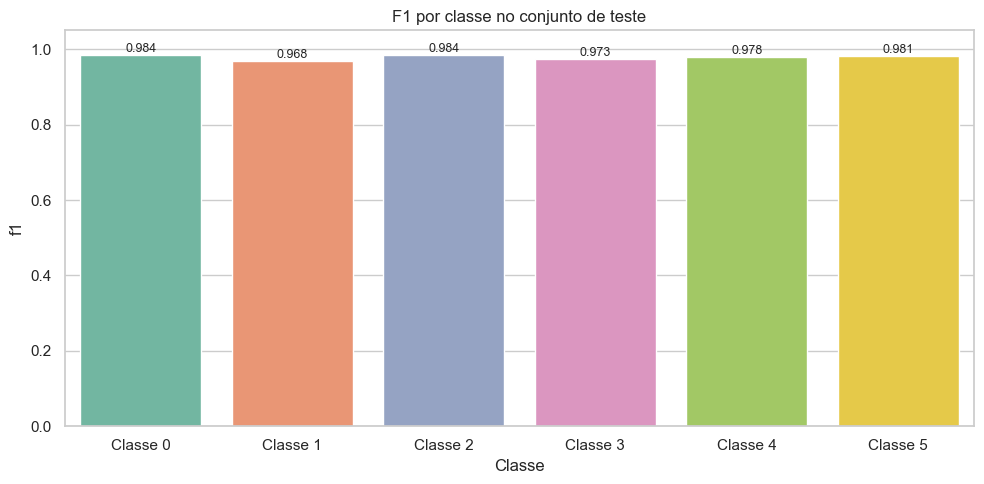

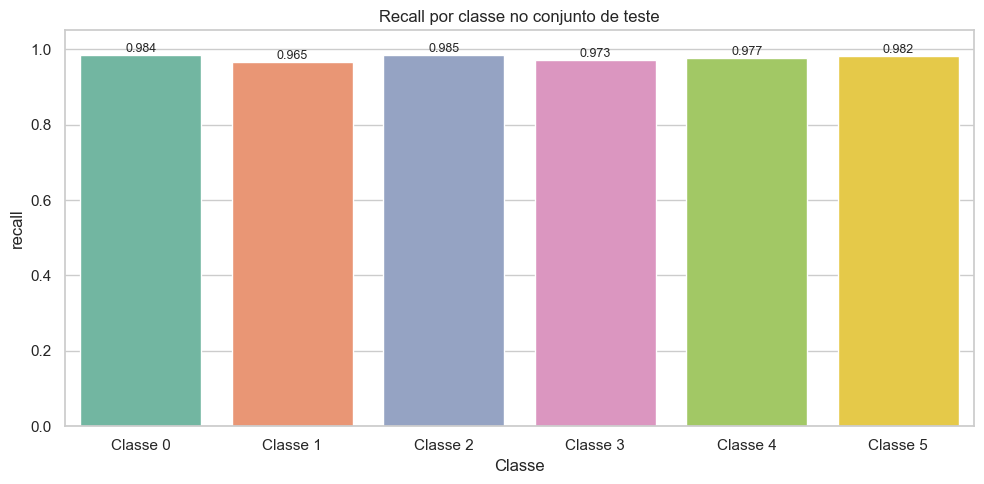

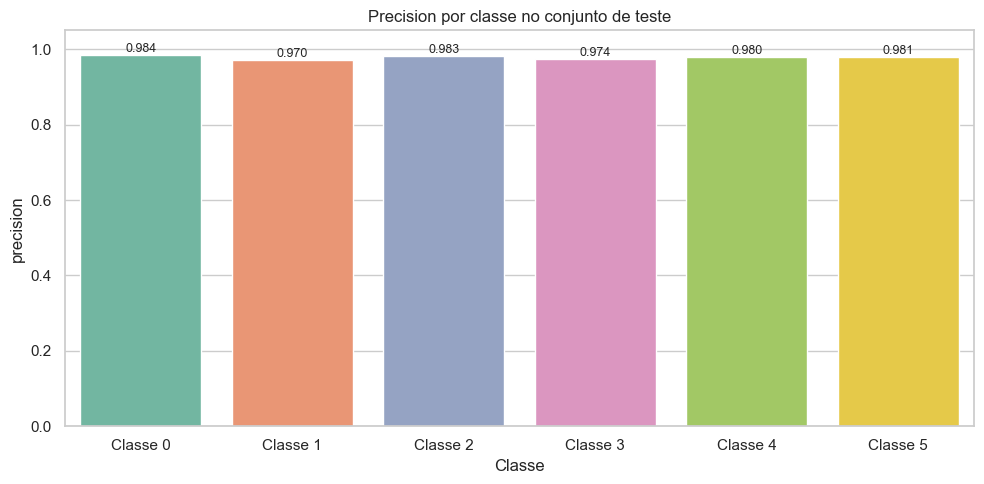

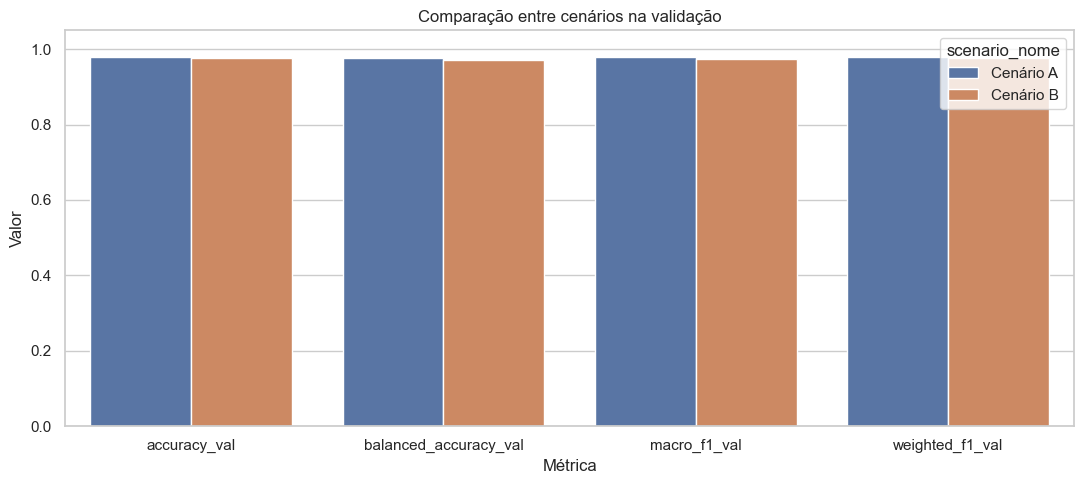

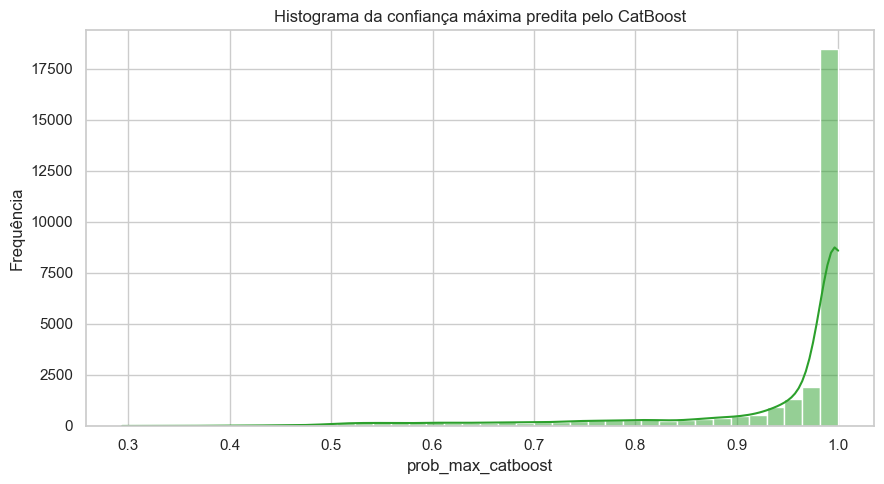

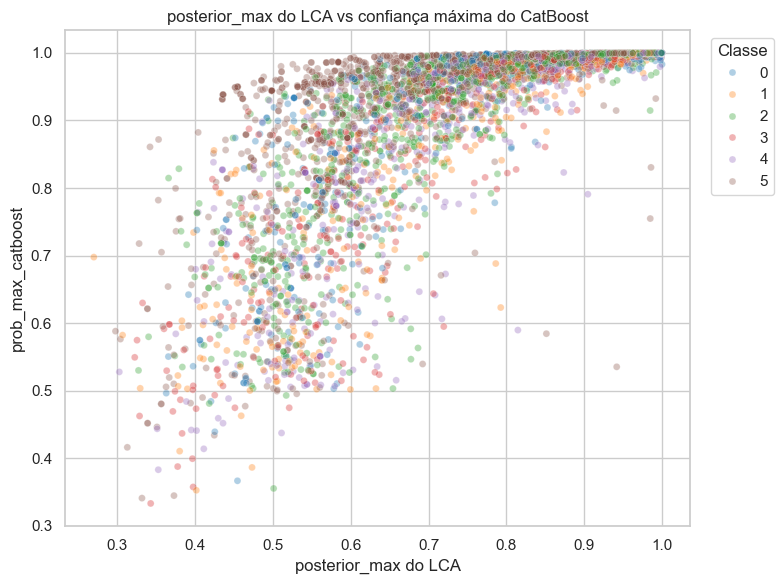

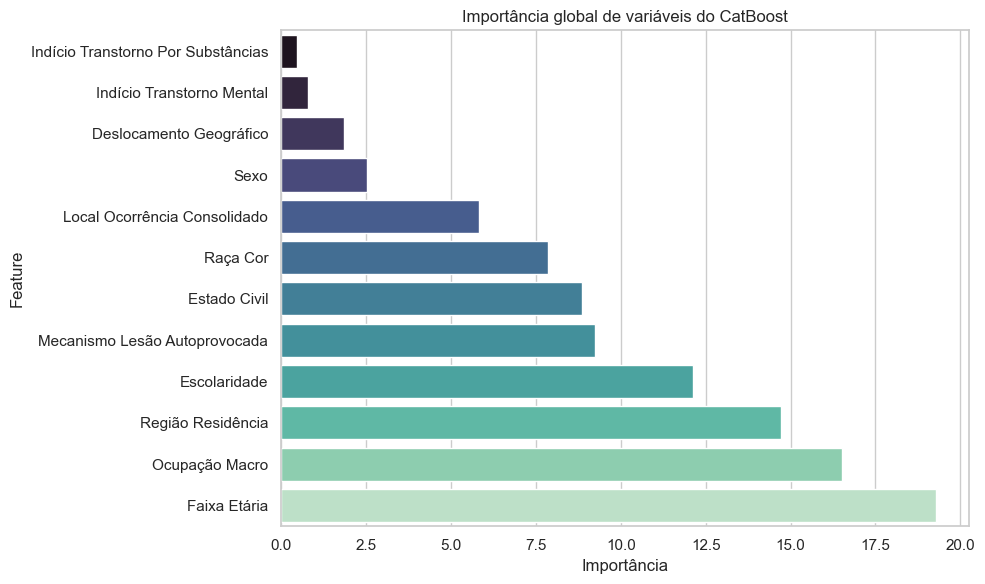

In [10]:
modeling_df = build_modeling_frame(merged_lca_df)
save_table(modeling_df, TABLE_DIR / "base_modelagem_surrogate.parquet")

split_indices = create_split_indices(modeling_df)
split_map_df = build_split_frame(modeling_df, split_indices)

train_df = modeling_df.loc[split_indices["train"]].reset_index(drop=True)
val_df = modeling_df.loc[split_indices["val"]].reset_index(drop=True)
test_df = modeling_df.loc[split_indices["test"]].reset_index(drop=True)
train_val_df = modeling_df.loc[split_indices["train_val"]].reset_index(drop=True)

split_summary_rows = []
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df), ("train_val", train_val_df)]:
    dist = relative_class_distribution(split_df["classe_lca"])
    dist["split"] = split_name
    split_summary_rows.append(dist)
split_distribution_df = pd.concat(split_summary_rows, ignore_index=True)
split_summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "test", "train_val"],
        "n_registros": [len(train_df), len(val_df), len(test_df), len(train_val_df)],
        "percentual": [
            len(train_df) / len(modeling_df),
            len(val_df) / len(modeling_df),
            len(test_df) / len(modeling_df),
            len(train_val_df) / len(modeling_df),
        ],
    }
)

display(split_summary_df)
display(split_distribution_df.head(20))
save_table(split_summary_df, TABLE_DIR / "resumo_splits.csv")
save_table(split_distribution_df, TABLE_DIR / "distribuicao_classes_por_split.csv")
save_table(split_map_df, TABLE_DIR / "mapa_splits.csv")

scenario_results = {}
for scenario_key in SCENARIOS:
    print(f"Treinando {SCENARIOS[scenario_key]['nome']}...")
    result = fit_single_scenario(
        scenario_key=scenario_key,
        train_df=train_df,
        val_df=val_df,
        class_labels=class_labels,
    )
    scenario_results[scenario_key] = result

    scenario_model_path = MODEL_DIR / f"catboost_surrogate_validacao_cenario_{scenario_key}.cbm"
    result["model"].save_model(scenario_model_path)
    register_file(scenario_model_path, scenario_model_path.stem, "cbm")

    validation_metrics_df = pd.DataFrame([result["validation"]["summary_metrics"]])
    validation_metrics_df["scenario_key"] = scenario_key
    validation_metrics_df["scenario_nome"] = result["scenario_nome"]
    save_table(validation_metrics_df, TABLE_DIR / f"metricas_validacao_cenario_{scenario_key}.csv")
    save_table(result["validation"]["classification_report_df"], TABLE_DIR / f"classification_report_validacao_cenario_{scenario_key}.csv")
    save_table(result["validation"]["per_class_df"], TABLE_DIR / f"avaliacao_por_classe_validacao_cenario_{scenario_key}.csv")
    save_table(result["validation_predictions"], TABLE_DIR / f"predicoes_validacao_cenario_{scenario_key}.csv")
    save_table(
        result["validation"]["confusion_matrix_df"].reset_index().rename(columns={"index": "classe_real"}),
        TABLE_DIR / f"matriz_confusao_validacao_cenario_{scenario_key}.csv",
    )

    display(pd.DataFrame([result["validation"]["summary_metrics"]]))
    display(result["validation"]["per_class_df"])
    plot_confusion_heatmap(
        result["validation"]["confusion_matrix_df"],
        title=f"Matriz de confusão - Validação - {result['scenario_nome']}",
        filename=f"matriz_confusao_validacao_cenario_{scenario_key}.png",
    )

scenario_comparison_df = compare_scenarios(scenario_results)
display(scenario_comparison_df)
save_table(scenario_comparison_df, TABLE_DIR / "comparacao_cenarios_validacao.csv")

best_scenario_key = scenario_comparison_df.loc[0, "scenario_key"]
best_scenario_name = scenario_comparison_df.loc[0, "scenario_nome"]
best_reference_iteration = int(scenario_comparison_df.loc[0, "best_iteration"])

print("Melhor cenário selecionado:", best_scenario_name, best_scenario_key)
print("Best iteration de referência:", best_reference_iteration)

final_model = retrain_final_model(
    scenario_key=best_scenario_key,
    train_val_df=train_val_df,
    reference_best_iteration=best_reference_iteration,
)
final_model_path = MODEL_DIR / "catboost_surrogate_final_perfil_integrado.cbm"
final_model.save_model(final_model_path)
register_file(final_model_path, final_model_path.stem, "cbm")

test_predictions_df = build_prediction_frame(final_model, test_df, split_name="test")
full_predictions_df = build_prediction_frame(final_model, modeling_df, split_name="full")
test_metrics = evaluate_predictions(
    y_true=test_predictions_df["classe_lca"],
    y_pred=test_predictions_df["classe_prevista_catboost"],
    class_labels=class_labels,
)
catboost_importance_df = feature_importance_table(final_model)

final_metrics_summary_df = pd.DataFrame(
    [
        {
            "scenario_key": best_scenario_key,
            "scenario_nome": best_scenario_name,
            **test_metrics["summary_metrics"],
            "n_total": len(modeling_df),
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),
            "fidelity_nivel": determine_fidelity_level(test_metrics["summary_metrics"]),
            "xai_readiness": determine_xai_readiness(test_metrics["summary_metrics"], test_metrics["per_class_df"]),
        }
    ]
)

test_prob_cols = [col for col in test_predictions_df.columns if col.startswith("prob_catboost_classe_")]
test_probabilities_df = test_predictions_df.loc[
    :,
    ["id_registro", "classe_lca", "classe_prevista_catboost"] + test_prob_cols,
].copy()

display(final_metrics_summary_df)
display(test_metrics["per_class_df"])
display(test_metrics["classification_report_df"])
display(test_metrics["confusion_matrix_df"])
display(catboost_importance_df)

save_table(final_metrics_summary_df, TABLE_DIR / "metricas_teste_resumo.csv")
save_table(test_metrics["classification_report_df"], TABLE_DIR / "classification_report_teste.csv")
save_table(test_metrics["per_class_df"], TABLE_DIR / "avaliacao_por_classe_teste.csv")
save_table(
    test_metrics["confusion_matrix_df"].reset_index().rename(columns={"index": "classe_real"}),
    TABLE_DIR / "matriz_confusao_teste.csv",
)
save_table(test_predictions_df, TABLE_DIR / "predicoes_teste_surrogate.csv")
save_table(test_predictions_df, TABLE_DIR / "predicoes_teste_surrogate.parquet")
save_table(test_probabilities_df, TABLE_DIR / "probabilidades_teste_surrogate.csv")
save_table(full_predictions_df, TABLE_DIR / "predicoes_full_surrogate.parquet")
save_table(catboost_importance_df, TABLE_DIR / "importancia_catboost_global.csv")

plot_confusion_heatmap(
    test_metrics["confusion_matrix_df"],
    title=f"Matriz de confusão - Teste - {best_scenario_name}",
    filename="matriz_confusao_teste.png",
)
plot_metric_by_class(
    test_metrics["per_class_df"],
    metric_col="f1",
    title="F1 por classe no conjunto de teste",
    filename="f1_por_classe_teste.png",
)
plot_metric_by_class(
    test_metrics["per_class_df"],
    metric_col="recall",
    title="Recall por classe no conjunto de teste",
    filename="recall_por_classe_teste.png",
)
plot_metric_by_class(
    test_metrics["per_class_df"],
    metric_col="precision",
    title="Precision por classe no conjunto de teste",
    filename="precision_por_classe_teste.png",
)
plot_scenario_comparison(scenario_comparison_df, filename="comparacao_cenarios_validacao.png")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(test_predictions_df["prob_max_catboost"], bins=40, kde=True, color="#2ca02c", ax=ax)
ax.set_title("Histograma da confiança máxima predita pelo CatBoost")
ax.set_xlabel("prob_max_catboost")
ax.set_ylabel("Frequência")
fig.tight_layout()
save_figure(fig, "histograma_confianca_maxima_catboost_teste.png", "histograma_confianca_maxima_catboost_teste")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=test_predictions_df.sample(n=min(len(test_predictions_df), 8000), random_state=RANDOM_STATE),
    x="posterior_max",
    y="prob_max_catboost",
    hue="classe_lca",
    palette=class_palette,
    alpha=0.35,
    s=25,
    ax=ax,
)
ax.set_title("posterior_max do LCA vs confiança máxima do CatBoost")
ax.set_xlabel("posterior_max do LCA")
ax.set_ylabel("prob_max_catboost")
ax.legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "scatter_posterior_lca_vs_confianca_catboost.png", "scatter_posterior_lca_vs_confianca_catboost")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = catboost_importance_df.sort_values("importance", ascending=True)
sns.barplot(data=plot_df, x="importance", y="feature", palette="mako", ax=ax)
ax.set_title("Importância global de variáveis do CatBoost")
ax.set_xlabel("Importância")
ax.set_ylabel("Feature")
fig.tight_layout()
save_figure(fig, "importancia_global_catboost.png", "importancia_global_catboost")
plt.show()
plt.close(fig)


In [11]:
def attach_class_metadata_to_predictions(df: pd.DataFrame, class_metadata_df: pd.DataFrame) -> pd.DataFrame:
    true_meta = class_metadata_df[["classe_lca", "nome_interpretativo_sugerido", "rotulo_perfil"]].rename(
        columns={
            "nome_interpretativo_sugerido": "nome_classe_lca",
            "rotulo_perfil": "rotulo_classe_lca",
        }
    )
    pred_meta = class_metadata_df[["classe_lca", "nome_interpretativo_sugerido", "rotulo_perfil"]].rename(
        columns={
            "classe_lca": "classe_prevista_catboost",
            "nome_interpretativo_sugerido": "nome_classe_prevista",
            "rotulo_perfil": "rotulo_classe_prevista",
        }
    )
    out = df.merge(true_meta, on="classe_lca", how="left")
    out = out.merge(pred_meta, on="classe_prevista_catboost", how="left")
    return out


def select_representative_cases(pred_df: pd.DataFrame, class_labels: list[int]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    prototypical_rows = []
    ambiguous_rows = []
    error_rows = []

    for cls in class_labels:
        class_df = pred_df[pred_df["classe_lca"] == cls].copy()
        if class_df.empty:
            continue

        prototype_pool = class_df[class_df["acertou_classe"]].copy()
        if prototype_pool.empty:
            prototype_pool = class_df.copy()
        prototype = prototype_pool.sort_values(
            ["posterior_max", "prob_max_catboost", "margem_top2", "margem_top2_catboost", "id_registro"],
            ascending=[False, False, False, False, True],
        ).head(1)
        prototype["tipo_caso"] = "prototipico"
        prototypical_rows.append(prototype)

        excluded_ids = prototype["id_registro"].tolist()
        ambiguous_pool = class_df.loc[~class_df["id_registro"].isin(excluded_ids)].copy()
        if ambiguous_pool.empty:
            ambiguous_pool = class_df.copy()
        ambiguous = ambiguous_pool.sort_values(
            ["flag_baixa_confianca", "posterior_max", "margem_top2", "prob_max_catboost", "id_registro"],
            ascending=[False, True, True, True, True],
        ).head(1)
        ambiguous["tipo_caso"] = "ambiguo"
        ambiguous_rows.append(ambiguous)

        error_pool = class_df[~class_df["acertou_classe"]].copy()
        if not error_pool.empty:
            error_case = error_pool.sort_values(
                ["posterior_max", "prob_max_catboost", "id_registro"],
                ascending=[False, False, True],
            ).head(1)
            error_case["tipo_caso"] = "erro"
            error_rows.append(error_case)

    prototypical_df = pd.concat(prototypical_rows, ignore_index=True) if prototypical_rows else pd.DataFrame()
    ambiguous_df = pd.concat(ambiguous_rows, ignore_index=True) if ambiguous_rows else pd.DataFrame()
    error_df = pd.concat(error_rows, ignore_index=True) if error_rows else pd.DataFrame()

    selected = pd.concat([prototypical_df, ambiguous_df, error_df], ignore_index=True, sort=False)
    if not selected.empty:
        selected["classe_foco_explicacao"] = np.where(
            selected["tipo_caso"].eq("erro"),
            selected["classe_prevista_catboost"],
            selected["classe_lca"],
        ).astype(int)
    return prototypical_df, ambiguous_df, error_df, selected


analysis_test_df = attach_class_metadata_to_predictions(test_predictions_df.copy(), class_metadata_df)
analysis_test_df["erro"] = ~analysis_test_df["acertou_classe"]

analysis_base_for_article_df = analysis_test_df.loc[
    :,
    ["id_registro"] + FEATURE_COLUMNS + [
        "classe_lca",
        "nome_classe_lca",
        "classe_prevista_catboost",
        "nome_classe_prevista",
        "prob_max_catboost",
        "posterior_max",
        "margem_top2",
        "margem_top2_catboost",
        "flag_baixa_confianca",
        "acertou_classe",
        "erro",
    ],
].copy()

prototypical_cases_df, ambiguous_cases_df, error_cases_df, selected_local_cases_df = select_representative_cases(
    analysis_test_df,
    class_labels=class_labels,
)

display(analysis_base_for_article_df.head(10))
display(prototypical_cases_df)
display(ambiguous_cases_df)
display(error_cases_df)

save_table(analysis_base_for_article_df, TABLE_DIR / "base_final_analise_artigo_teste.csv")
save_table(analysis_base_for_article_df, TABLE_DIR / "base_final_analise_artigo_teste.parquet")
save_table(prototypical_cases_df, TABLE_DIR / "casos_prototipicos_por_classe.csv")
save_table(ambiguous_cases_df, TABLE_DIR / "casos_ambiguos_por_classe.csv")
save_table(error_cases_df, TABLE_DIR / "casos_erro_por_classe.csv")
save_table(selected_local_cases_df, TABLE_DIR / "casos_selecionados_explicacoes_locais.csv")


,id_registro,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias,classe_lca,nome_classe_lca,classe_prevista_catboost,nome_classe_prevista,prob_max_catboost,posterior_max,margem_top2,margem_top2_catboost,flag_baixa_confianca,acertou_classe,erro
0,5,Feminino,35-44,Preta,Solteiro,Ignorado Ou Não Preenchido,Construção E Manutenção,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.945495,0.782331,0.610112,0.893108,False,True,False
1,6,Masculino,25-34,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.998000,0.910065,0.828845,0.996015,False,True,False
2,12,Feminino,35-44,Ignorado Ou Não Preenchido,Casado Ou União Estável,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Não Especificado,"Intoxicação Por Gases, Químicos Ou Pesticidas",Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.827447,0.722305,0.455750,0.655370,False,True,False
3,15,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Não Especificado,"Enforcamento, Estrangulamento E Sufocação",Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.870543,0.642953,0.289043,0.741089,False,True,False
4,23,Masculino,35-44,Parda,Casado Ou União Estável,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Não Especificado,"Enforcamento, Estrangulamento E Sufocação",Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.999991,0.990487,0.984300,0.999987,False,True,False
5,29,Masculino,25-34,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Não Especificado,Intoxicação Por Substâncias Psicoativas Ou Álcool,Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.998373,0.958754,0.934795,0.996893,False,True,False
6,30,Masculino,75+,Branca,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,4,Masculino | 75+ | Aposentado Ou Pensionista,4,Masculino | 75+ | Aposentado Ou Pensionista,0.933192,0.776731,0.578018,0.868410,False,True,False
7,35,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Estabelecimento De Saúde,Intoxicação Por Substâncias Psicoativas Ou Álcool,Não,Não,0,Feminino | <15 | Estudante,0,Feminino | <15 | Estudante,0.851463,0.709529,0.520365,0.710750,False,True,False
8,43,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Agropecuária,Nordeste,Mesmo Município,Não Especificado,"Enforcamento, Estrangulamento E Sufocação",Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.999866,0.969343,0.938985,0.999733,False,True,False
9,45,Masculino,25-34,Parda,Solteiro,Ignorado Ou Não Preenchido,Aposentado Ou Pensionista,Nordeste,Mesmo Município,Outros,Afogamento,Não,Não,2,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,2,Ignorado Ou Nã

,id_registro,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias,classe_lca,posterior_max,margem_top2,flag_baixa_confianca,split,classe_prevista_catboost,prob_catboost_classe_0,prob_catboost_classe_1,prob_catboost_classe_2,prob_catboost_classe_3,prob_catboost_classe_4,prob_catboost_classe_5,prob_max_catboost,margem_top2_catboost,acertou_classe,nome_classe_lca,rotulo_classe_lca,nome_classe_prevista,rotulo_classe_prevista,erro,tipo_caso
0,101169,Feminino,<15,Indígena,Solteiro,Fundamental II,Estudante,Sul,Mesmo Município,Outros,"Enforcamento, Estrangulamento E Sufocação",Não,Não,0,1.000000,1.000000,False,test,0,9.999999e-01,5.806951e-09,3.231136e-08,3.781817e-08,1.791798e-09,5.954738e-09,1.000000,1.000000,True,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,False,prototipico
1,28043,Feminino,35-44,Parda,Viúvo,Fundamental I,Construção E Manutenção,Sudeste,Outro Município Mesma Uf,Estabelecimento De Saúde,"Fogo, Calor Ou Fumaça",Não,Não,1,0.999977,0.999959,False,test,1,4.705579e-09,9.999996e-01,1.433794e-07,2.721094e-08,2.318370e-07,7.229785e-09,1.000000,0.999999,True,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,False,prototipico
2,53376,Masculino,25-34,Indígena,Casado Ou União Estável,Sem Escolaridade,Agropecuária,Nordeste,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,2,0.999972,0.999955,False,test,2,1.186440e-06,1.460976e-07,9.999970e-01,9.933913e-08,1.498586e-06,3.719824e-08,0.999997,0.999996,True,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,False,prototipico
3,173486,Masculino,25-34,Branca,Separado Ou Divorciado,Superior,Profissões Qualificadas E Serviço Público,Centro-Oeste,Mesmo Município,Outros,"Precipitação, Veículo Ou Impacto",Não,Não,3,0.999856,0.999792,False,test,3,2.002019e-07,3.650952e-07,1.840568e-08,9.999988e-01,6.382610e-08,5.639823e-07,0.999999,0.999998,True,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,False,prototipico
4,138309,Masculino,75+,Branca,Viúvo,Sem Escolaridade,Aposentado Ou Pensionista,Sul,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,4,0.999998,0.999995,False,test,4,1.180850e-09,1.290168e-08,5.911785e-09,1.245219e-07,9.999998e-01,5.679738e-08,1.000000,1.000000,True,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,False,prototipico
5,27198,Masculino,25-34,Branca,Casado Ou União Estável,Fundamental I,Construção E Manutenção,Sul,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,5,0.999256,0.998680,False,test,5,1.280692e-06,1.029477e-05,3.339629e-05,1.525914e-05,6.761801e-03,9.931780e-01,0.993178,0.986416,True,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5 | Masculino | Ignorado Ou Nã

,id_registro,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias,classe_lca,posterior_max,margem_top2,flag_baixa_confianca,split,classe_prevista_catboost,prob_catboost_classe_0,prob_catboost_classe_1,prob_catboost_classe_2,prob_catboost_classe_3,prob_catboost_classe_4,prob_catboost_classe_5,prob_max_catboost,margem_top2_catboost,acertou_classe,nome_classe_lca,rotulo_classe_lca,nome_classe_prevista,rotulo_classe_prevista,erro,tipo_caso
0,21614,Feminino,25-34,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Superior,Desocupado Ou Não Informado,Sudeste,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,0,0.278241,0.005109,True,test,3,0.150267,0.001467,0.018378,0.680097,5.599667e-04,0.149231,0.680097,0.529830,False,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,True,ambiguo
1,183315,Feminino,35-44,Parda,Solteiro,Médio,Serviços E Cuidado,Centro-Oeste,Mesmo Município,Estabelecimento De Saúde,"Enforcamento, Estrangulamento E Sufocação",Não,Não,1,0.269710,0.019091,True,test,0,0.697673,0.162823,0.086695,0.048209,1.275809e-05,0.004588,0.697673,0.534850,False,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,True,ambiguo
2,157309,Masculino,25-34,Parda,Solteiro,Médio,Comércio E Vendas,Centro-Oeste,Outra Uf,Via Pública,"Intoxicação Por Gases, Químicos Ou Pesticidas",Não,Não,2,0.289184,0.034578,True,test,1,0.115863,0.444488,0.297520,0.142061,9.345248e-07,0.000067,0.444488,0.146968,False,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,True,ambiguo
3,181520,Masculino,25-34,Parda,Solteiro,Fundamental II,Segurança E Defesa,Sudeste,Mesmo Município,Estabelecimento De Saúde,Arma De Fogo Ou Explosivos,Não,Não,3,0.262383,0.001504,True,test,3,0.071257,0.321498,0.024136,0.438457,3.548068e-05,0.144617,0.438457,0.116960,True,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,False,ambiguo
4,84886,Masculino,45-59,Parda,Separado Ou Divorciado,Fundamental I,Desocupado Ou Não Informado,Sudeste,Mesmo Município,Residência,Outros Ou Não Especificados,Não,Não,4,0.302469,0.001151,True,test,4,0.000012,0.277222,0.057070,0.006219,5.276568e-01,0.131820,0.527657,0.250435,True,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,False,ambiguo
5,187137,Masculino,25-34,Parda,Solteiro,Médio,Agropecuária,Sudeste,Mesmo Município,Via Pública,"Precipitação, Veículo Ou Impacto",Não,Não,5,0.276614,0.013700,True,test,1,0.107129,0.293971,0.212635,0.261184,4.586595e-05,0.125036,0.293971,0.032787,False,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,True,ambiguo


,id_registro,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias,classe_lca,posterior_max,margem_top2,flag_baixa_confianca,split,classe_prevista_catboost,prob_catboost_classe_0,prob_catboost_classe_1,prob_catboost_classe_2,prob_catboost_classe_3,prob_catboost_classe_4,prob_catboost_classe_5,prob_max_catboost,margem_top2_catboost,acertou_classe,nome_classe_lca,rotulo_classe_lca,nome_classe_prevista,rotulo_classe_prevista,erro,tipo_caso
0,127525,Feminino,<15,Preta,Solteiro,Fundamental II,Desocupado Ou Não Informado,Sudeste,Mesmo Município,Estabelecimento De Saúde,Intoxicação Por Medicamentos,Sim,Não,0,0.659139,0.318327,False,test,1,1.997730e-01,0.800224,5.649834e-07,0.000002,1.123387e-07,2.530805e-07,0.800224,0.600451,False,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,True,erro
1,409,Feminino,35-44,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Nordeste,Outro Município Mesma Uf,Residência,"Intoxicação Por Gases, Químicos Ou Pesticidas",Não,Não,1,0.700300,0.465245,False,test,0,5.036966e-01,0.485597,8.987128e-03,0.001713,5.669637e-06,3.756562e-07,0.503697,0.018100,False,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Feminino | <15 | Estudante,Classe 0 | Feminino | <15 | Estudante,True,erro
2,30835,Masculino,25-34,Branca,Viúvo,Fundamental I,Agropecuária,Nordeste,Mesmo Município,Não Especificado,Arma De Fogo Ou Explosivos,Não,Não,2,0.854798,0.713121,False,test,4,1.096924e-04,0.013962,4.564195e-01,0.003033,5.254912e-01,9.847489e-04,0.525491,0.069072,False,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,True,erro
3,129350,Masculino,60-74,Branca,Separado Ou Divorciado,Superior,Aposentado Ou Pensionista,Sudeste,Mesmo Município,Via Pública,Arma De Fogo Ou Explosivos,Não,Não,3,0.649919,0.303674,False,test,4,4.037366e-07,0.000192,1.426029e-06,0.485140,5.146309e-01,3.547464e-05,0.514631,0.029491,False,Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,True,erro
4,34770,Masculino,35-44,Branca,Casado Ou União Estável,Sem Escolaridade,Agropecuária,Sul,Mesmo Município,Via Pública,"Enforcamento, Estrangulamento E Sufocação",Não,Não,4,0.717079,0.438292,False,test,5,9.767280e-06,0.000287,1.870822e-03,0.000964,3.907260e-01,6.061429e-01,0.606143,0.215417,False,Masculino | 75+ | Aposentado Ou Pensionista,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,True,erro
5,172976,Masculino,35-44,Indígena,Solteiro,Fundamental I,Agropecuária,Sul,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não,5,0.851352,0.787528,False,test,2,1.803578e-02,0.000177,5.842871e-01,0.000067,9.533678e-03,3.878988e-01,0.584287,0.196388,False,Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,True,erro


WindowsPath('C:/Users/anami/Downloads/TCC Aninha/outputs_surrogate_perfil_integrado_xai/tabelas/casos_selecionados_explicacoes_locais.csv')

In [12]:
def normalize_shap_values_multiclass(
    shap_values_raw: Any,
    feature_columns: list[str],
    class_labels: list[int],
) -> list[pd.DataFrame]:
    if isinstance(shap_values_raw, list):
        arrays = [np.asarray(item, dtype=float) for item in shap_values_raw]
    else:
        arr = np.asarray(shap_values_raw, dtype=float)
        if arr.ndim != 3:
            raise ValueError(f"Formato inesperado de SHAP values: {arr.shape}")
        if arr.shape[1] == len(feature_columns) and arr.shape[2] == len(class_labels):
            arrays = [arr[:, :, idx] for idx in range(arr.shape[2])]
        elif arr.shape[1] == len(class_labels) and arr.shape[2] == len(feature_columns):
            arrays = [arr[:, idx, :] for idx in range(arr.shape[1])]
        else:
            raise ValueError(f"Shape incompatível de SHAP values para multiclasses: {arr.shape}")

    out = []
    for arr in arrays:
        if arr.shape[1] != len(feature_columns):
            raise ValueError(f"SHAP values com número inesperado de features: {arr.shape}")
        out.append(pd.DataFrame(arr, columns=feature_columns))
    return out


def normalize_expected_values(expected_value: Any, class_labels: list[int]) -> dict[int, float]:
    values = np.asarray(expected_value, dtype=float).reshape(-1)
    if len(values) == 1:
        return {int(cls): float(values[0]) for cls in class_labels}
    if len(values) != len(class_labels):
        raise ValueError(f"Expected values incompatíveis com o número de classes: {values}")
    return {int(cls): float(values[idx]) for idx, cls in enumerate(class_labels)}


def normalize_catboost_native_shap_values(
    raw_shap_values: Any,
    feature_columns: list[str],
    class_labels: list[int],
) -> tuple[list[pd.DataFrame], dict[int, float]]:
    arr = np.asarray(raw_shap_values, dtype=float)
    expected_shape = (len(class_labels), len(feature_columns) + 1)
    if arr.ndim != 3 or arr.shape[1:] != expected_shape:
        raise ValueError(
            "CatBoost nativo retornou SHAP em formato inesperado. "
            f"Esperado=(n_amostras, {expected_shape[0]}, {expected_shape[1]}), encontrado={arr.shape}"
        )

    expected_values_map = {
        int(cls): float(arr[:, class_pos, -1].mean())
        for class_pos, cls in enumerate(class_labels)
    }
    return normalize_shap_values_multiclass(arr[:, :, :-1], feature_columns, class_labels), expected_values_map


def compute_native_shap_values(
    model: CatBoostClassifier,
    feature_df: pd.DataFrame,
    feature_columns: list[str],
    class_labels: list[int],
    batch_size: int = NATIVE_SHAP_BATCH_SIZE,
    progress_label: str = "SHAP",
) -> tuple[pd.DataFrame, list[pd.DataFrame], dict[int, float]]:
    X = sanitize_feature_frame(feature_df, feature_columns)
    if X.empty:
        raise ValueError("Não há registros para calcular SHAP.")

    batch_size = max(1, int(batch_size))
    total_rows = len(X)
    total_batches = (total_rows + batch_size - 1) // batch_size
    class_frames: dict[int, list[pd.DataFrame]] = {int(cls): [] for cls in class_labels}
    expected_values_rows: list[dict[int, float]] = []

    for batch_idx, start in enumerate(range(0, total_rows, batch_size), start=1):
        end = min(start + batch_size, total_rows)
        print(
            f"{progress_label}: lote {batch_idx}/{total_batches} "
            f"({end - start} linhas; acumulado {end}/{total_rows})"
        )
        X_batch = X.iloc[start:end].reset_index(drop=True)
        pool = Pool(X_batch, cat_features=feature_columns)
        batch_shap_values, batch_expected_values = normalize_catboost_native_shap_values(
            model.get_feature_importance(pool, type="ShapValues"),
            feature_columns=feature_columns,
            class_labels=class_labels,
        )
        for cls, cls_df in zip(class_labels, batch_shap_values):
            class_frames[int(cls)].append(cls_df)
        expected_values_rows.append(batch_expected_values)

    shap_values_list = [
        pd.concat(class_frames[int(cls)], ignore_index=True)
        for cls in class_labels
    ]
    expected_values_map = {
        int(cls): float(np.mean([row[int(cls)] for row in expected_values_rows]))
        for cls in class_labels
    }
    return X, shap_values_list, expected_values_map


def align_shap_to_target_classes(
    shap_values_list: list[pd.DataFrame],
    target_classes: np.ndarray,
    class_labels: list[int],
) -> pd.DataFrame:
    aligned_rows = []
    for row_idx, target_class in enumerate(target_classes):
        class_pos = class_to_position[int(target_class)]
        aligned_rows.append(shap_values_list[class_pos].iloc[row_idx].to_numpy(dtype=float))
    return pd.DataFrame(aligned_rows, columns=FEATURE_COLUMNS)


def build_global_shap_importance(shap_values_list: list[pd.DataFrame]) -> pd.DataFrame:
    stacked = np.stack([df.to_numpy(dtype=float) for df in shap_values_list], axis=0)
    mean_abs = np.abs(stacked).mean(axis=(0, 1))
    return (
        pd.DataFrame({"feature": FEATURE_COLUMNS, "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )


def build_per_class_shap_importance(
    shap_values_list: list[pd.DataFrame],
    observed_classes: np.ndarray,
    class_labels: list[int],
) -> pd.DataFrame:
    rows = []
    for cls in class_labels:
        mask = observed_classes == cls
        class_pos = class_to_position[int(cls)]
        class_shap = shap_values_list[class_pos].loc[mask].copy()
        if class_shap.empty:
            continue
        mean_abs = class_shap.abs().mean(axis=0)
        for feature, value in mean_abs.items():
            rows.append(
                {
                    "classe_lca": int(cls),
                    "rotulo_perfil": class_profile_map[int(cls)],
                    "feature": feature,
                    "mean_abs_shap": float(value),
                }
            )
    return pd.DataFrame(rows).sort_values(
        ["classe_lca", "mean_abs_shap", "feature"],
        ascending=[True, False, True],
    ).reset_index(drop=True)


In [13]:
def build_shap_long_table(
    sample_df: pd.DataFrame,
    aligned_shap_df: pd.DataFrame,
    alignment_label: str,
) -> pd.DataFrame:
    rows = []
    for row_idx, row in sample_df.reset_index(drop=True).iterrows():
        for feature in FEATURE_COLUMNS:
            rows.append(
                {
                    "id_registro": int(row["id_registro"]),
                    "classe_lca": int(row["classe_lca"]),
                    "feature": feature,
                    "valor_feature": str(row[feature]),
                    "shap_value": float(aligned_shap_df.loc[row_idx, feature]),
                    "alinhamento": alignment_label,
                }
            )
    return pd.DataFrame(rows)


def plot_shap_bar(
    importance_df: pd.DataFrame,
    title: str,
    filename: str,
    max_features: int,
) -> None:
    plot_df = importance_df.head(max_features).iloc[::-1].copy()
    fig, ax = plt.subplots(figsize=(10, max(4.5, len(plot_df) * 0.5)))
    sns.barplot(data=plot_df, x="mean_abs_shap", y="feature", palette="rocket", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Mean(|SHAP|)")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def plot_shap_beeswarm(
    shap_df: pd.DataFrame,
    importance_df: pd.DataFrame,
    title: str,
    filename: str,
    max_features: int,
    color: str = "#1f77b4",
) -> None:
    feature_order = importance_df["feature"].head(max_features).tolist()[::-1]
    rng = np.random.default_rng(RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(12, max(5, len(feature_order) * 0.55)))
    for idx, feature in enumerate(feature_order):
        values = shap_df[feature].to_numpy(dtype=float)
        jitter = rng.normal(0, 0.10, size=len(values))
        ax.scatter(values, np.full(len(values), idx) + jitter, s=16, alpha=0.30, color=color, edgecolors="none")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(feature_order)))
    ax.set_yticklabels(feature_order)
    ax.set_xlabel("SHAP value")
    ax.set_ylabel("Feature")
    ax.set_title(title)
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def plot_shap_category_effect(
    feature_values_df: pd.DataFrame,
    shap_df: pd.DataFrame,
    feature: str,
    title: str,
    filename: str,
    top_categories: int = TOP_CATEGORIES_PER_PLOT,
) -> pd.DataFrame:
    plot_df = pd.DataFrame(
        {
            "categoria": feature_values_df[feature].astype("string").fillna(MISSING_TOKEN),
            "shap_value": shap_df[feature].astype(float),
        }
    )
    plot_df["categoria_plot"] = limit_categories(plot_df["categoria"], top_n=top_categories)
    summary = (
        plot_df.groupby("categoria_plot", dropna=False)
        .agg(
            n=("shap_value", "size"),
            shap_media=("shap_value", "mean"),
            shap_mediana=("shap_value", "median"),
            shap_abs_medio=("shap_value", lambda s: float(np.mean(np.abs(s)))),
        )
        .reset_index()
        .sort_values("shap_abs_medio", ascending=False)
        .reset_index(drop=True)
    )

    if feature in ORDERED_CATEGORIES:
        ordered = [cat for cat in ORDERED_CATEGORIES[feature] if cat in summary["categoria_plot"].tolist()]
        if "Demais Categorias" in summary["categoria_plot"].tolist():
            ordered.append("Demais Categorias")
        order = ordered
    else:
        order = summary["categoria_plot"].tolist()

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=plot_df, x="categoria_plot", y="shap_value", order=order, showfliers=False, color="#4c72b0", ax=ax)
    strip_df = plot_df.sample(n=min(len(plot_df), 1200), random_state=RANDOM_STATE)
    sns.stripplot(data=strip_df, x="categoria_plot", y="shap_value", order=order, color="#202020", alpha=0.20, size=2, ax=ax)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("SHAP value")
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)

    summary["feature"] = feature
    return summary


Fonte de SHAP: CatBoost nativo em lotes para evitar crash do kernel no Windows.
SHAP global: lote 1/6 (1000 linhas; acumulado 1000/6000)
SHAP global: lote 2/6 (1000 linhas; acumulado 2000/6000)
SHAP global: lote 3/6 (1000 linhas; acumulado 3000/6000)
SHAP global: lote 4/6 (1000 linhas; acumulado 4000/6000)
SHAP global: lote 5/6 (1000 linhas; acumulado 5000/6000)
SHAP global: lote 6/6 (1000 linhas; acumulado 6000/6000)


,feature,mean_abs_shap
0,Faixa Etária,1.014268
1,Região Residência,0.855908
2,Raça Cor,0.823639
3,Ocupação Macro,0.766765
4,Mecanismo Lesão Autoprovocada,0.741124
5,Estado Civil,0.663657
6,Escolaridade,0.656544
7,Local Ocorrência Consolidado,0.330435
8,Sexo,0.292238
9,Deslocamento Geográfico,0.163402


,classe_lca,rotulo_perfil,feature,mean_abs_shap
0,0,Classe 0 | Feminino | <15 | Estudante,Faixa Etária,4.421240
1,0,Classe 0 | Feminino | <15 | Estudante,Ocupação Macro,2.784538
2,0,Classe 0 | Feminino | <15 | Estudante,Estado Civil,1.842622
3,0,Classe 0 | Feminino | <15 | Estudante,Escolaridade,0.860166
4,0,Classe 0 | Feminino | <15 | Estudante,Região Residência,0.477963
5,0,Classe 0 | Feminino | <15 | Estudante,Raça Cor,0.449630
6,0,Classe 0 | Feminino | <15 | Estudante,Mecanismo Lesão Autoprovocada,0.327403
7,0,Classe 0 | Feminino | <15 | Estudante,Sexo,0.248236
8,0,Classe 0 | Feminino | <15 | Estudante,Local Ocorrência Consolidado,0.201427
9,0,Classe 0 | Feminino | <15 | Estudante,Deslocamento Geográfico,0.153068


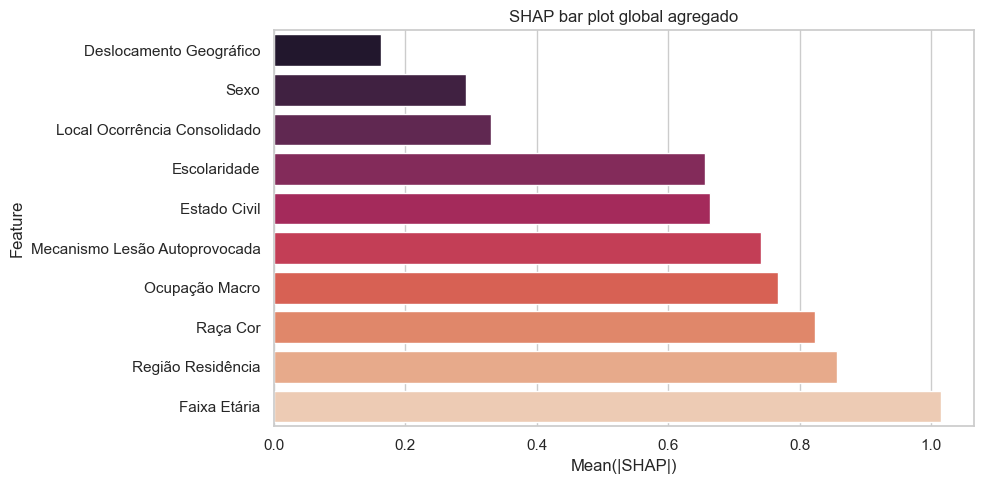

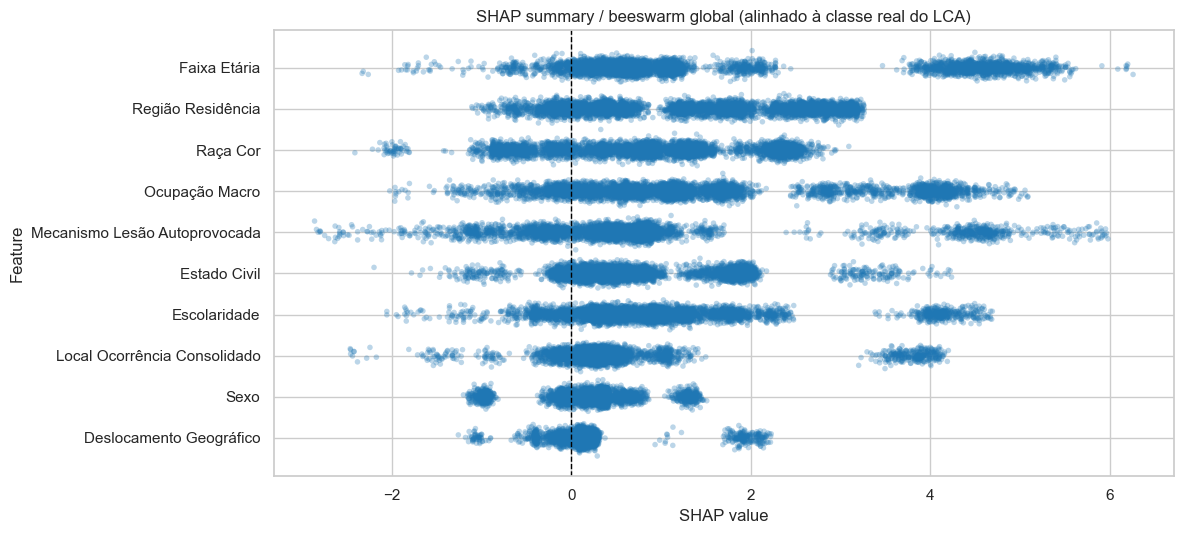

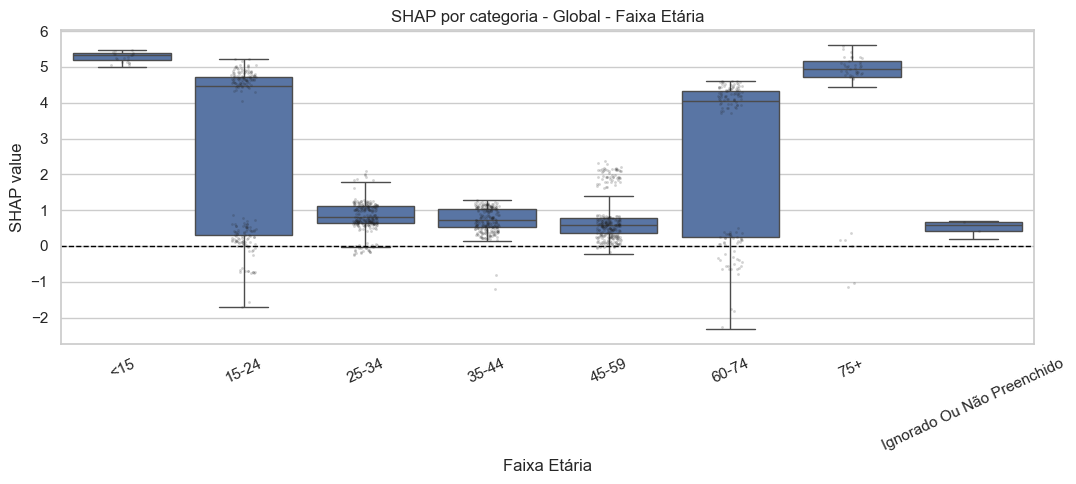

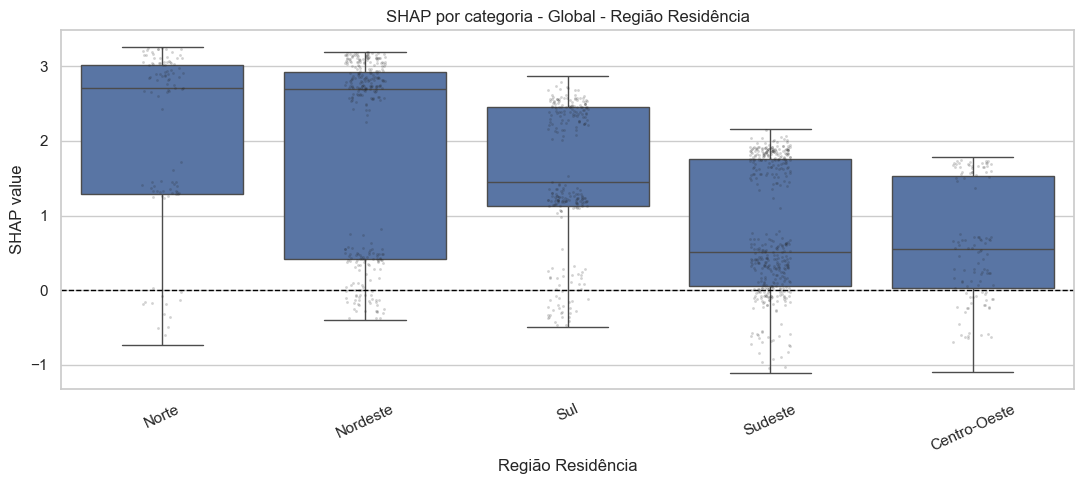

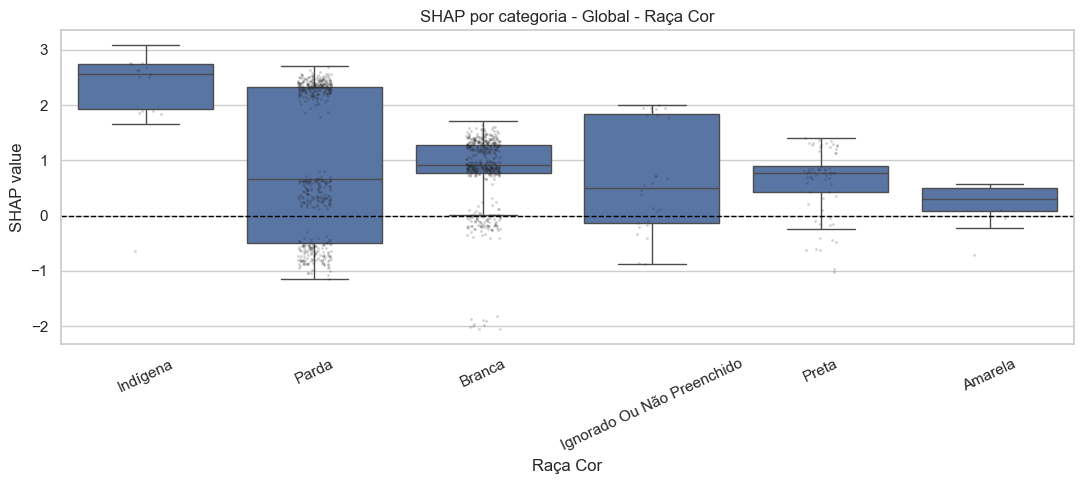

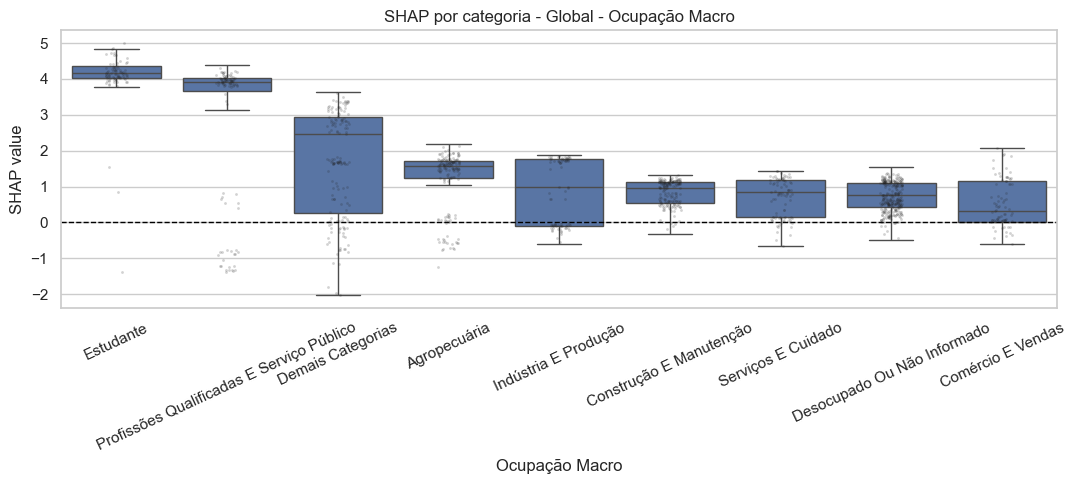

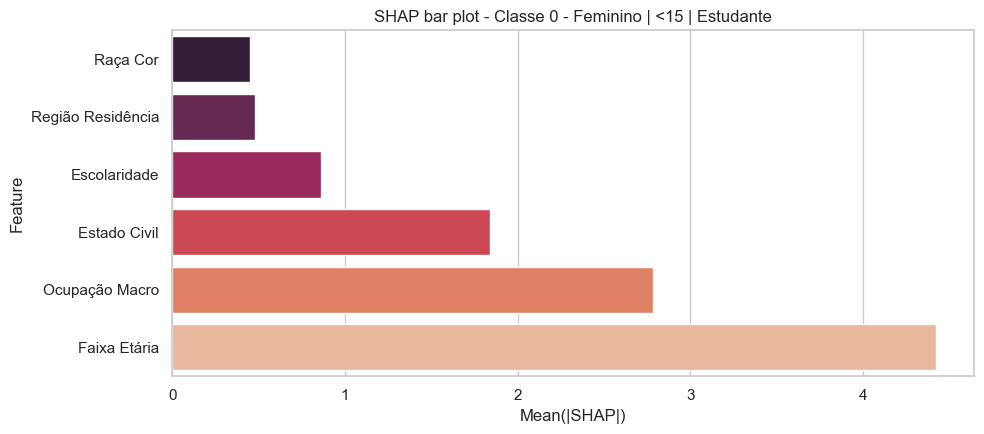

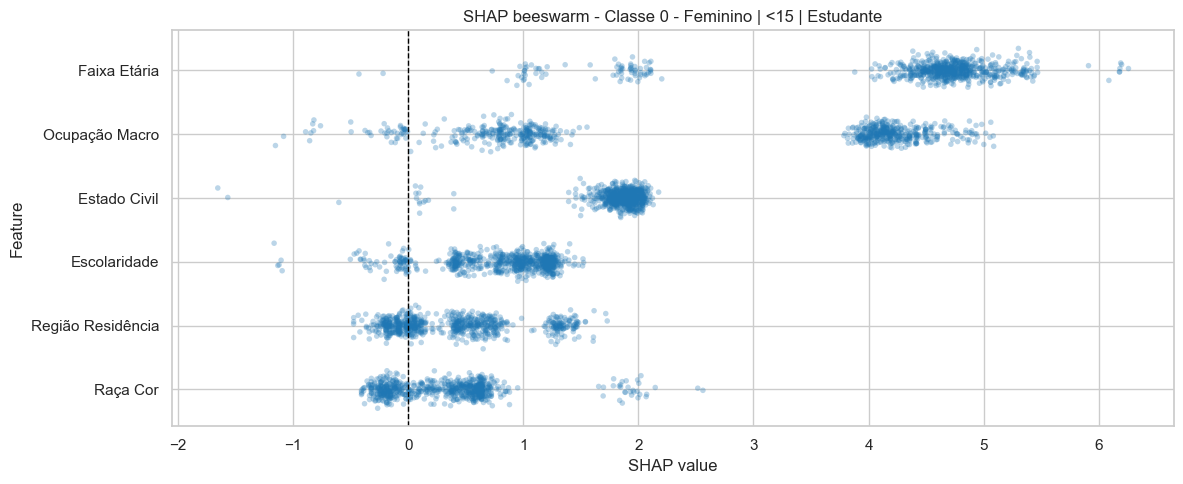

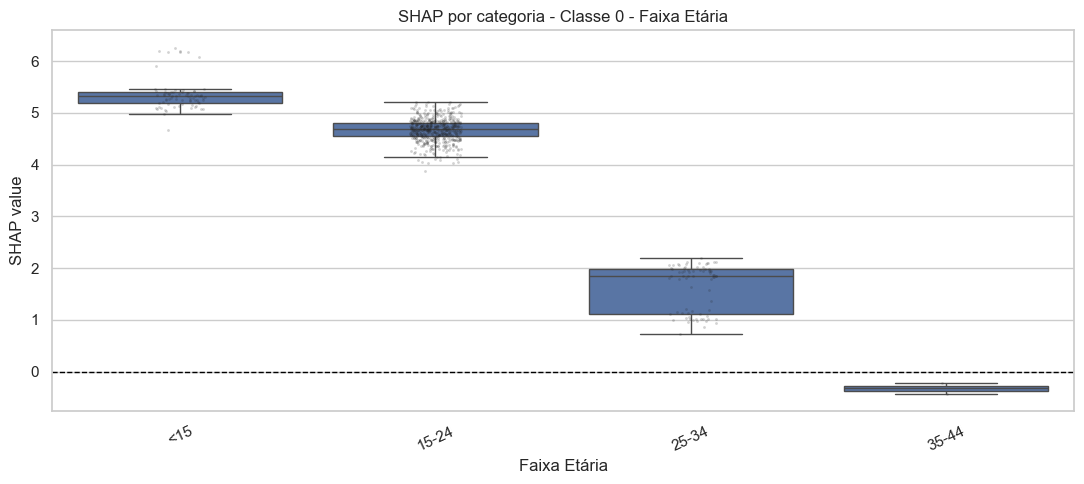

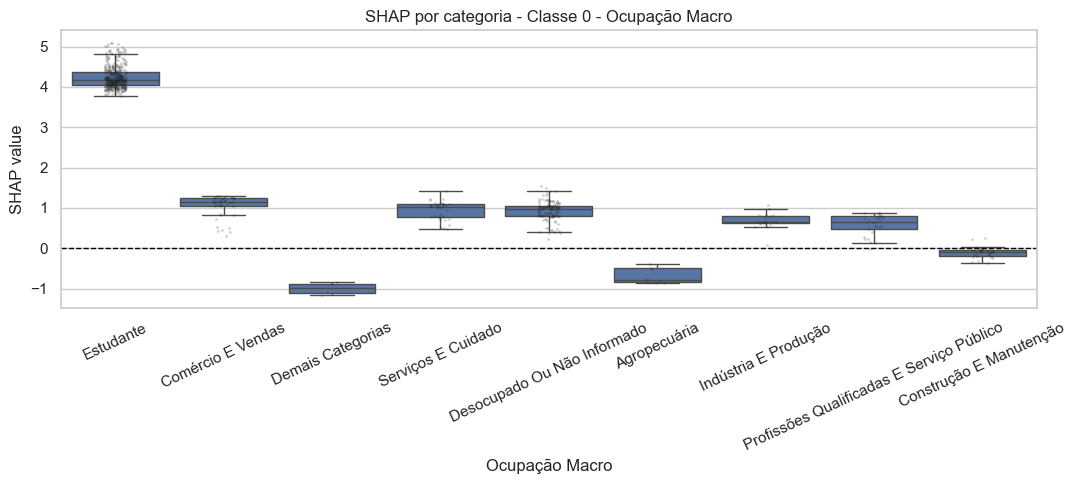

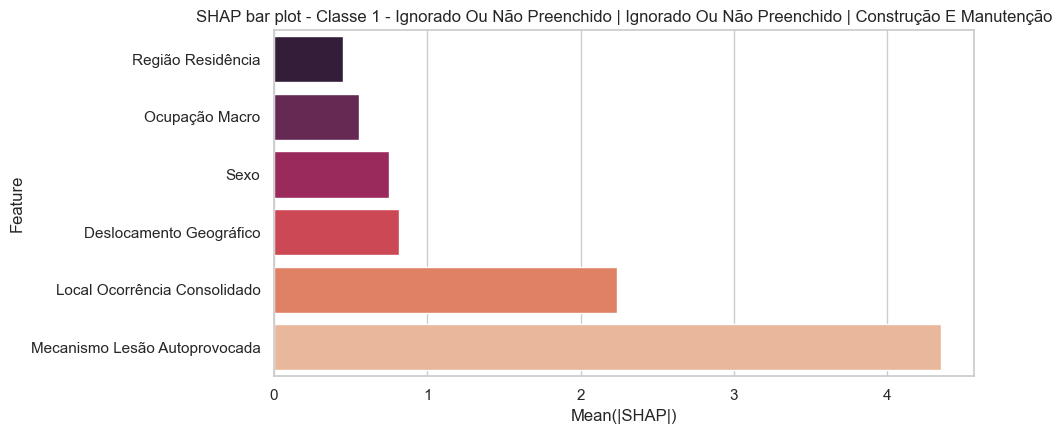

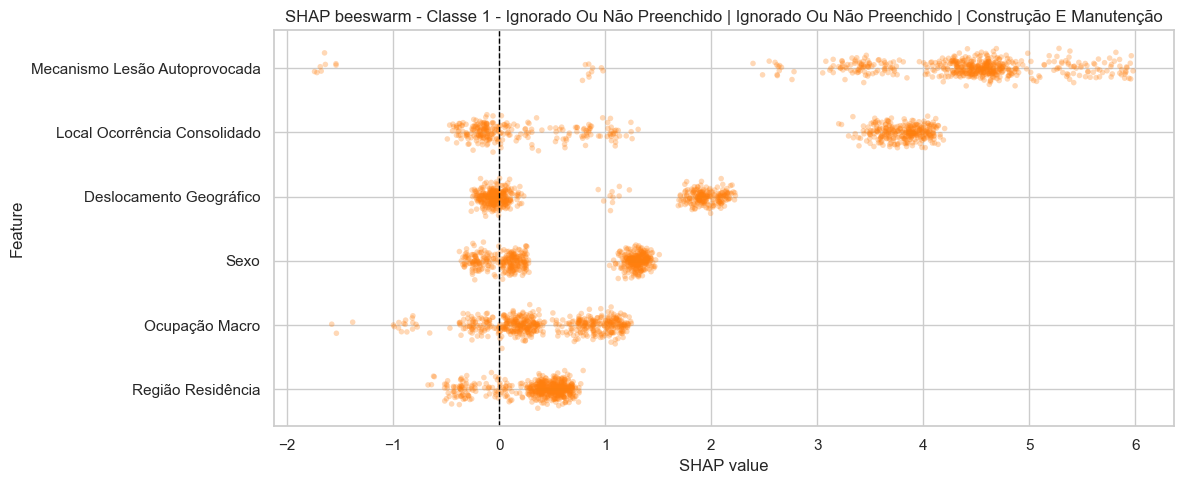

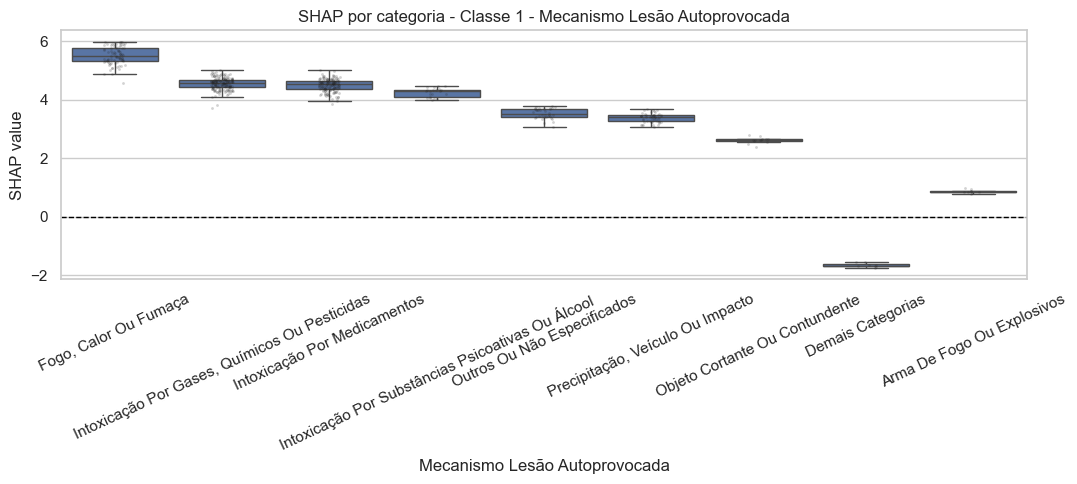

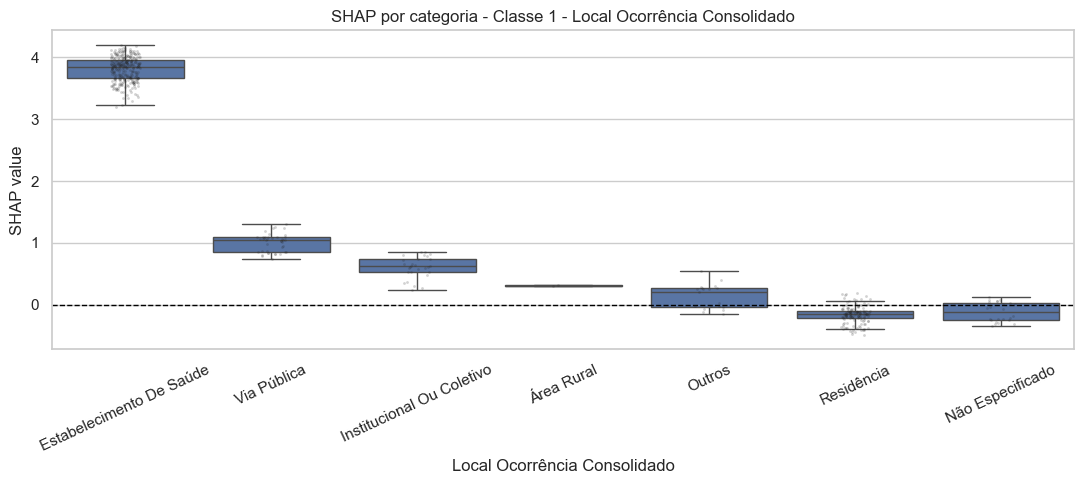

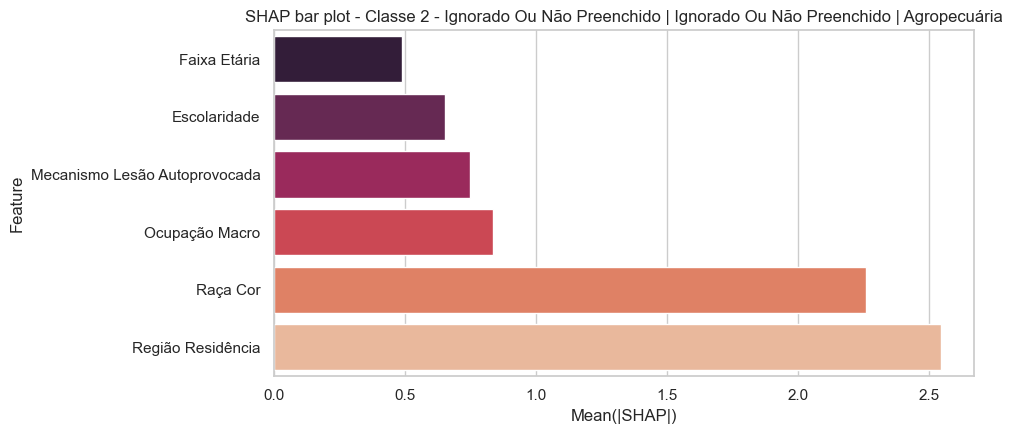

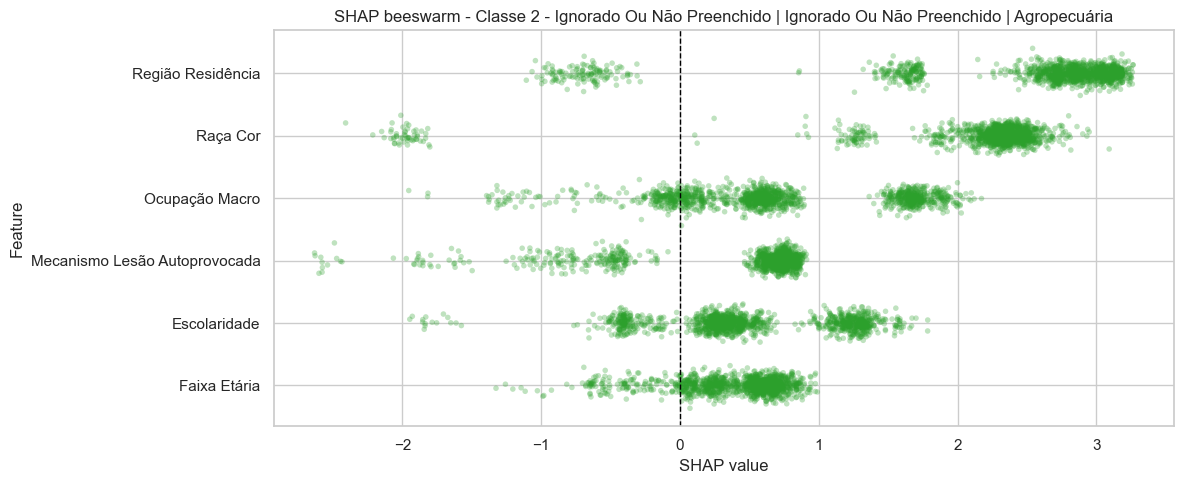

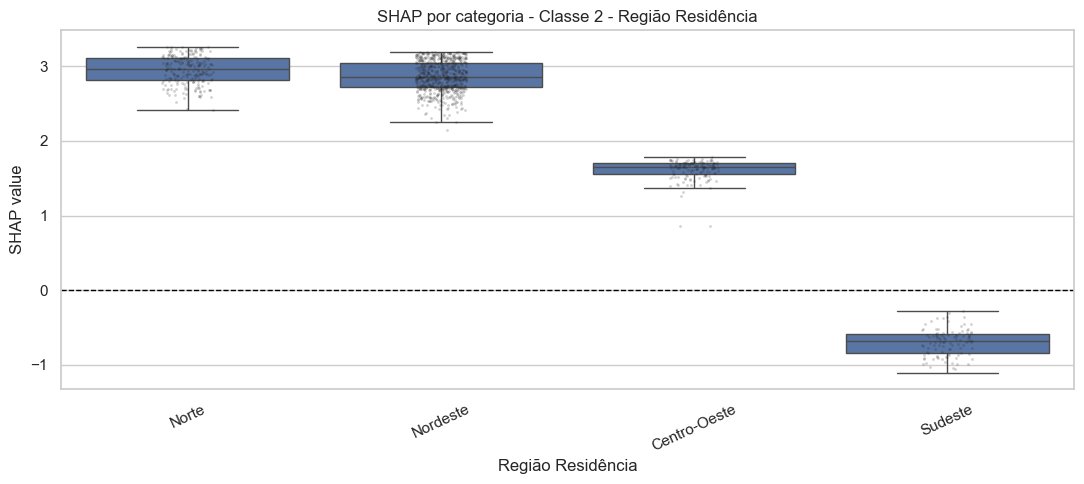

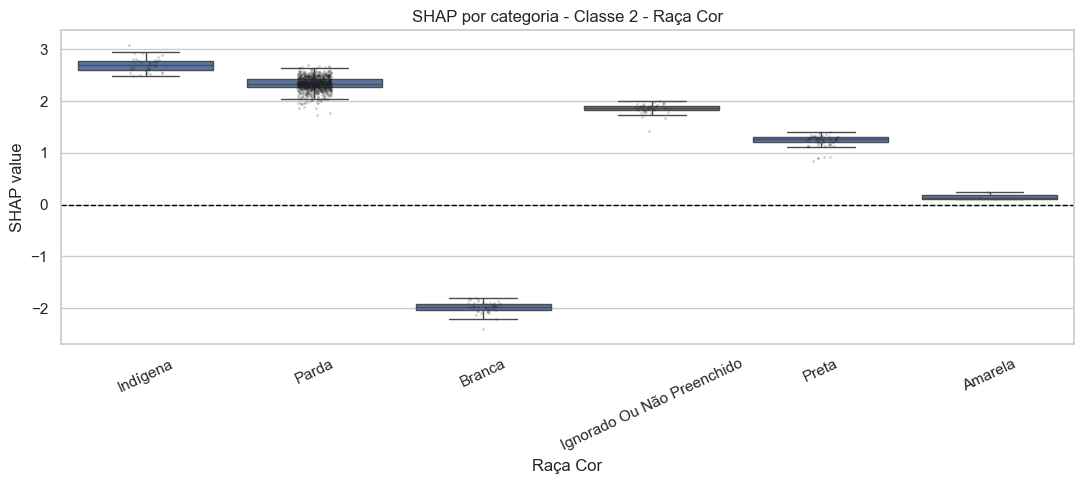

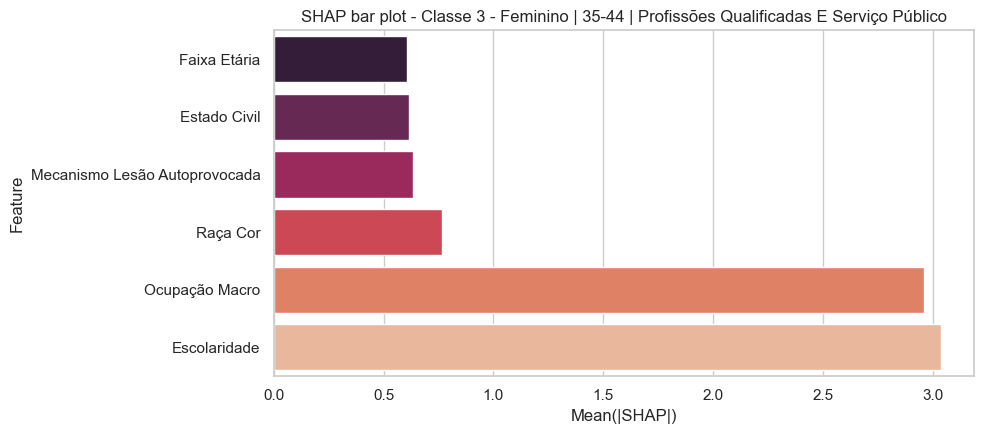

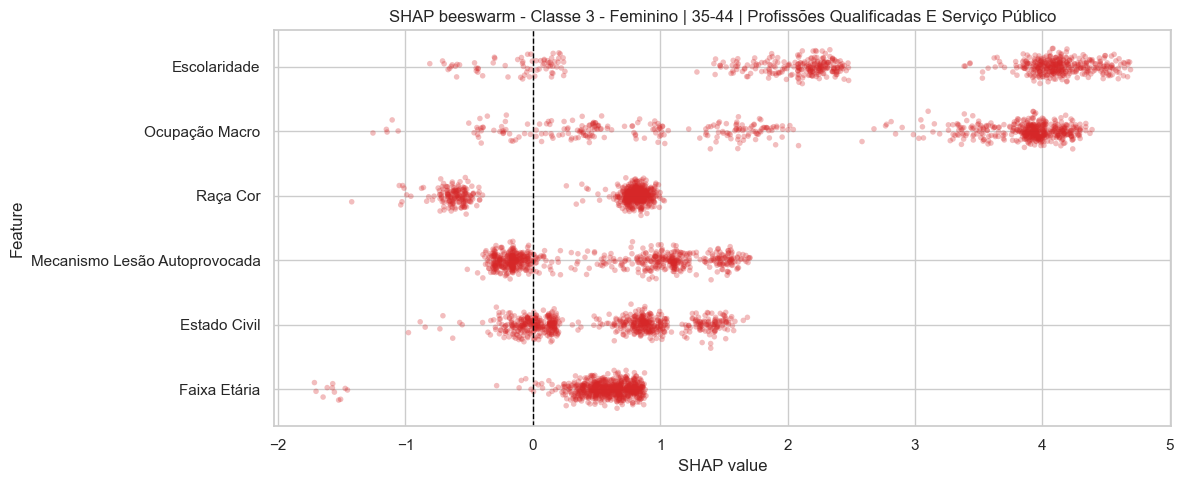

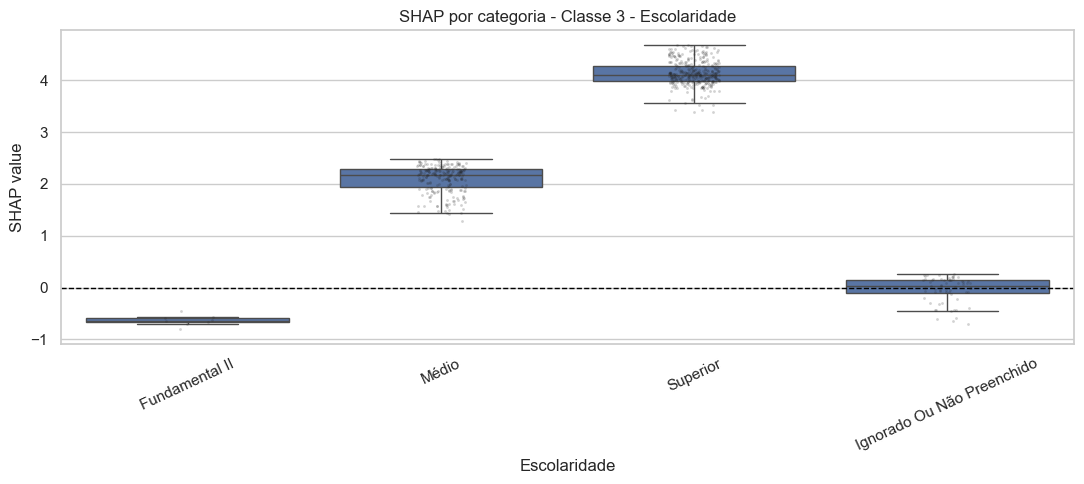

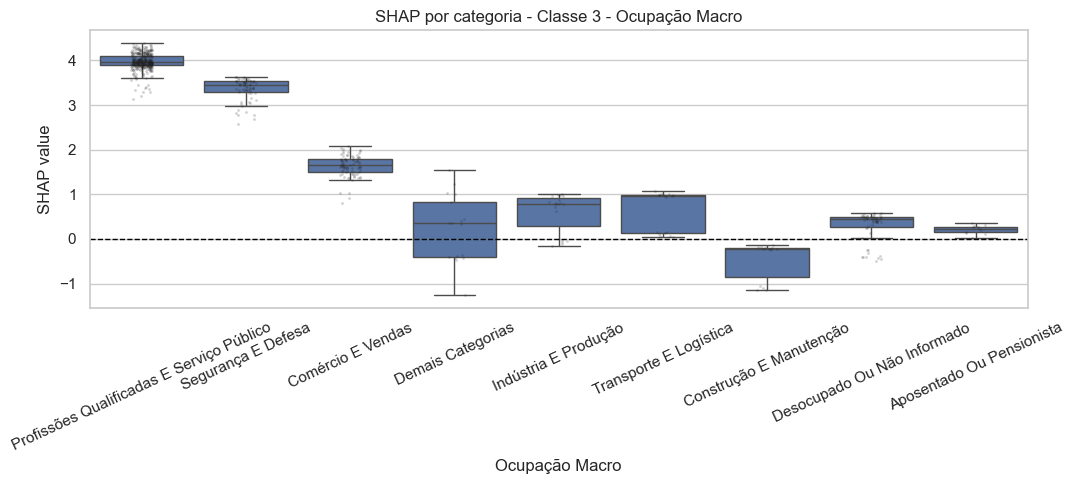

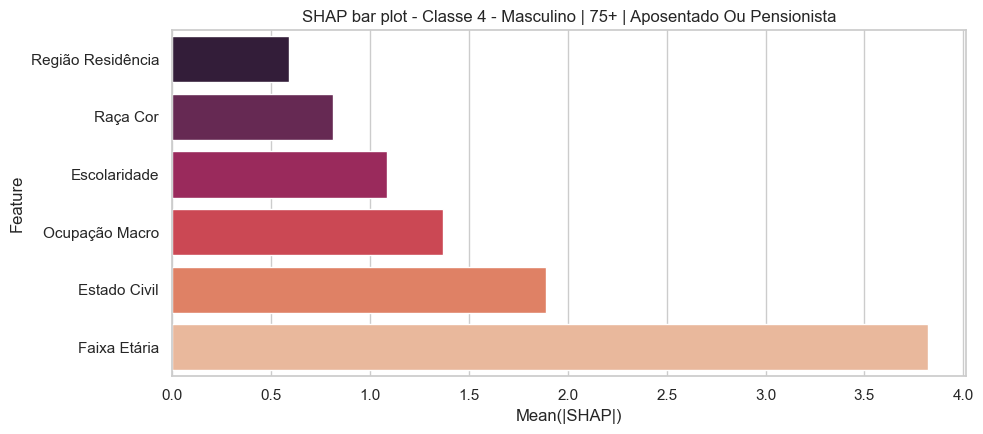

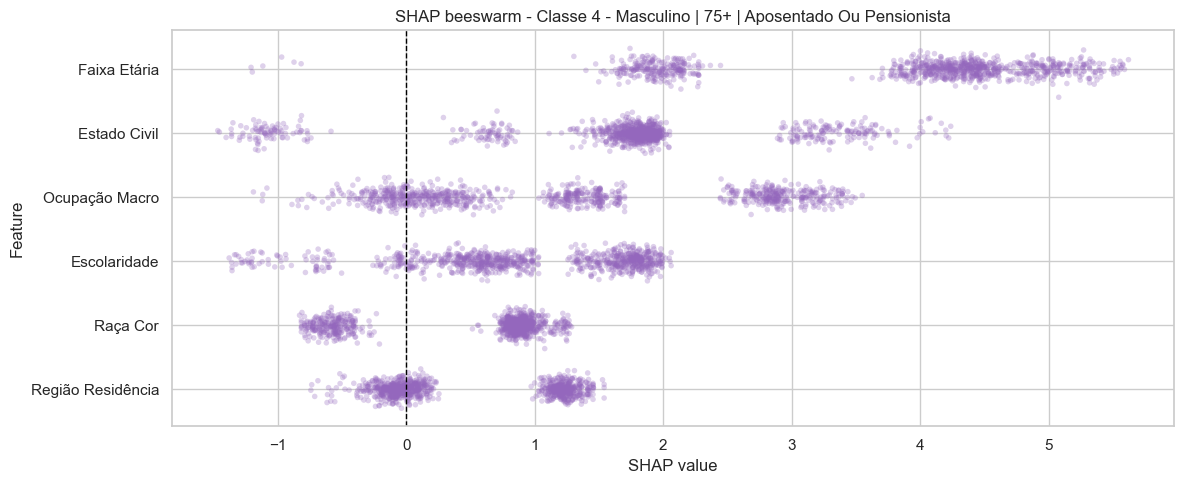

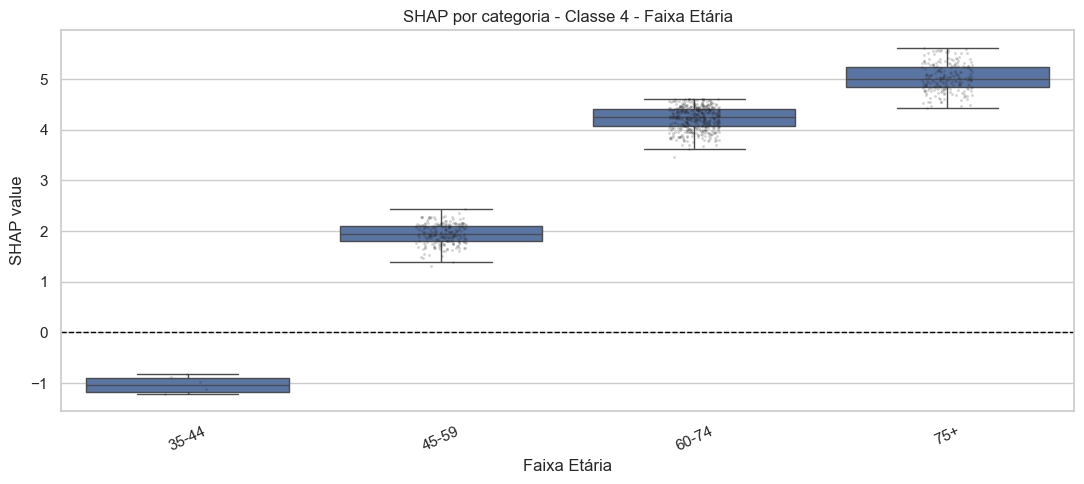

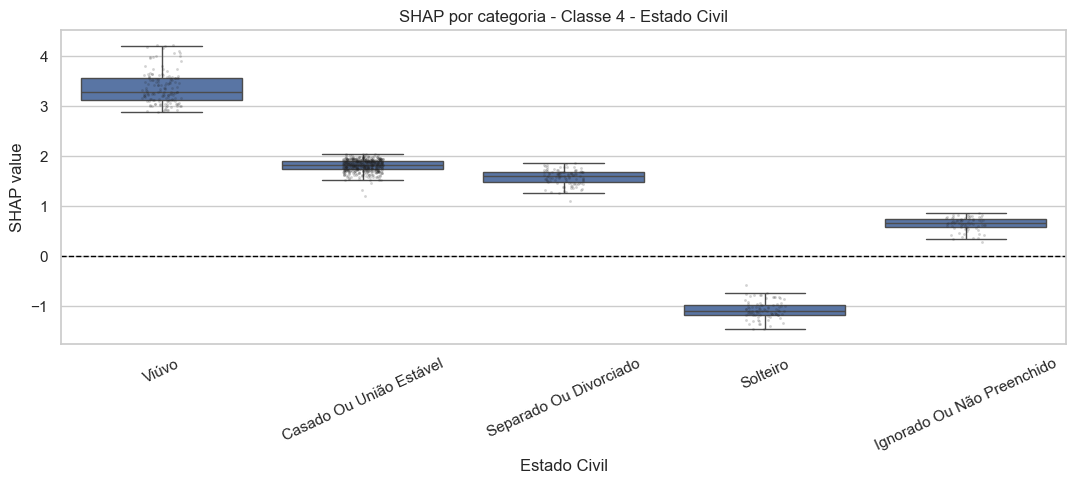

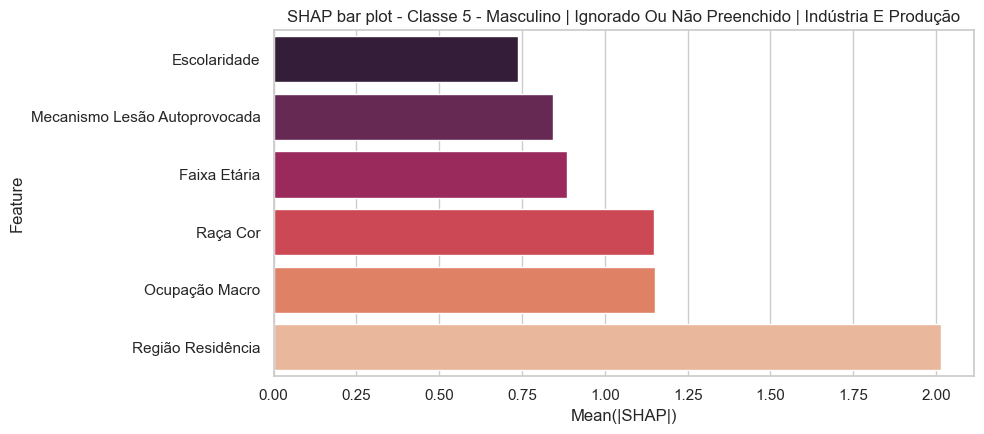

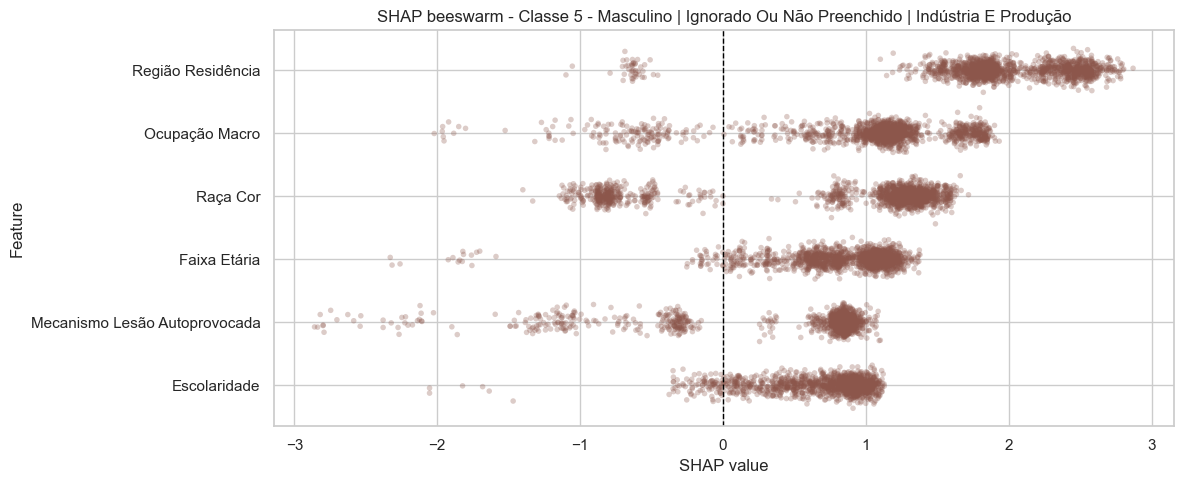

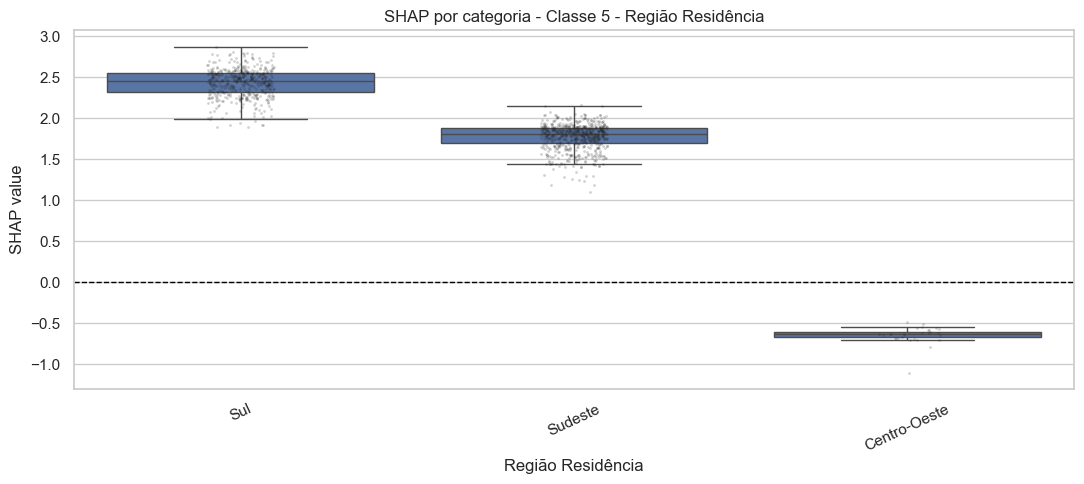

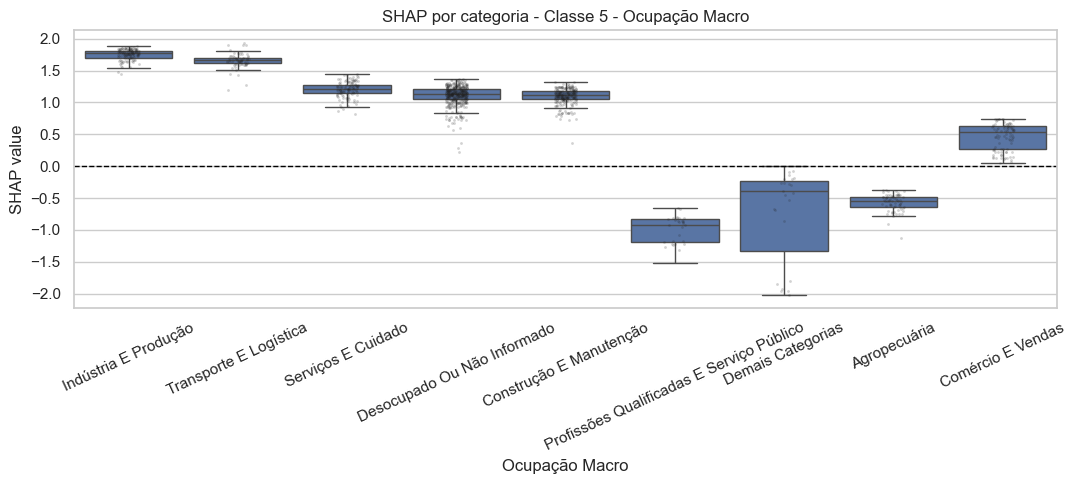

In [14]:
shap_sample_df = stratified_sample(analysis_test_df, stratify_col="classe_lca", max_rows=SHAP_SAMPLE_SIZE)
y_shap = shap_sample_df["classe_lca"].astype(int).to_numpy()

print("Fonte de SHAP: CatBoost nativo em lotes para evitar crash do kernel no Windows.")
X_shap, shap_values_list, expected_values_map = compute_native_shap_values(
    final_model,
    shap_sample_df.loc[:, FEATURE_COLUMNS],
    feature_columns=FEATURE_COLUMNS,
    class_labels=class_labels,
    batch_size=NATIVE_SHAP_BATCH_SIZE,
    progress_label="SHAP global",
)

global_shap_importance_df = build_global_shap_importance(shap_values_list)
per_class_shap_importance_df = build_per_class_shap_importance(shap_values_list, y_shap, class_labels)
true_aligned_shap_df = align_shap_to_target_classes(shap_values_list, y_shap, class_labels)
shap_long_true_df = build_shap_long_table(shap_sample_df, true_aligned_shap_df, alignment_label="classe_real_lca")

display(global_shap_importance_df)
display(per_class_shap_importance_df.head(30))

save_table(global_shap_importance_df, TABLE_DIR / "shap_importancia_global.csv")
save_table(per_class_shap_importance_df, TABLE_DIR / "shap_importancia_por_classe.csv")
save_table(shap_long_true_df, TABLE_DIR / "shap_valores_amostra_alinhados_classe_real.parquet")

plot_shap_bar(
    global_shap_importance_df,
    title="SHAP bar plot global agregado",
    filename="shap_bar_global.png",
    max_features=TOP_SHAP_FEATURES_GLOBAL,
)
plot_shap_beeswarm(
    true_aligned_shap_df,
    importance_df=global_shap_importance_df,
    title="SHAP summary / beeswarm global (alinhado à classe real do LCA)",
    filename="shap_beeswarm_global.png",
    max_features=TOP_SHAP_FEATURES_GLOBAL,
)

global_category_summaries = []
for feature in global_shap_importance_df["feature"].head(TOP_CATEGORY_PLOT_FEATURES_GLOBAL):
    summary = plot_shap_category_effect(
        feature_values_df=X_shap,
        shap_df=true_aligned_shap_df,
        feature=feature,
        title=f"SHAP por categoria - Global - {feature}",
        filename=f"shap_categoria_global_{normalize_text(feature)}.png",
    )
    summary["escopo"] = "global"
    summary["classe_lca"] = np.nan
    global_category_summaries.append(summary)

per_class_category_summaries = []
for cls in class_labels:
    cls_mask = shap_sample_df["classe_lca"].to_numpy() == cls
    if cls_mask.sum() == 0:
        continue
    cls_x_df = X_shap.loc[cls_mask].reset_index(drop=True)
    cls_shap_df = shap_values_list[class_to_position[int(cls)]].loc[cls_mask].reset_index(drop=True)
    cls_importance_df = per_class_shap_importance_df[
        per_class_shap_importance_df["classe_lca"] == cls
    ].reset_index(drop=True)

    plot_shap_bar(
        cls_importance_df,
        title=f"SHAP bar plot - Classe {cls} - {class_name_map[int(cls)]}",
        filename=f"shap_bar_classe_{cls}.png",
        max_features=TOP_SHAP_FEATURES_BY_CLASS,
    )
    plot_shap_beeswarm(
        cls_shap_df,
        importance_df=cls_importance_df,
        title=f"SHAP beeswarm - Classe {cls} - {class_name_map[int(cls)]}",
        filename=f"shap_beeswarm_classe_{cls}.png",
        max_features=TOP_SHAP_FEATURES_BY_CLASS,
        color=sns.color_palette("tab10", n_colors=len(class_labels))[class_to_position[int(cls)]],
    )

    for feature in cls_importance_df["feature"].head(TOP_CATEGORY_PLOT_FEATURES_BY_CLASS):
        summary = plot_shap_category_effect(
            feature_values_df=cls_x_df,
            shap_df=cls_shap_df,
            feature=feature,
            title=f"SHAP por categoria - Classe {cls} - {feature}",
            filename=f"shap_categoria_classe_{cls}_{normalize_text(feature)}.png",
        )
        summary["escopo"] = f"classe_{cls}"
        summary["classe_lca"] = int(cls)
        per_class_category_summaries.append(summary)

shap_category_global_df = pd.concat(global_category_summaries, ignore_index=True) if global_category_summaries else pd.DataFrame()
shap_category_per_class_df = pd.concat(per_class_category_summaries, ignore_index=True) if per_class_category_summaries else pd.DataFrame()
if not shap_category_global_df.empty:
    save_table(shap_category_global_df, TABLE_DIR / "shap_categoria_global.csv")
if not shap_category_per_class_df.empty:
    save_table(shap_category_per_class_df, TABLE_DIR / "shap_categoria_por_classe.csv")


In [15]:
def normalize_interaction_values_multiclass(
    raw_interactions: Any,
    feature_columns: list[str],
    class_labels: list[int],
) -> list[np.ndarray]:
    if isinstance(raw_interactions, list):
        arrays = [np.asarray(item, dtype=float) for item in raw_interactions]
    else:
        arr = np.asarray(raw_interactions, dtype=float)
        if arr.ndim == 4 and arr.shape[0] == len(class_labels):
            arrays = [arr[idx] for idx in range(arr.shape[0])]
        elif arr.ndim == 4 and arr.shape[-1] == len(class_labels):
            arrays = [arr[..., idx] for idx in range(arr.shape[-1])]
        else:
            raise ValueError(f"Formato inesperado para SHAP interaction values: {arr.shape}")

    expected = (len(feature_columns), len(feature_columns))
    cleaned = []
    for arr in arrays:
        if arr.ndim != 3 or arr.shape[1:] != expected:
            raise ValueError(f"Shape inesperado para interaction values: {arr.shape}")
        cleaned.append(arr)
    return cleaned


def build_interaction_outputs_from_shap(interaction_arrays: list[np.ndarray]) -> tuple[pd.DataFrame, pd.DataFrame]:
    stack = np.stack(interaction_arrays, axis=0)
    interaction_strength = np.mean(np.abs(stack), axis=(0, 1))
    np.fill_diagonal(interaction_strength, 0.0)

    rows = []
    for i in range(len(FEATURE_COLUMNS)):
        for j in range(i + 1, len(FEATURE_COLUMNS)):
            per_class_strength = np.mean(np.abs(stack[:, :, i, j]), axis=1)
            dominant_pos = int(np.argmax(per_class_strength))
            dominant_class = int(class_labels[dominant_pos])
            rows.append(
                {
                    "feature_1": FEATURE_COLUMNS[i],
                    "feature_2": FEATURE_COLUMNS[j],
                    "forca_interacao_media_abs": float(interaction_strength[i, j]),
                    "classe_dominante": dominant_class,
                    "rotulo_classe_dominante": class_profile_map[dominant_class],
                    "metodo_interacao": "shap_interaction_values",
                }
            )

    interaction_table_df = pd.DataFrame(rows).sort_values(
        "forca_interacao_media_abs",
        ascending=False,
    ).reset_index(drop=True)
    heatmap_df = pd.DataFrame(
        interaction_strength,
        index=FEATURE_COLUMNS,
        columns=FEATURE_COLUMNS,
    )
    return interaction_table_df, heatmap_df


def build_interaction_outputs_from_catboost(native_interactions: Any) -> tuple[pd.DataFrame, pd.DataFrame]:
    native = np.asarray(native_interactions)
    if native.ndim != 2 or native.shape[1] < 3:
        raise ValueError("CatBoost não retornou interações em formato utilizável.")

    matrix = np.zeros((len(FEATURE_COLUMNS), len(FEATURE_COLUMNS)), dtype=float)
    rows = []
    for feat_1, feat_2, score, *rest in native.tolist():
        feat_1 = int(feat_1)
        feat_2 = int(feat_2)
        if feat_1 == feat_2 or feat_1 >= len(FEATURE_COLUMNS) or feat_2 >= len(FEATURE_COLUMNS):
            continue
        matrix[feat_1, feat_2] = float(score)
        matrix[feat_2, feat_1] = float(score)
        rows.append(
            {
                "feature_1": FEATURE_COLUMNS[feat_1],
                "feature_2": FEATURE_COLUMNS[feat_2],
                "forca_interacao_media_abs": float(score),
                "classe_dominante": np.nan,
                "rotulo_classe_dominante": "não disponível",
                "metodo_interacao": "catboost_native",
            }
        )

    interaction_table_df = pd.DataFrame(rows).sort_values(
        "forca_interacao_media_abs",
        ascending=False,
    ).reset_index(drop=True)
    heatmap_df = pd.DataFrame(matrix, index=FEATURE_COLUMNS, columns=FEATURE_COLUMNS)
    return interaction_table_df, heatmap_df


def plot_interaction_heatmap(heatmap_df: pd.DataFrame, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(heatmap_df, cmap="magma", annot=False, ax=ax)
    ax.set_title(title)
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


def plot_dependence_for_interaction(
    feature_values_df: pd.DataFrame,
    shap_values_list: list[pd.DataFrame],
    interaction_row: pd.Series,
    filename: str,
) -> None:
    feature_1 = interaction_row["feature_1"]
    feature_2 = interaction_row["feature_2"]
    if pd.notna(interaction_row["classe_dominante"]):
        classe_foco = int(interaction_row["classe_dominante"])
    else:
        feature_focus_df = per_class_shap_importance_df[per_class_shap_importance_df["feature"] == feature_1]
        classe_foco = int(feature_focus_df.sort_values("mean_abs_shap", ascending=False).iloc[0]["classe_lca"])

    class_pos = class_to_position[classe_foco]
    plot_df = pd.DataFrame(
        {
            feature_1: feature_values_df[feature_1].astype("string").fillna(MISSING_TOKEN),
            feature_2: feature_values_df[feature_2].astype("string").fillna(MISSING_TOKEN),
            "shap_feature_1": shap_values_list[class_pos][feature_1].to_numpy(dtype=float),
        }
    )

    plot_df[f"{feature_2}_plot"] = limit_categories(plot_df[feature_2], top_n=min(4, TOP_CATEGORIES_PER_PLOT))
    if feature_1 in ORDERED_CATEGORIES:
        order = [cat for cat in ORDERED_CATEGORIES[feature_1] if cat in plot_df[feature_1].unique().tolist()]
        x_col = feature_1
    else:
        plot_df[f"{feature_1}_plot"] = limit_categories(plot_df[feature_1], top_n=TOP_CATEGORIES_PER_PLOT)
        order = plot_df[f"{feature_1}_plot"].value_counts(dropna=False).index.tolist()
        x_col = f"{feature_1}_plot"

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=plot_df,
        x=x_col,
        y="shap_feature_1",
        hue=f"{feature_2}_plot",
        order=order,
        showfliers=False,
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(
        f"Dependence plot - {feature_1} x {feature_2} | classe foco: {class_profile_map[classe_foco]}"
    )
    ax.set_xlabel(feature_1)
    ax.set_ylabel(f"SHAP de {feature_1}")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title=feature_2, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


SHAP para interações: lote 1/2 (1000 linhas; acumulado 1000/1500)
SHAP para interações: lote 2/2 (500 linhas; acumulado 1500/1500)


,feature_1,feature_2,forca_interacao_media_abs,classe_dominante,rotulo_classe_dominante,metodo_interacao
0,Faixa Etária,Escolaridade,10.306776,NaN,não disponível,catboost_native
1,Faixa Etária,Ocupação Macro,8.195045,NaN,não disponível,catboost_native
2,Faixa Etária,Local Ocorrência Consolidado,5.978701,NaN,não disponível,catboost_native
3,Escolaridade,Local Ocorrência Consolidado,5.289641,NaN,não disponível,catboost_native
4,Faixa Etária,Região Residência,5.263168,NaN,não disponível,catboost_native
5,Ocupação Macro,Mecanismo Lesão Autoprovocada,4.184575,NaN,não disponível,catboost_native
6,Ocupação Macro,Região Residência,3.804714,NaN,não disponível,catboost_native
7,Escolaridade,Ocupação Macro,3.524389,NaN,não disponível,catboost_native
8,Escolaridade,Região Residência,3.442304,NaN,não disponível,catboost_native
9,Faixa Etária,Mecanismo Lesão Autoprovocada,3.327252,NaN,não disponível,catboost_native


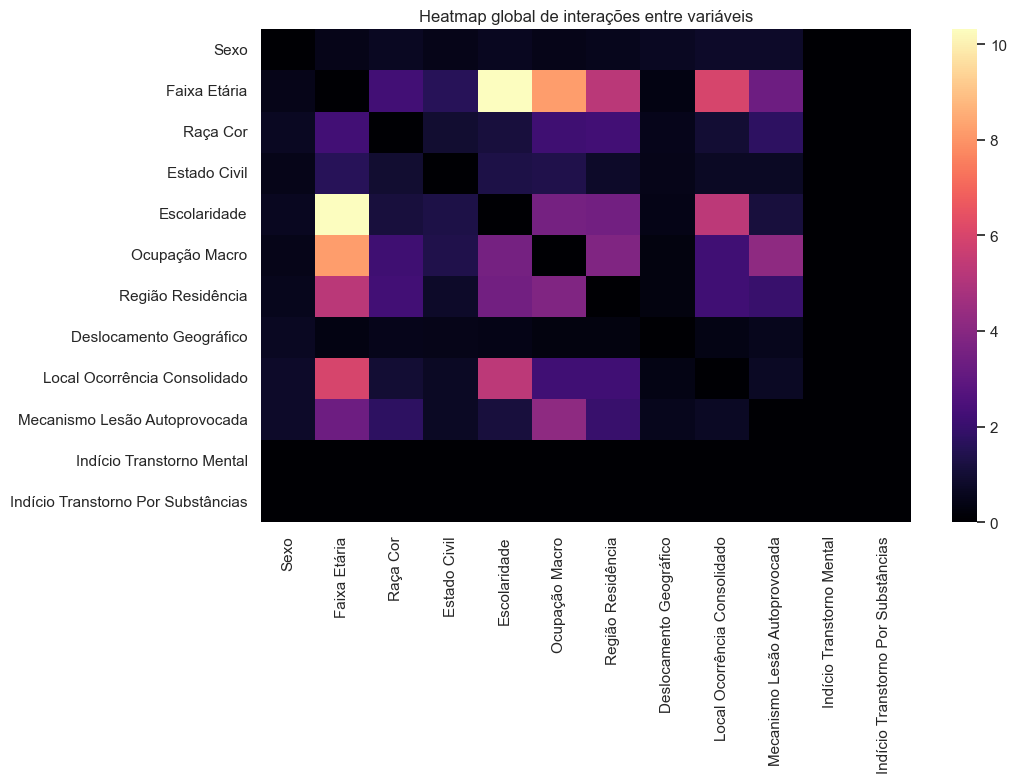

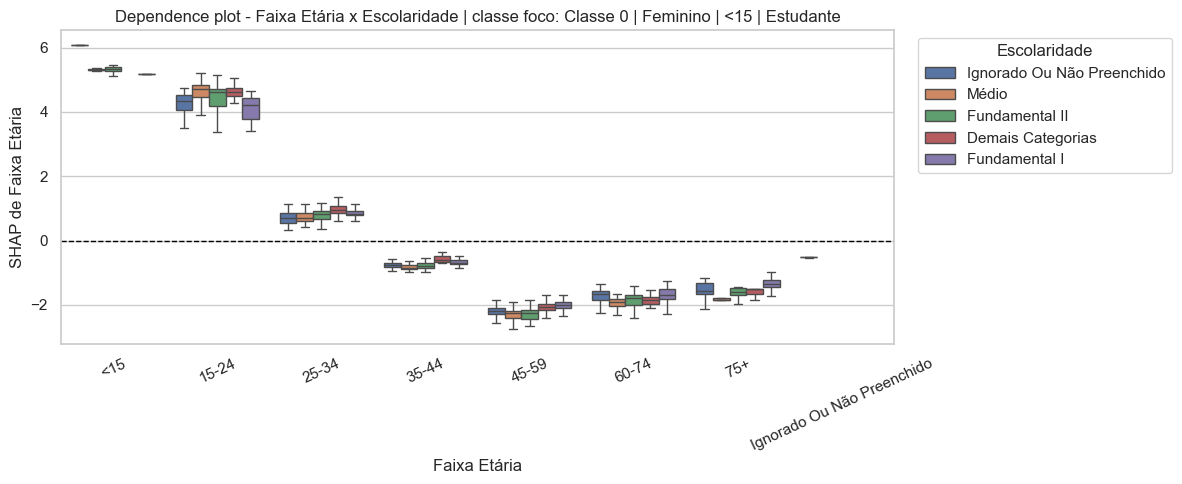

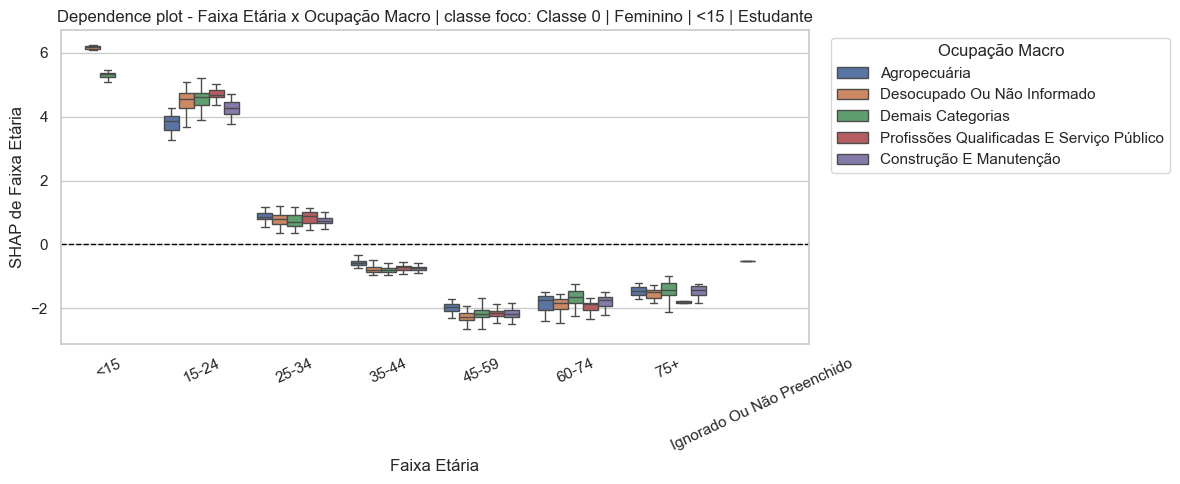

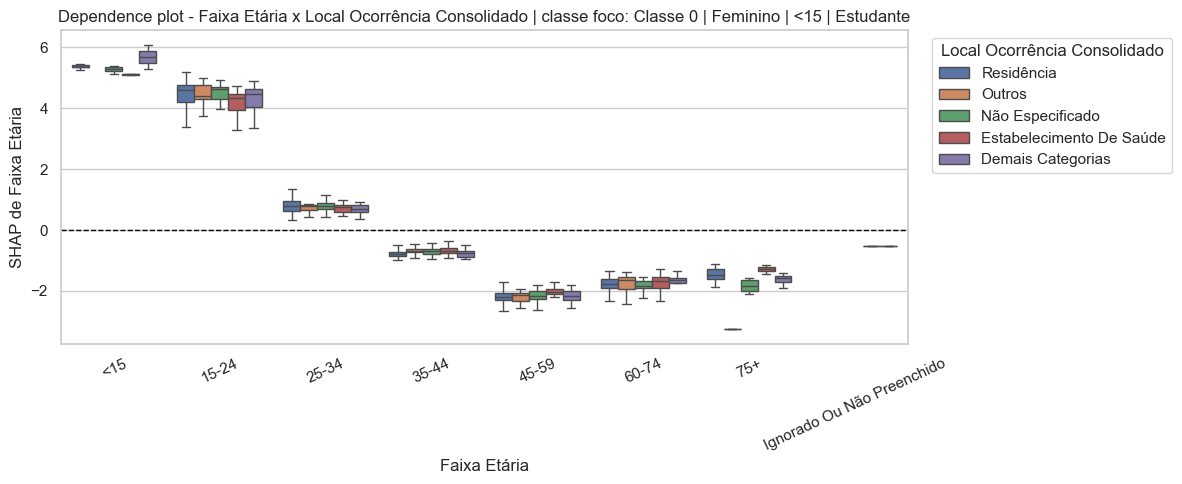

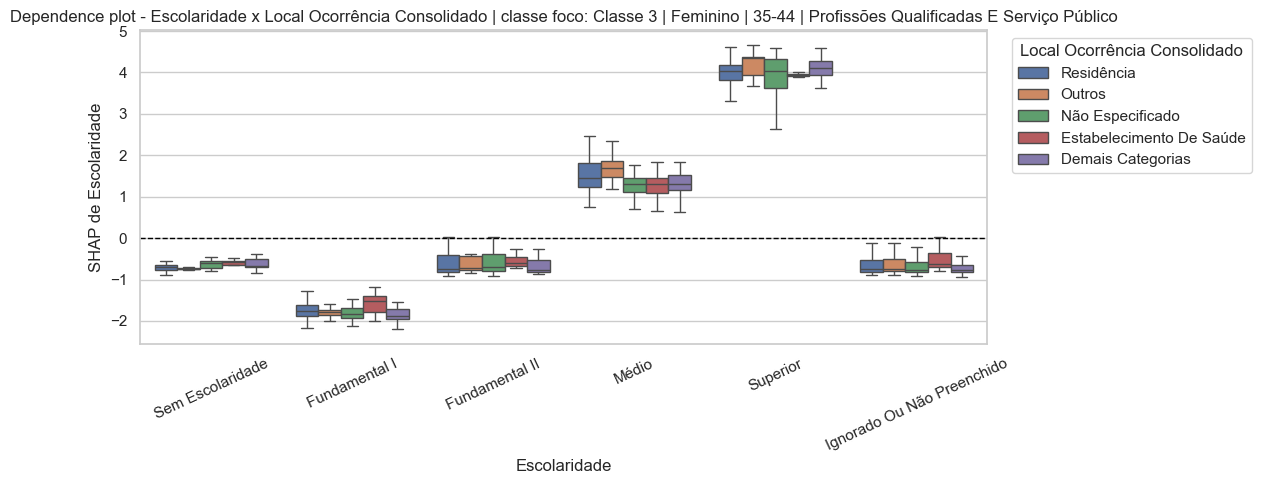

In [16]:
interaction_sample_df = stratified_sample(analysis_test_df, stratify_col="classe_lca", max_rows=INTERACTION_SAMPLE_SIZE)
X_interaction, interaction_shap_values_list, _ = compute_native_shap_values(
    final_model,
    interaction_sample_df.loc[:, FEATURE_COLUMNS],
    feature_columns=FEATURE_COLUMNS,
    class_labels=class_labels,
    batch_size=min(NATIVE_SHAP_BATCH_SIZE, INTERACTION_SAMPLE_SIZE),
    progress_label="SHAP para interações",
)

interaction_method_note = "catboost_native"
native_interactions = final_model.get_feature_importance(
    Pool(X_interaction, cat_features=FEATURE_COLUMNS),
    type="Interaction",
)
interaction_table_df, interaction_heatmap_df = build_interaction_outputs_from_catboost(native_interactions)
interaction_table_df["metodo_interacao"] = interaction_method_note

display(interaction_table_df.head(TOP_INTERACTIONS_TO_REPORT))
save_table(interaction_table_df, TABLE_DIR / "top_interacoes_globais.csv")
save_table(interaction_heatmap_df.reset_index().rename(columns={"index": "feature"}), TABLE_DIR / "heatmap_interacoes_globais.csv")

plot_interaction_heatmap(
    interaction_heatmap_df,
    title="Heatmap global de interações entre variáveis",
    filename="heatmap_interacoes_globais.png",
)

for idx, row in interaction_table_df.head(TOP_INTERACTIONS_TO_PLOT).iterrows():
    plot_dependence_for_interaction(
        feature_values_df=X_interaction,
        shap_values_list=interaction_shap_values_list,
        interaction_row=row,
        filename=f"dependence_interacao_{idx + 1}_{normalize_text(row['feature_1'])}_{normalize_text(row['feature_2'])}.png",
    )


In [17]:
def compute_ordered_categorical_ale(
    model: CatBoostClassifier,
    reference_df: pd.DataFrame,
    feature: str,
    ordered_categories: list[str],
    class_labels: list[int],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = sanitize_feature_frame(reference_df, FEATURE_COLUMNS)
    X = X[X[feature].isin(ordered_categories)].reset_index(drop=True)
    if X.empty:
        raise ValueError(f"Não há registros suficientes para calcular ALE de {feature}.")

    counts_by_category = X[feature].value_counts(dropna=False).reindex(ordered_categories, fill_value=0)

    delta_rows = []
    deltas = []
    for left_category, right_category in zip(ordered_categories[:-1], ordered_categories[1:]):
        mask = X[feature].isin([left_category, right_category])
        pair_count = int(mask.sum())
        if pair_count == 0:
            delta = np.zeros(len(class_labels), dtype=float)
        else:
            X_left = X.loc[mask].copy()
            X_right = X.loc[mask].copy()
            X_left[feature] = left_category
            X_right[feature] = right_category
            prob_left = model.predict_proba(X_left)
            prob_right = model.predict_proba(X_right)
            delta = (prob_right - prob_left).mean(axis=0)

        deltas.append(delta)
        for class_pos, cls in enumerate(class_labels):
            delta_rows.append(
                {
                    "feature": feature,
                    "classe_lca": int(cls),
                    "categoria_esquerda": left_category,
                    "categoria_direita": right_category,
                    "delta_medio": float(delta[class_pos]),
                    "n_pares": pair_count,
                }
            )

    deltas_arr = np.vstack(deltas)
    ale = np.zeros((len(ordered_categories), len(class_labels)), dtype=float)
    for idx in range(1, len(ordered_categories)):
        ale[idx] = ale[idx - 1] + deltas_arr[idx - 1]

    weights = counts_by_category.to_numpy(dtype=float)
    if weights.sum() == 0:
        weights = np.ones_like(weights)
    centered_ale = ale - np.average(ale, axis=0, weights=weights)

    ale_rows = []
    for category_idx, category in enumerate(ordered_categories):
        for class_pos, cls in enumerate(class_labels):
            ale_rows.append(
                {
                    "feature": feature,
                    "categoria": category,
                    "ordem_categoria": category_idx,
                    "classe_lca": int(cls),
                    "rotulo_perfil": class_profile_map[int(cls)],
                    "ale": float(centered_ale[category_idx, class_pos]),
                    "n_categoria": int(counts_by_category.loc[category]),
                }
            )

    return pd.DataFrame(ale_rows), pd.DataFrame(delta_rows)


def plot_ale_multiclasse(ale_df: pd.DataFrame, feature: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(
        data=ale_df.sort_values(["classe_lca", "ordem_categoria"]),
        x="categoria",
        y="ale",
        hue="rotulo_perfil",
        marker="o",
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ALE multiclasse para {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("ALE na probabilidade predita")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Perfil", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)


,feature,categoria,ordem_categoria,classe_lca,rotulo_perfil,ale,n_categoria
0,Faixa Etária,<15,0,0,Classe 0 | Feminino | <15 | Estudante,0.499817,264
1,Faixa Etária,<15,0,1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,-0.036486,264
2,Faixa Etária,<15,0,2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,-0.163558,264
3,Faixa Etária,<15,0,3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,-0.060203,264
4,Faixa Etária,<15,0,4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,-0.091409,264
5,Faixa Etária,<15,0,5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,-0.148161,264
6,Faixa Etária,15-24,1,0,Classe 0 | Feminino | <15 | Estudante,0.236659,3317
7,Faixa Etária,15-24,1,1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,-0.020110,3317
8,Faixa Etária,15-24,1,2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,-0.045748,3317
9,Faixa Etária,15-24,1,3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,-0.056711,3317


,feature,categoria,ordem_categoria,classe_lca,rotulo_perfil,ale,n_categoria
0,Escolaridade,Sem Escolaridade,0,0,Classe 0 | Feminino | <15 | Estudante,-0.034502,769
1,Escolaridade,Sem Escolaridade,0,1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,0.012143,769
2,Escolaridade,Sem Escolaridade,0,2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.100609,769
3,Escolaridade,Sem Escolaridade,0,3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,-0.061662,769
4,Escolaridade,Sem Escolaridade,0,4,Classe 4 | Masculino | 75+ | Aposentado Ou Pensionista,0.070230,769
5,Escolaridade,Sem Escolaridade,0,5,Classe 5 | Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,-0.086818,769
6,Escolaridade,Fundamental I,1,0,Classe 0 | Feminino | <15 | Estudante,-0.036380,3382
7,Escolaridade,Fundamental I,1,1,Classe 1 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,0.011594,3382
8,Escolaridade,Fundamental I,1,2,Classe 2 | Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,0.070713,3382
9,Escolaridade,Fundamental I,1,3,Classe 3 | Feminino | 35-44 | Profissões Qualificadas E Serviço Público,-0.064162,3382


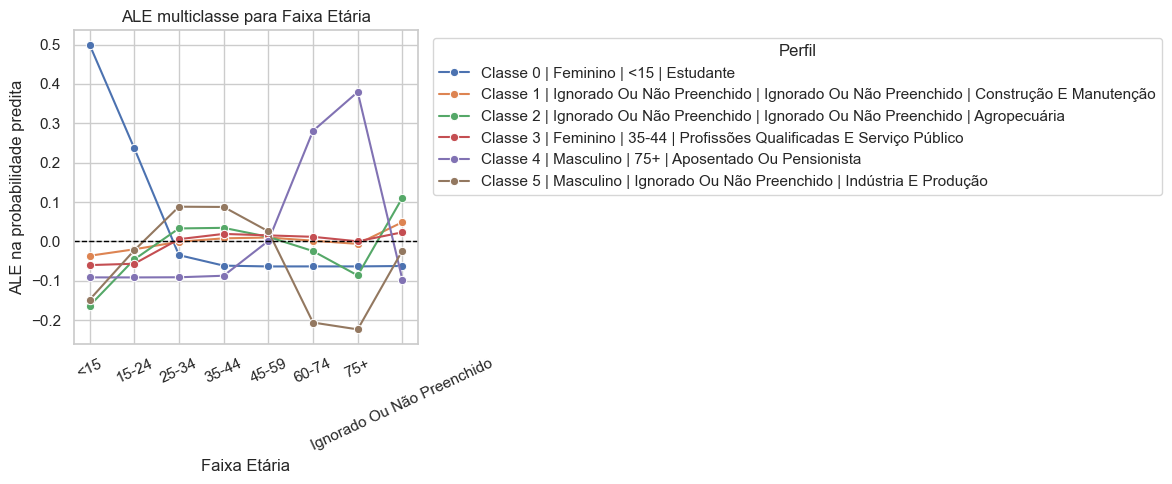

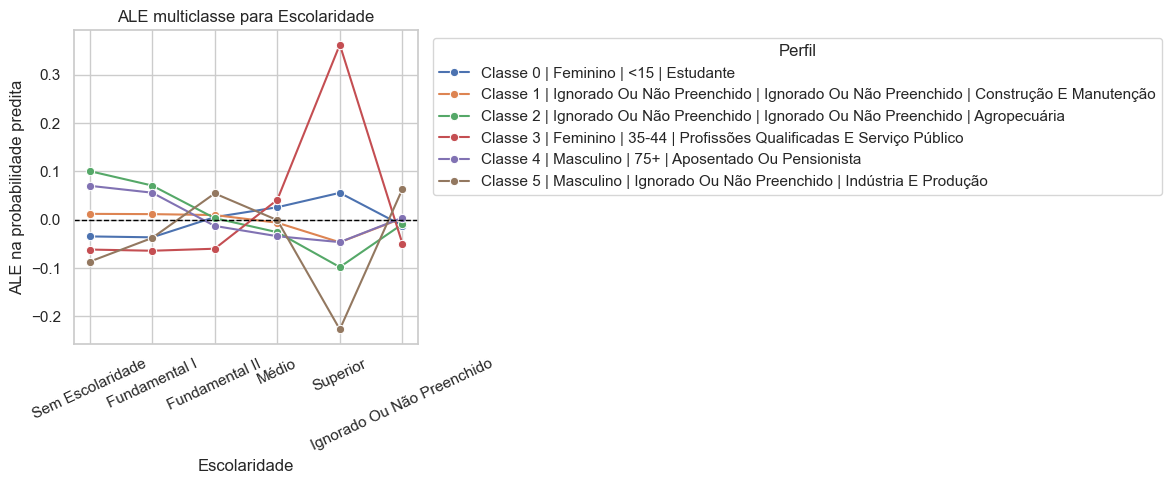

In [18]:
ale_reference_df = stratified_sample(analysis_test_df, stratify_col="classe_lca", max_rows=ALE_SAMPLE_SIZE)

ale_faixa_df, ale_faixa_deltas_df = compute_ordered_categorical_ale(
    final_model,
    ale_reference_df,
    feature="Faixa Etária",
    ordered_categories=ORDERED_CATEGORIES["Faixa Etária"],
    class_labels=class_labels,
)
ale_escolaridade_df, ale_escolaridade_deltas_df = compute_ordered_categorical_ale(
    final_model,
    ale_reference_df,
    feature="Escolaridade",
    ordered_categories=ORDERED_CATEGORIES["Escolaridade"],
    class_labels=class_labels,
)

display(ale_faixa_df.head(20))
display(ale_escolaridade_df.head(20))

save_table(ale_faixa_df, TABLE_DIR / "ale_faixa_etaria.csv")
save_table(ale_faixa_deltas_df, TABLE_DIR / "ale_faixa_etaria_deltas.csv")
save_table(ale_escolaridade_df, TABLE_DIR / "ale_escolaridade.csv")
save_table(ale_escolaridade_deltas_df, TABLE_DIR / "ale_escolaridade_deltas.csv")

plot_ale_multiclasse(ale_faixa_df, feature="Faixa Etária", filename="ale_faixa_etaria.png")
plot_ale_multiclasse(ale_escolaridade_df, feature="Escolaridade", filename="ale_escolaridade.png")


SHAP local: lote 1/1 (18 linhas; acumulado 18/18)


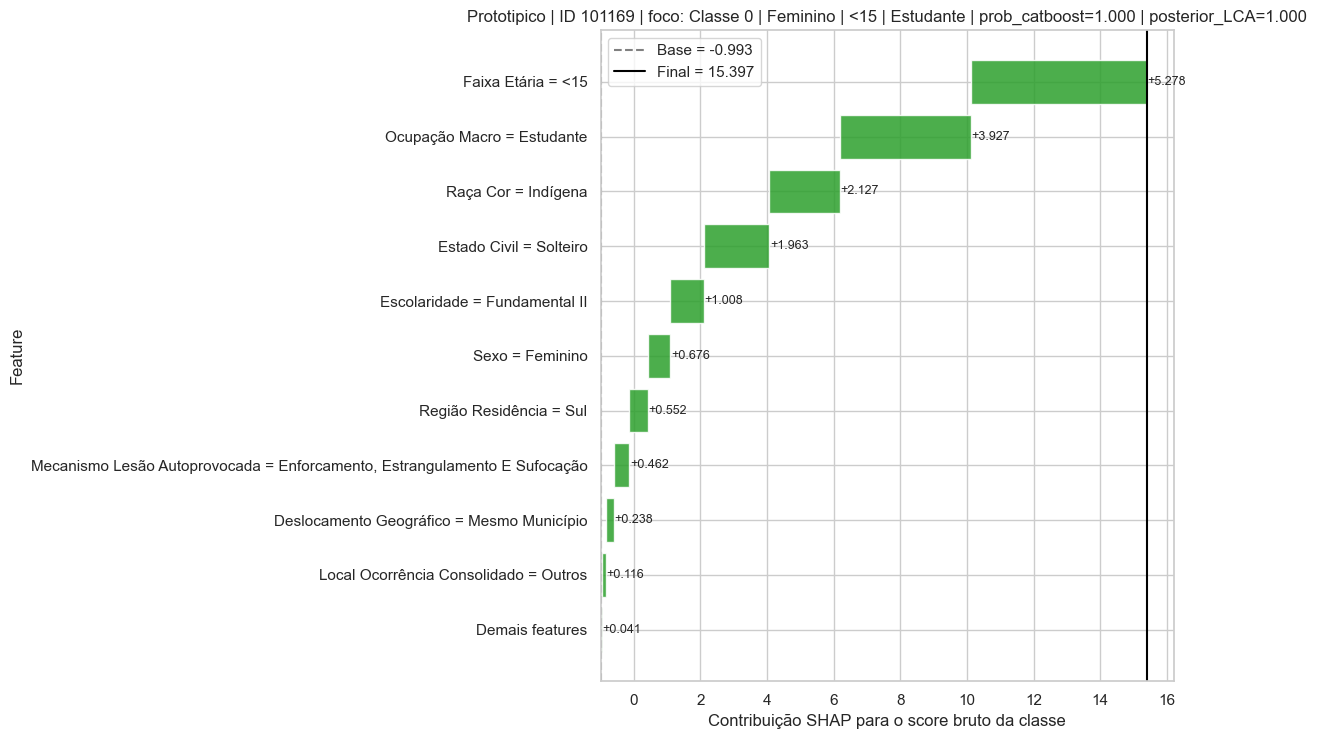

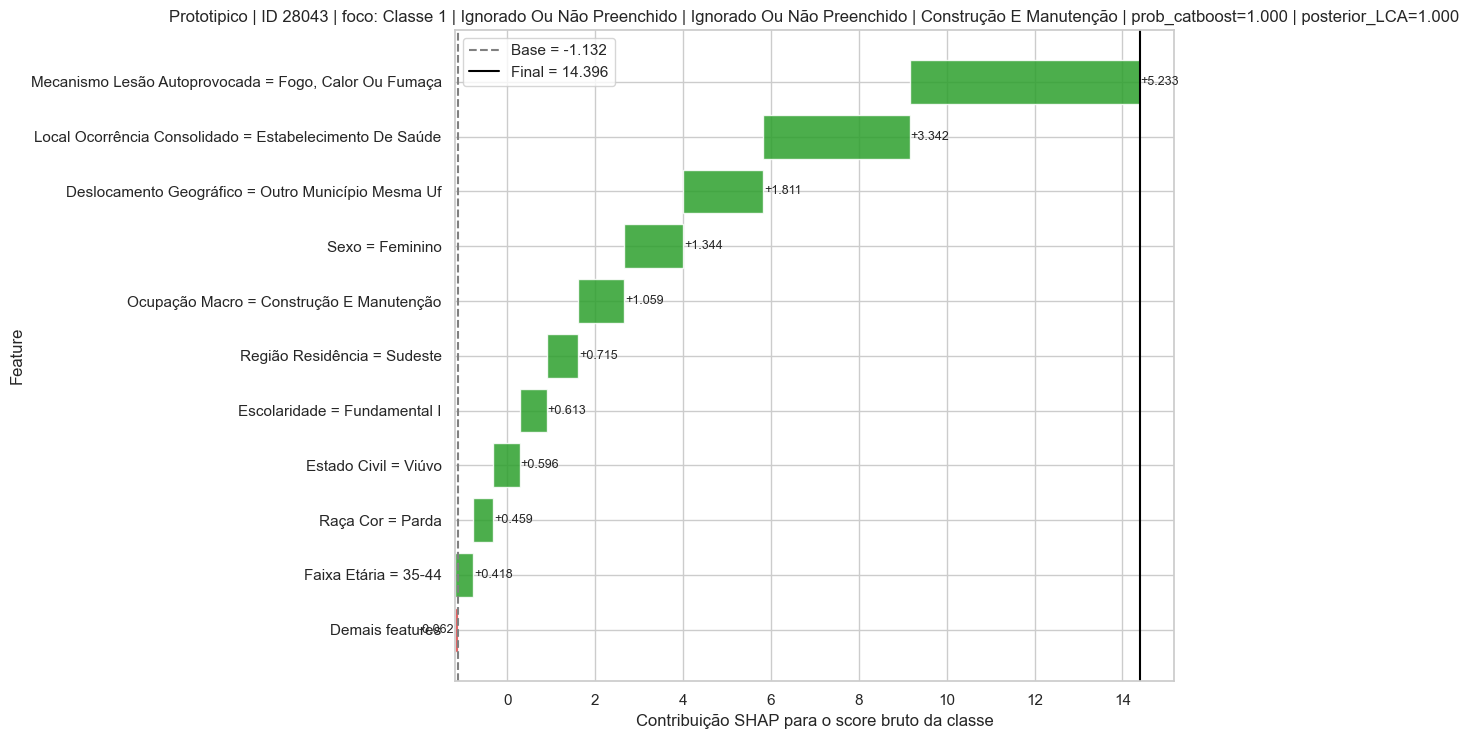

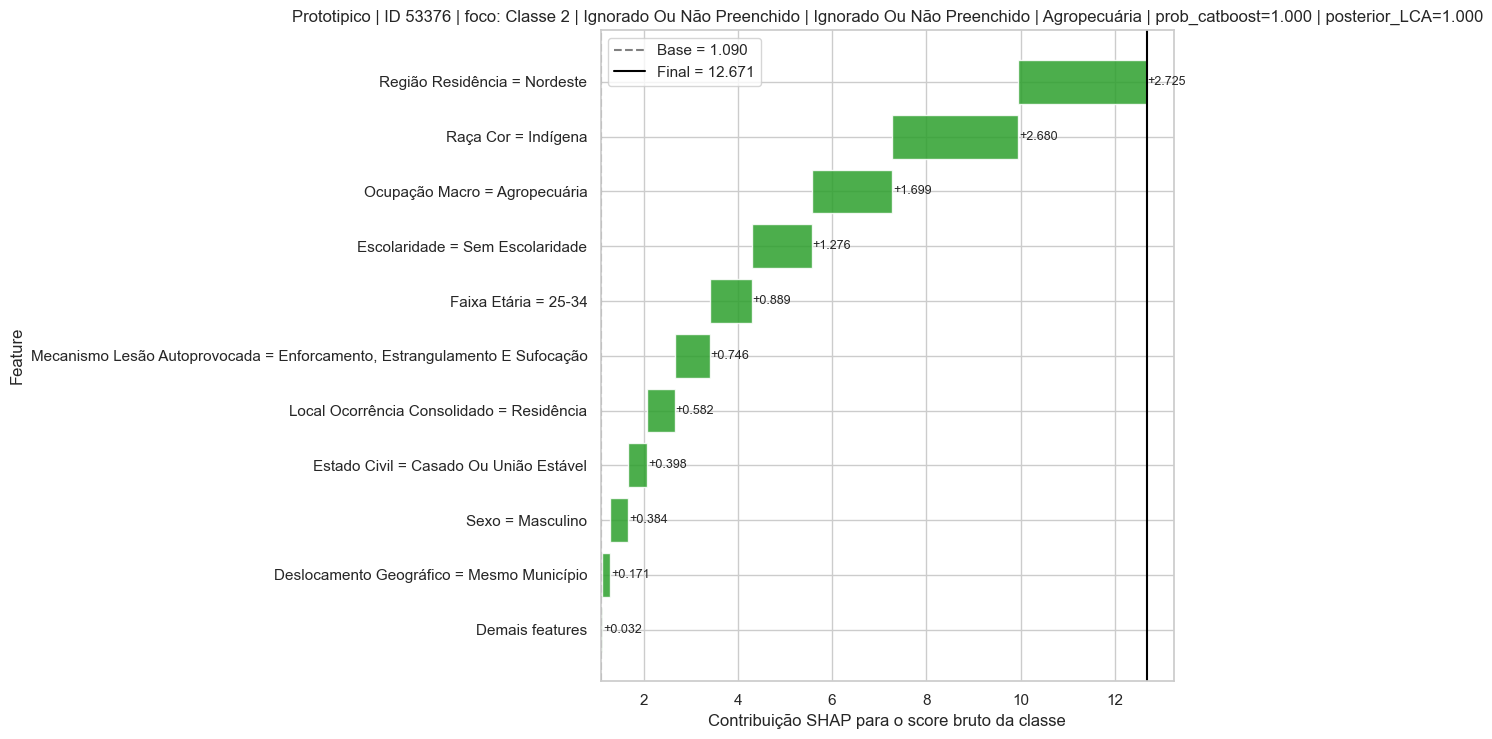

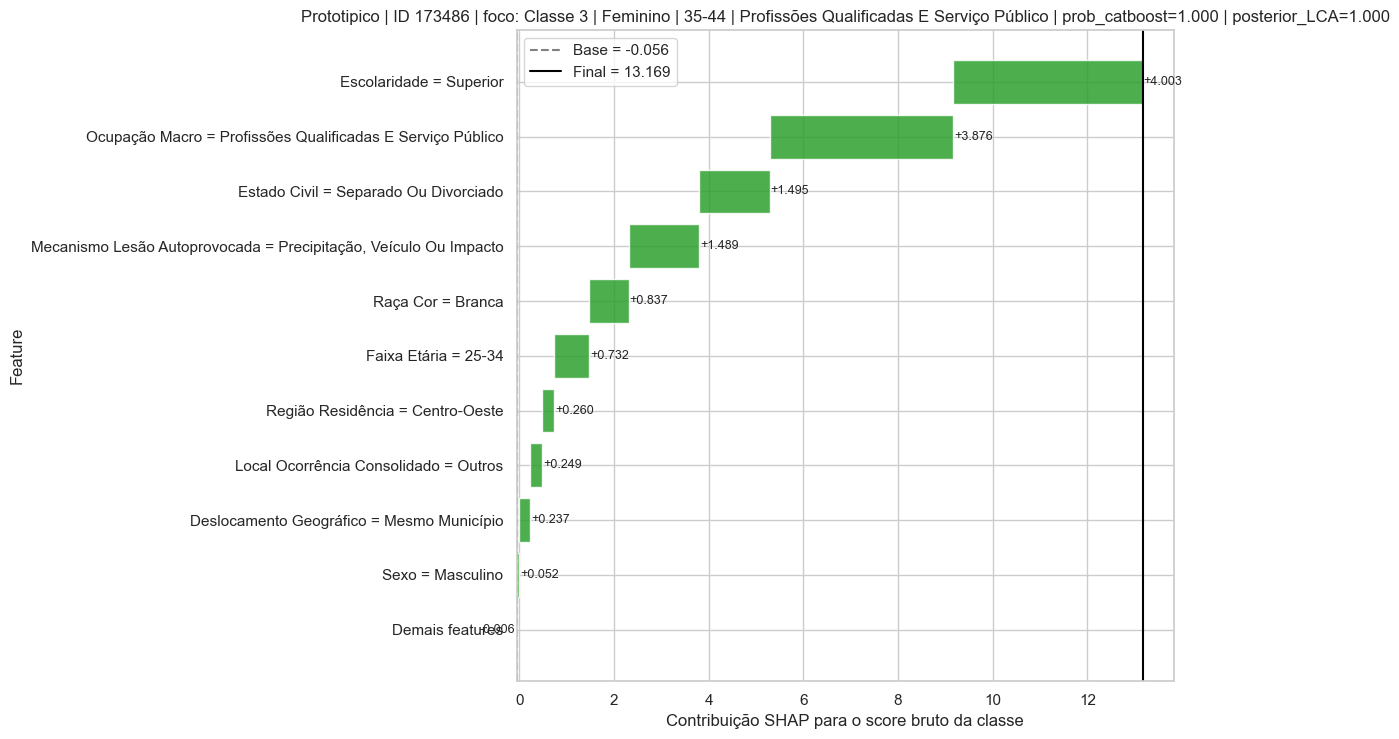

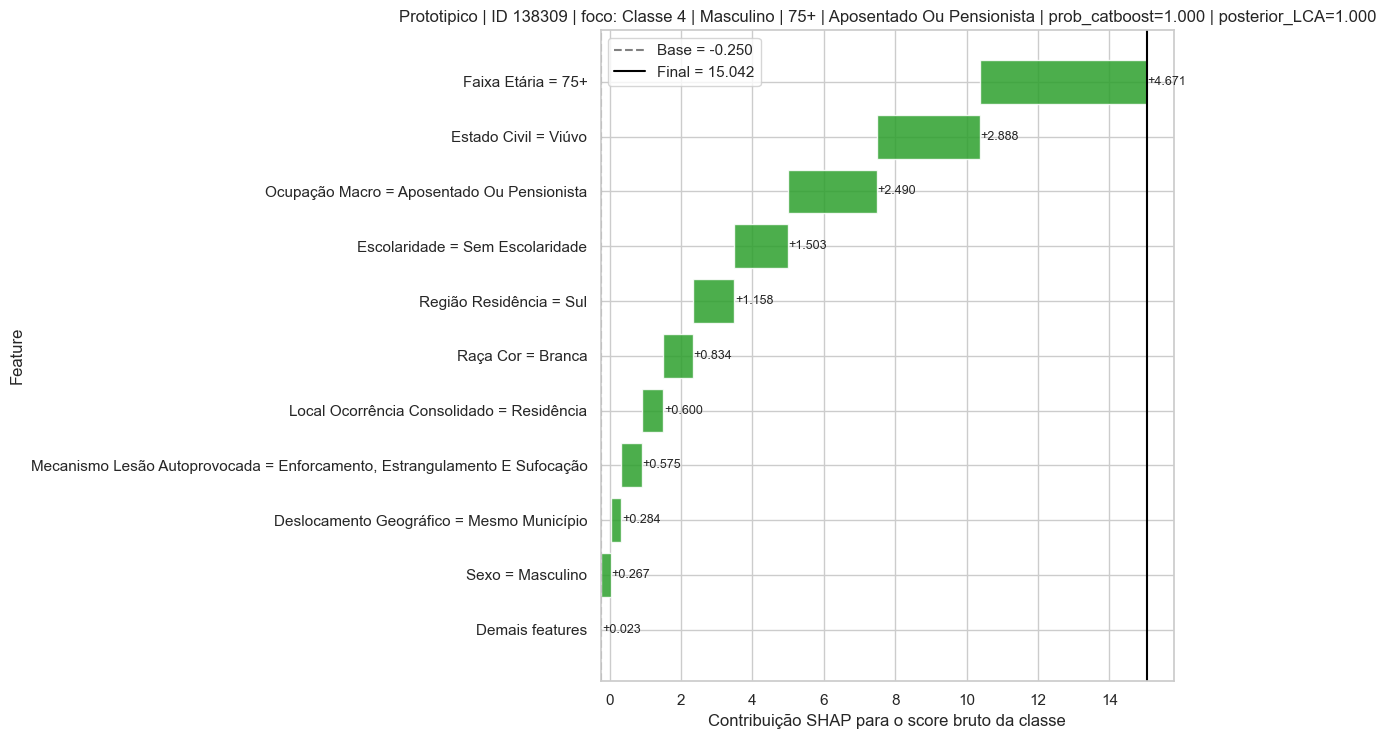

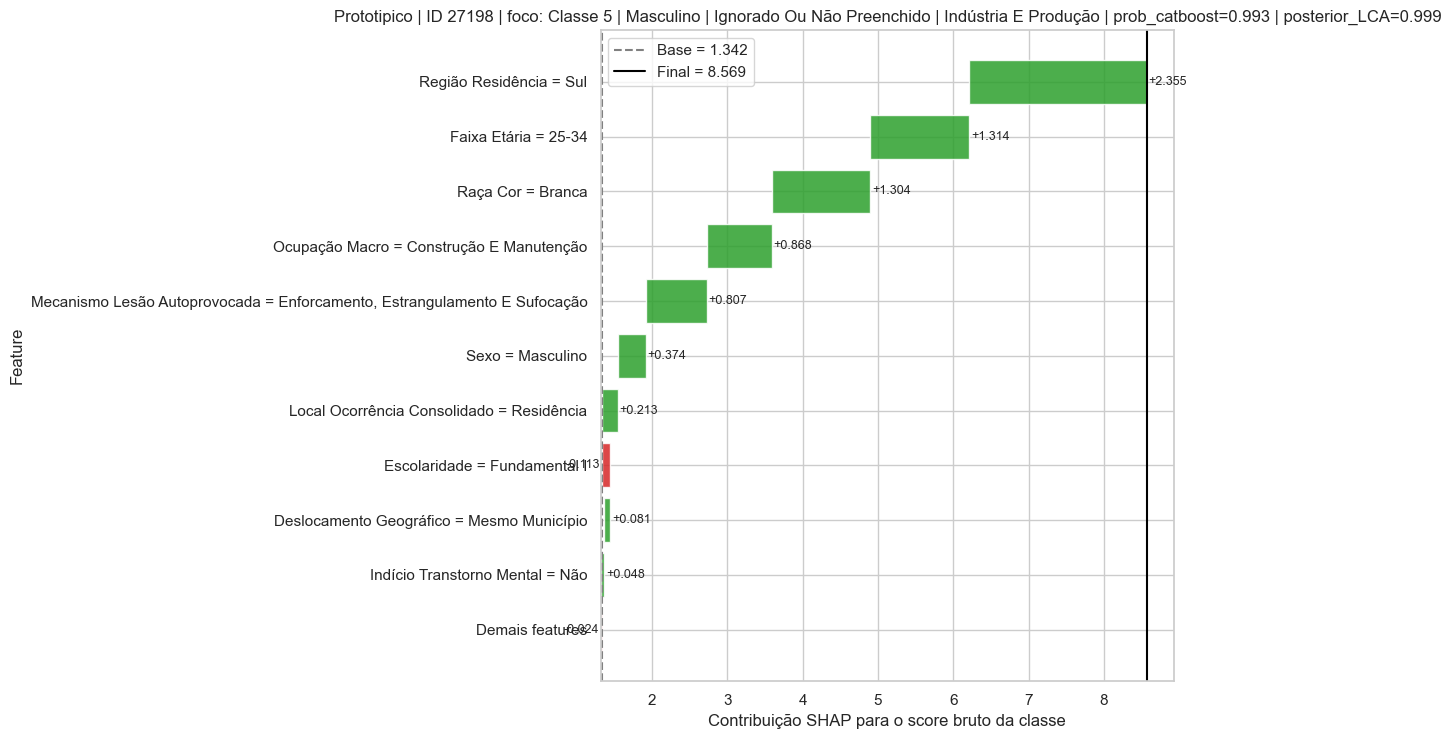

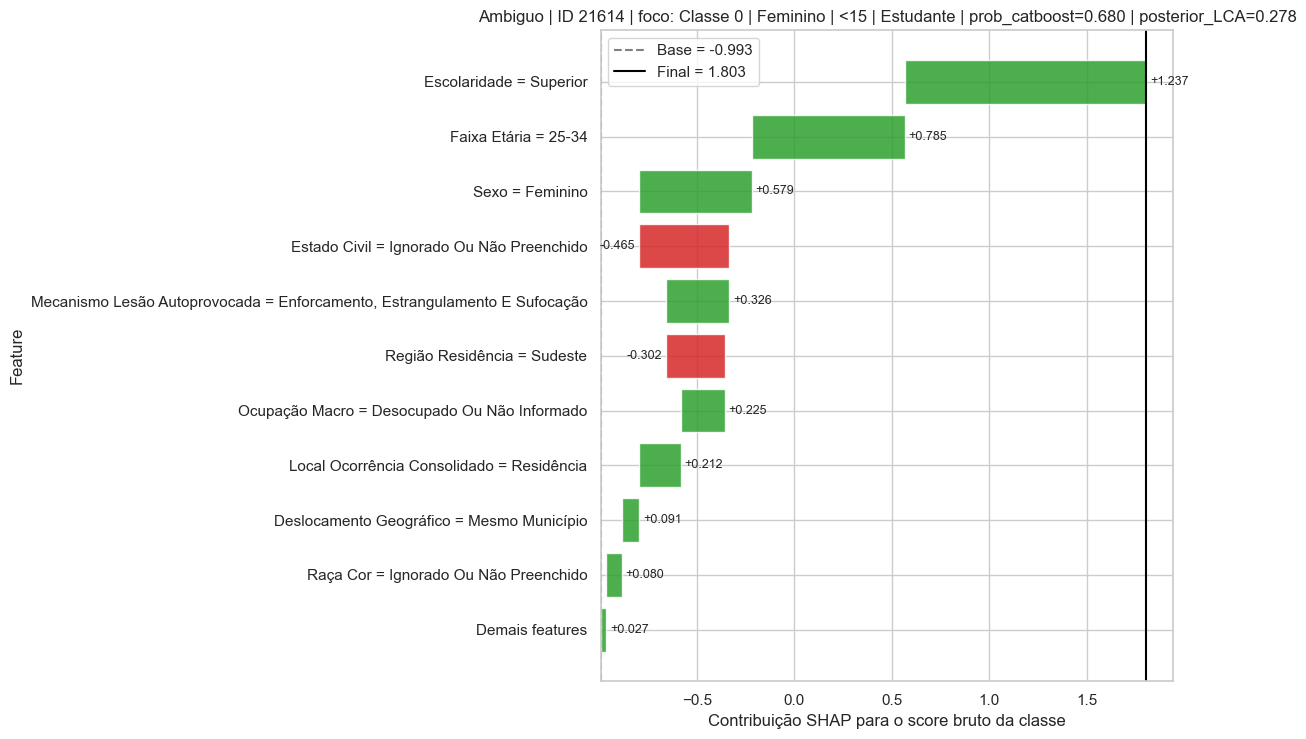

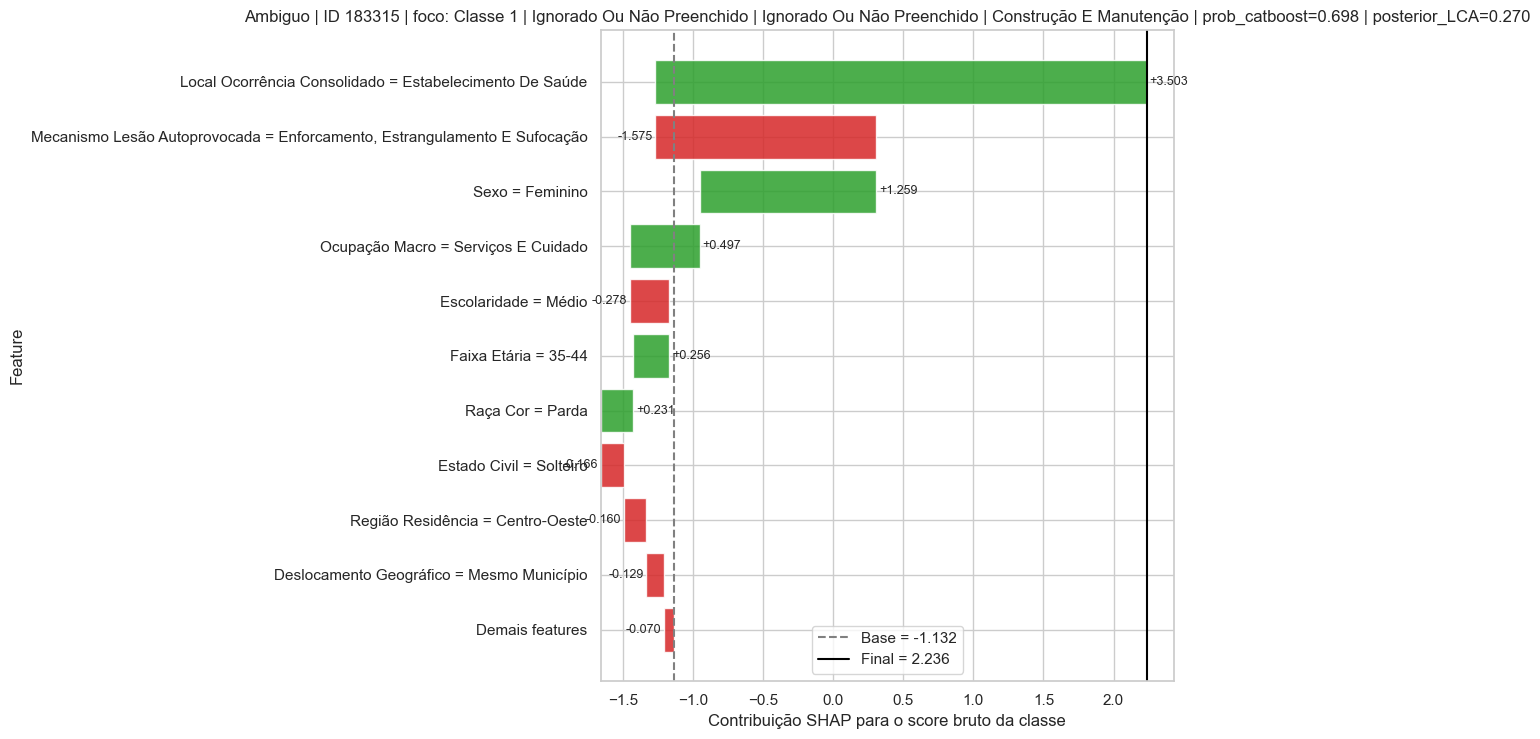

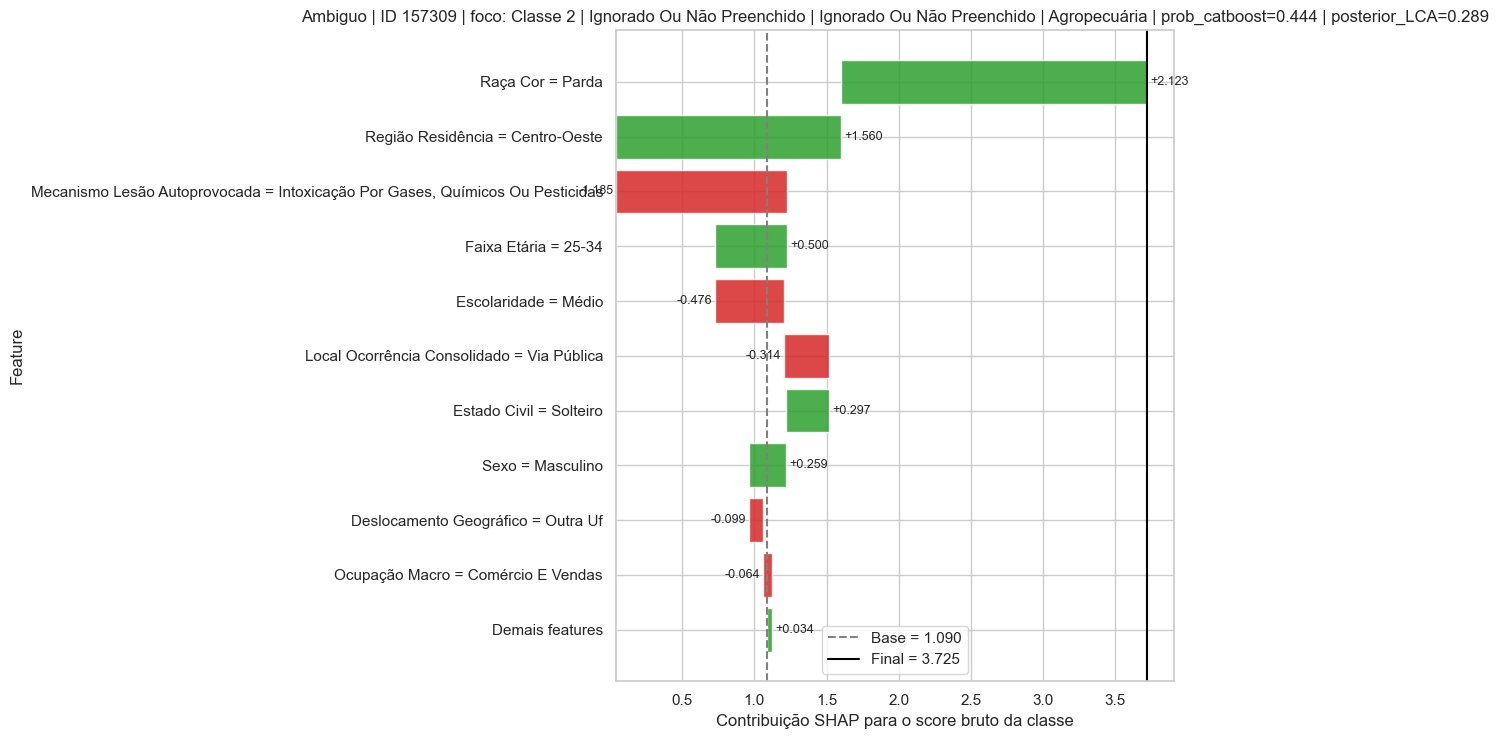

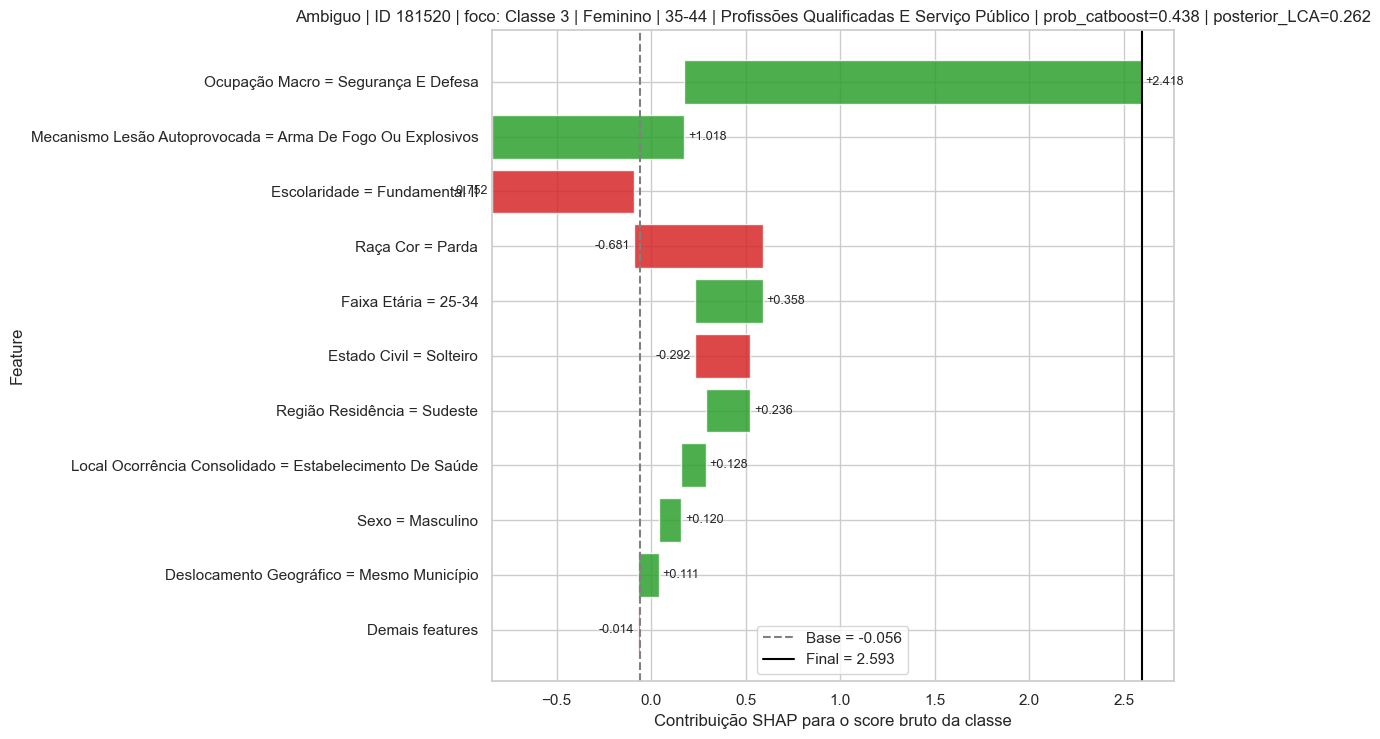

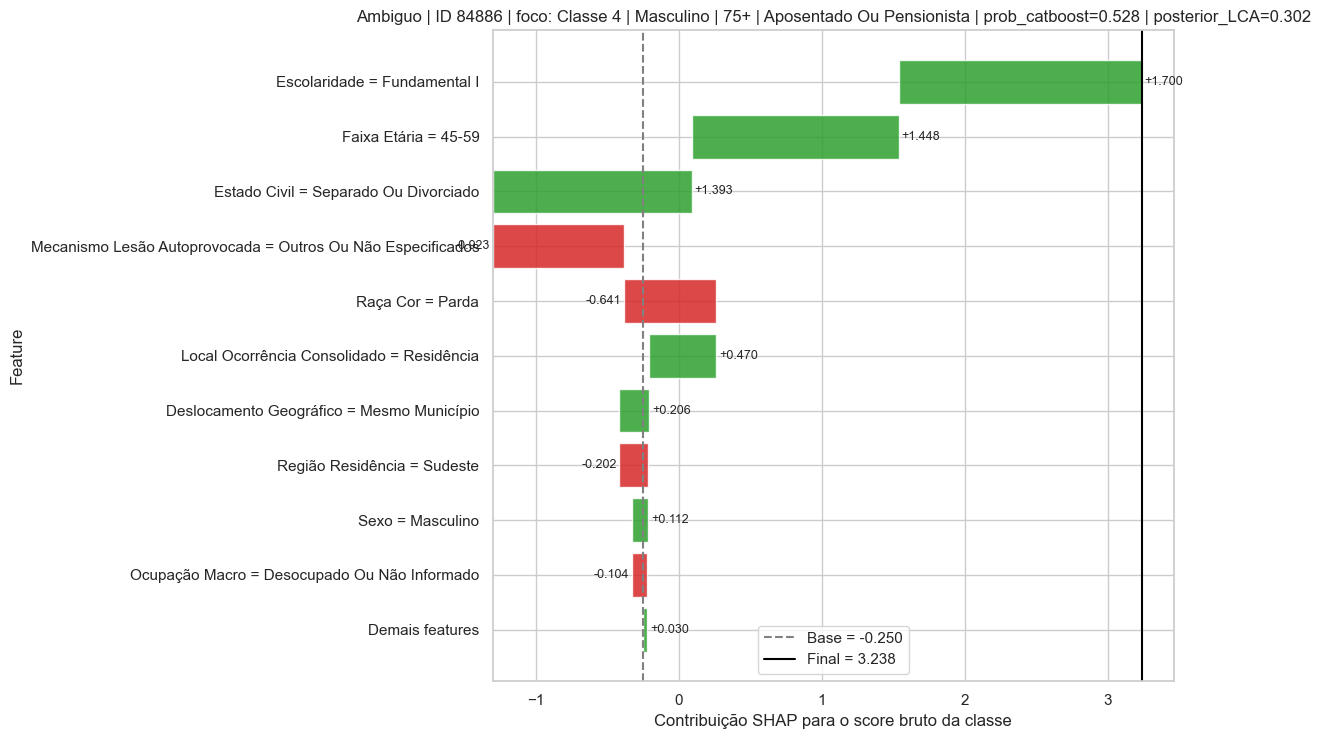

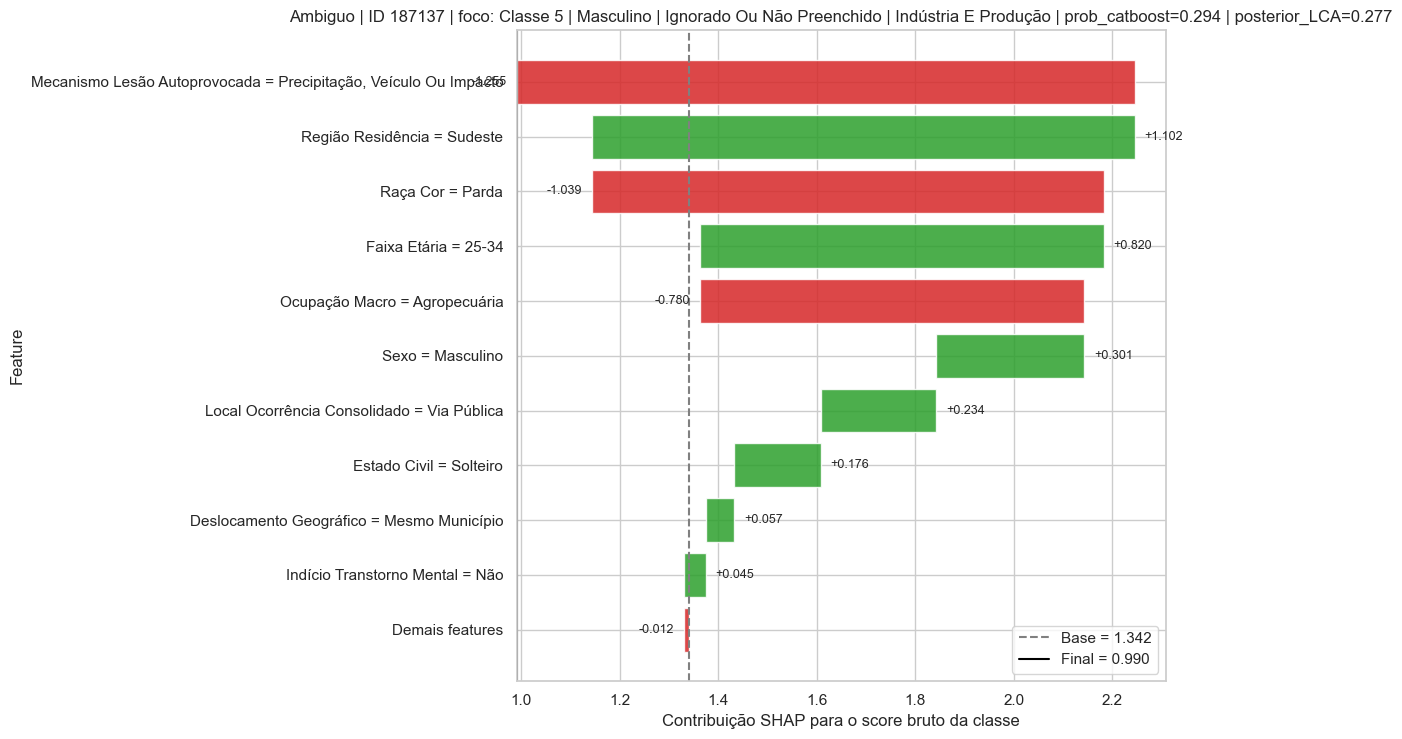

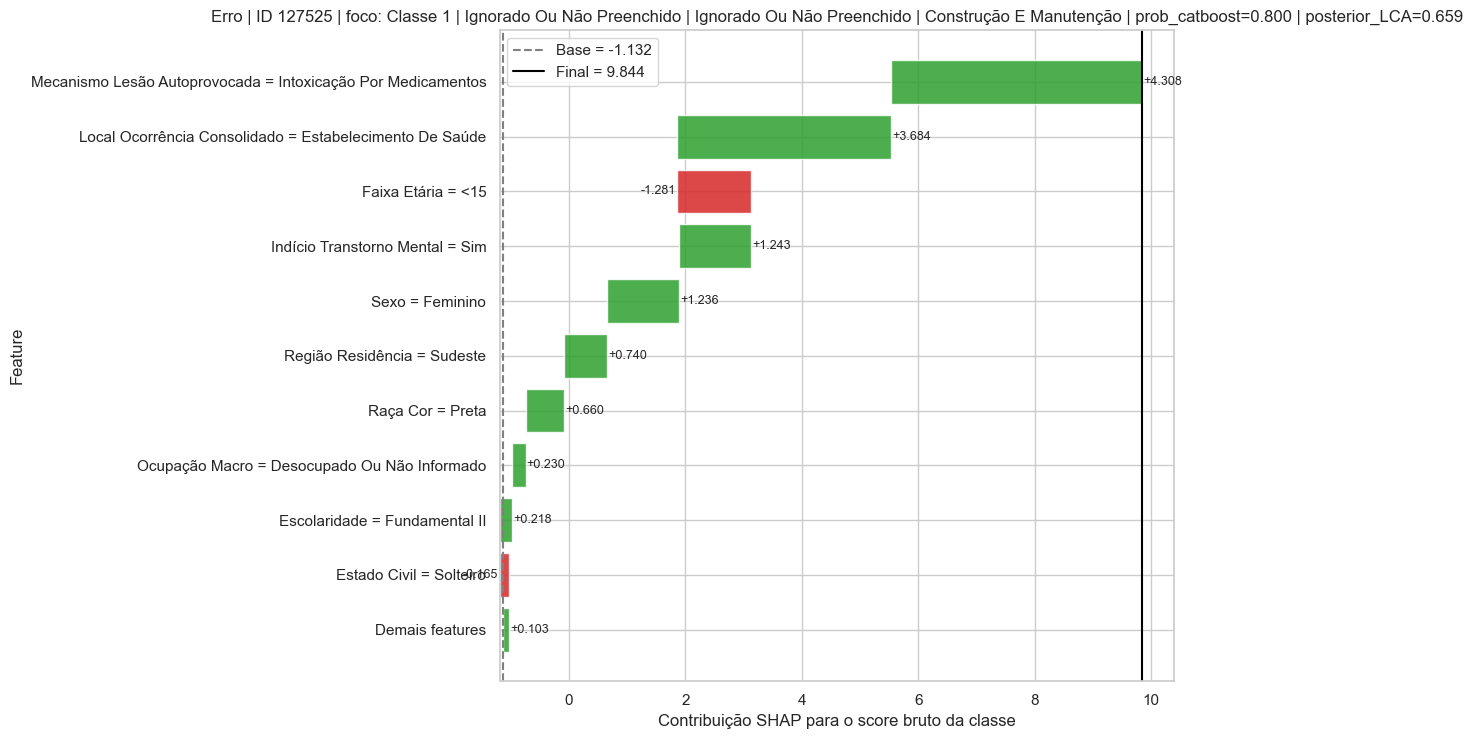

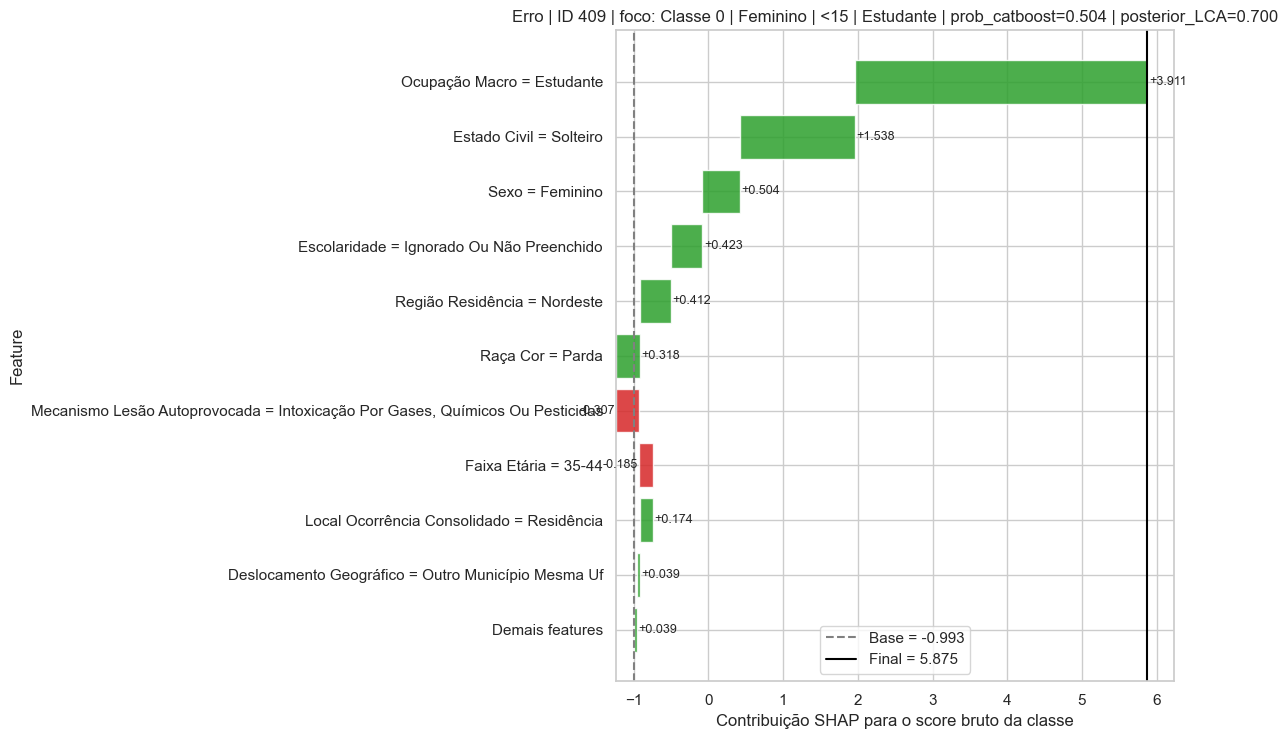

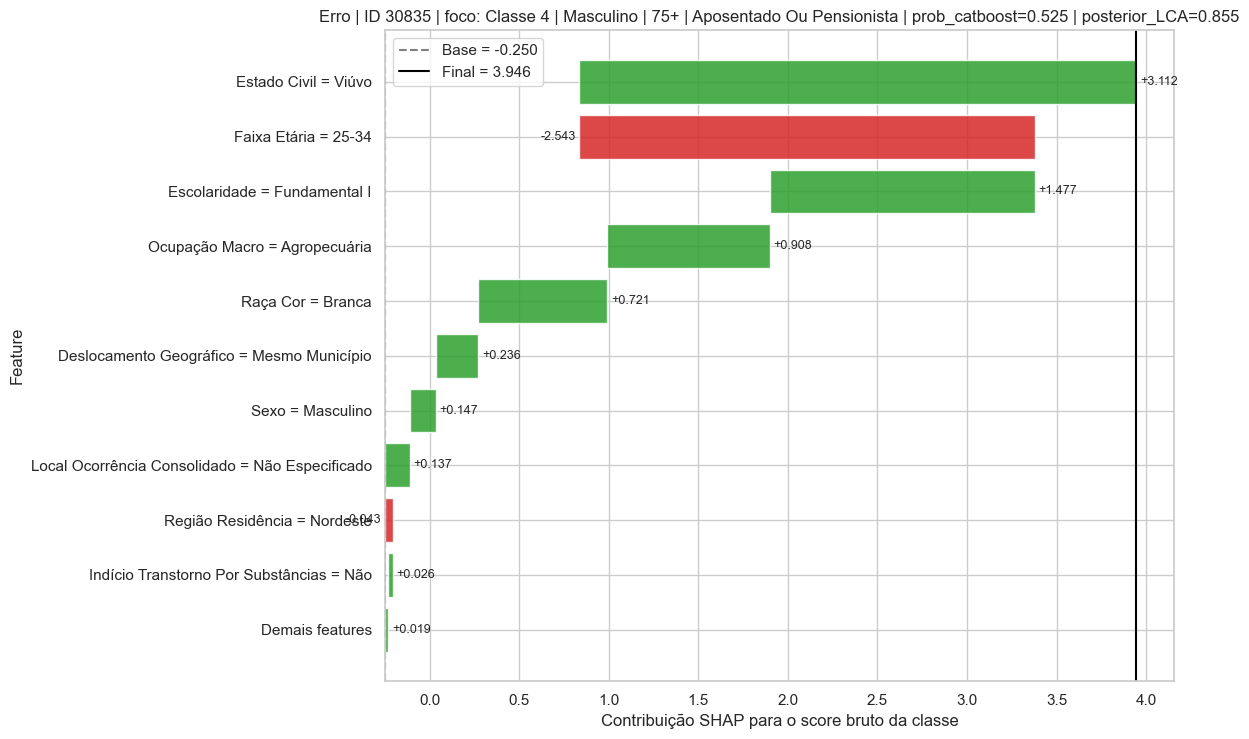

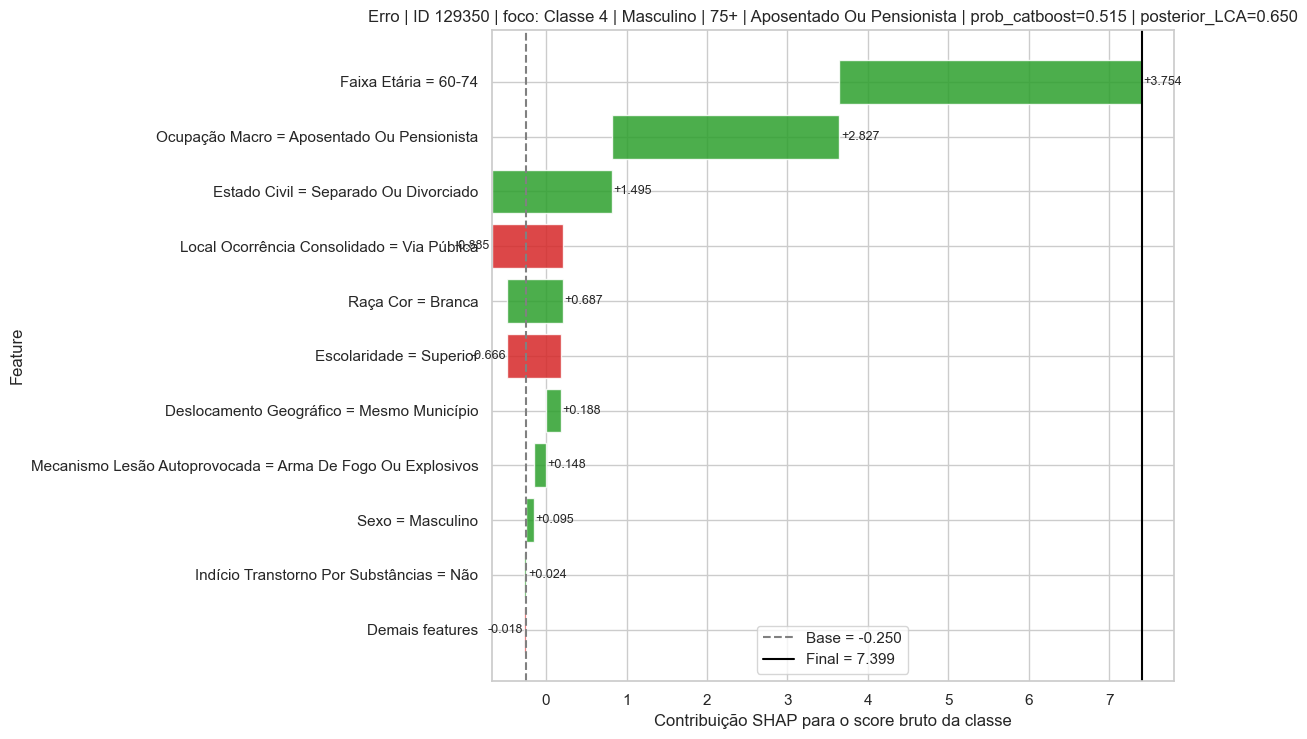

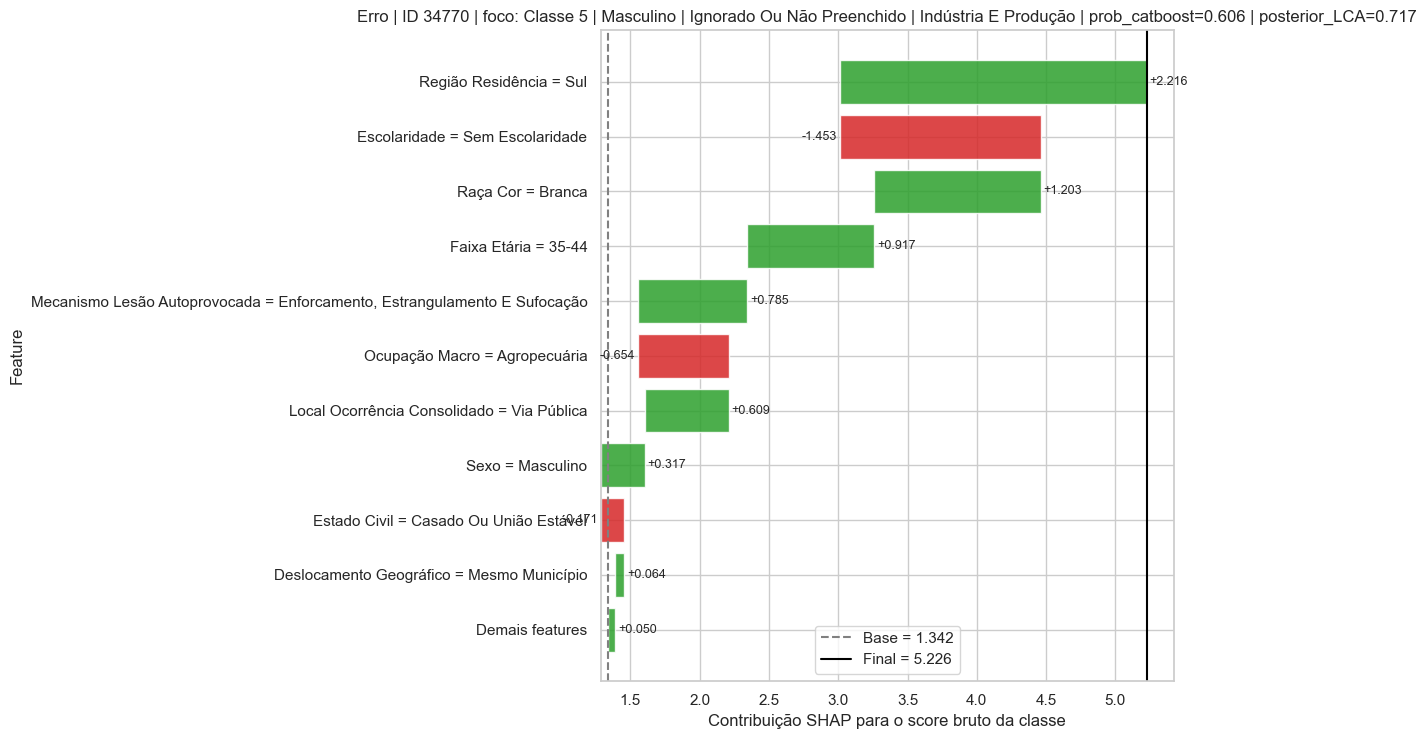

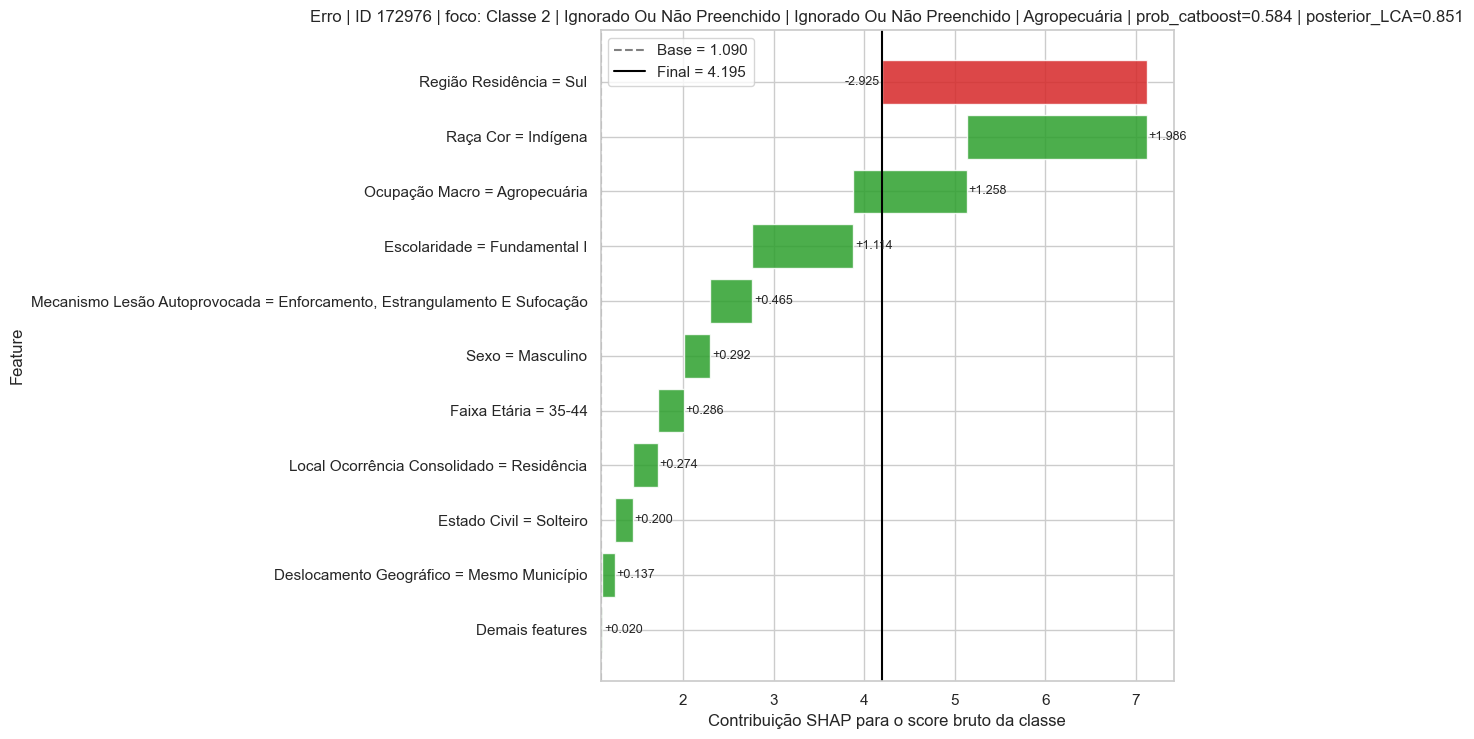

,id_registro,tipo_caso,classe_lca,classe_prevista_catboost,classe_foco_explicacao,base_value,final_value,prob_max_catboost,posterior_max,arquivo_plot
0,101169,prototipico,0,0,0,-0.992549,15.396943,1.000000,1.000000,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_0_classe_foco_0_id_101169.png
1,28043,prototipico,1,1,1,-1.132374,14.395703,1.000000,0.999977,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_1_classe_foco_1_id_28043.png
2,53376,prototipico,2,2,2,1.089678,12.671041,0.999997,0.999972,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_2_classe_foco_2_id_53376.png
3,173486,prototipico,3,3,3,-0.056202,13.168832,0.999999,0.999856,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_3_classe_foco_3_id_173486.png
4,138309,prototipico,4,4,4,-0.250253,15.041969,1.000000,0.999998,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_4_classe_foco_4_id_138309.png
5,27198,prototipico,5,5,5,1.341700,8.568604,0.993178,0.999256,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_prototipico_classe_real_5_classe_foco_5_id_27198.png
6,21614,ambiguo,0,3,0,-0.992549,1.803295,0.680097,0.278241,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_ambiguo_classe_real_0_classe_foco_0_id_21614.png
7,183315,ambiguo,1,0,1,-1.132374,2.235978,0.697673,0.269710,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_ambiguo_classe_real_1_classe_foco_1_id_183315.png
8,157309,ambiguo,2,1,2,1.089678,3.725022,0.444488,0.289184,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_ambiguo_classe_real_2_classe_foco_2_id_157309.png
9,181520,ambiguo,3,3,3,-0.056202,2.593000,0.438457,0.262383,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\figuras\waterfall_ambiguo_classe_real_3_classe_foco_3_id_181520.png


In [19]:
def plot_local_waterfall(
    case_series: pd.Series,
    shap_vector: np.ndarray,
    base_value: float,
    title: str,
    filename: str,
    top_n: int = LOCAL_TOP_FEATURES_WATERFALL,
) -> dict[str, float]:
    shap_vector = np.asarray(shap_vector, dtype=float)
    order = np.argsort(np.abs(shap_vector))[::-1]
    top_idx = order[:top_n]
    remaining_idx = order[top_n:]

    labels = [f"{FEATURE_COLUMNS[idx]} = {case_series[FEATURE_COLUMNS[idx]]}" for idx in top_idx]
    contributions = [float(shap_vector[idx]) for idx in top_idx]
    if len(remaining_idx) > 0:
        labels.append("Demais features")
        contributions.append(float(shap_vector[remaining_idx].sum()))

    display_labels = labels[::-1]
    display_values = contributions[::-1]

    current = float(base_value)
    starts = []
    widths = []
    colors = []
    ends = []
    for value in display_values:
        start = current if value >= 0 else current + value
        end = current + value
        starts.append(start)
        widths.append(abs(value))
        colors.append("#2ca02c" if value >= 0 else "#d62728")
        ends.append(end)
        current = end

    final_value = float(current)
    y_positions = np.arange(len(display_labels))

    fig, ax = plt.subplots(figsize=(12, max(4.5, len(display_labels) * 0.55 + 1.5)))
    for idx, (label, start, width, color, end, value) in enumerate(zip(display_labels, starts, widths, colors, ends, display_values)):
        ax.barh(idx, width, left=start, color=color, alpha=0.85)
        text_x = end + 0.02 if value >= 0 else end - 0.02
        ha = "left" if value >= 0 else "right"
        ax.text(text_x, idx, f"{value:+.3f}", va="center", ha=ha, fontsize=9)

    ax.axvline(base_value, color="gray", linestyle="--", linewidth=1.5, label=f"Base = {base_value:.3f}")
    ax.axvline(final_value, color="black", linestyle="-", linewidth=1.5, label=f"Final = {final_value:.3f}")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(display_labels)
    ax.set_xlabel("Contribuição SHAP para o score bruto da classe")
    ax.set_ylabel("Feature")
    ax.set_title(title)
    ax.legend(loc="best")
    fig.tight_layout()
    save_figure(fig, filename, normalize_text(filename))
    plt.show()
    plt.close(fig)

    return {"base_value": float(base_value), "final_value": float(final_value)}


local_explanation_rows = []
if not selected_local_cases_df.empty:
    selected_local_cases_for_shap_df = selected_local_cases_df.reset_index(drop=True).copy()
    _, local_shap_values_list, _ = compute_native_shap_values(
        final_model,
        selected_local_cases_for_shap_df.loc[:, FEATURE_COLUMNS],
        feature_columns=FEATURE_COLUMNS,
        class_labels=class_labels,
        batch_size=max(1, min(LOCAL_SHAP_BATCH_SIZE, len(selected_local_cases_for_shap_df))),
        progress_label="SHAP local",
    )

    for case_idx, case_row in selected_local_cases_for_shap_df.iterrows():
        target_class = int(case_row["classe_foco_explicacao"])
        class_pos = class_to_position[target_class]
        shap_vector = local_shap_values_list[class_pos].iloc[case_idx].to_numpy(dtype=float)
        base_value = expected_values_map[target_class]

        title = (
            f"{case_row['tipo_caso'].title()} | ID {int(case_row['id_registro'])} | "
            f"foco: {class_profile_map[target_class]} | "
            f"prob_catboost={case_row['prob_max_catboost']:.3f} | posterior_LCA={case_row['posterior_max']:.3f}"
        )
        filename = (
            f"waterfall_{normalize_text(case_row['tipo_caso'])}_"
            f"classe_real_{int(case_row['classe_lca'])}_"
            f"classe_foco_{target_class}_"
            f"id_{int(case_row['id_registro'])}.png"
        )

        waterfall_meta = plot_local_waterfall(
            case_series=case_row,
            shap_vector=shap_vector,
            base_value=base_value,
            title=title,
            filename=filename,
        )
        local_explanation_rows.append(
            {
                "id_registro": int(case_row["id_registro"]),
                "tipo_caso": case_row["tipo_caso"],
                "classe_lca": int(case_row["classe_lca"]),
                "classe_prevista_catboost": int(case_row["classe_prevista_catboost"]),
                "classe_foco_explicacao": target_class,
                "base_value": waterfall_meta["base_value"],
                "final_value": waterfall_meta["final_value"],
                "prob_max_catboost": float(case_row["prob_max_catboost"]),
                "posterior_max": float(case_row["posterior_max"]),
                "arquivo_plot": str((FIG_DIR / filename).resolve()),
            }
        )

local_explanations_summary_df = pd.DataFrame(local_explanation_rows)
if not local_explanations_summary_df.empty:
    display(local_explanations_summary_df)
    save_table(local_explanations_summary_df, TABLE_DIR / "explicacoes_locais_resumo.csv")


In [20]:
def top_features_text(df: pd.DataFrame, n: int = 5) -> str:
    return ", ".join(df["feature"].head(n).tolist())


easiest_classes_df = test_metrics["per_class_df"].sort_values(
    ["f1", "recall", "precision"],
    ascending=[False, False, False],
).head(2)
hardest_classes_df = test_metrics["per_class_df"].sort_values(
    ["f1", "recall", "precision"],
    ascending=[True, True, True],
).head(2)

per_class_top_features_lines = []
for cls in class_labels:
    top_features_cls = (
        per_class_shap_importance_df[per_class_shap_importance_df["classe_lca"] == cls]
        .sort_values("mean_abs_shap", ascending=False)
        .head(3)["feature"]
        .tolist()
    )
    per_class_top_features_lines.append(
        f"- Classe {cls} ({class_name_map[int(cls)]}): {', '.join(top_features_cls)}"
    )

summary_lines = [
    "Resumo automático do surrogate multiclasse do Perfil Integrado (K=6)",
    "",
    f"Número de registros usados: {len(modeling_df):,}".replace(",", "."),
    "Distribuição das classes:",
]
summary_lines.extend(
    [
        f"- Classe {int(row.classe_lca)} ({class_name_map[int(row.classe_lca)]}): "
        f"{int(row.n_registros):,} registros ({row.proporcao:.2%})".replace(",", ".")
        for row in class_distribution_df.itertuples()
    ]
)
summary_lines.extend(
    [
        "",
        f"Cenário vencedor do CatBoost: {best_scenario_name} ({best_scenario_key})",
        (
            "Fidelity do surrogate ao LCA no teste: "
            f"accuracy={test_metrics['summary_metrics']['accuracy']:.4f}, "
            f"balanced_accuracy={test_metrics['summary_metrics']['balanced_accuracy']:.4f}, "
            f"macro_f1={test_metrics['summary_metrics']['macro_f1']:.4f}, "
            f"weighted_f1={test_metrics['summary_metrics']['weighted_f1']:.4f}"
        ),
        "Classes mais fáceis de reproduzir:",
    ]
)
summary_lines.extend(
    [
        f"- Classe {int(row.classe_lca)} ({class_name_map[int(row.classe_lca)]}) com F1={row.f1:.4f} e recall={row.recall:.4f}"
        for row in easiest_classes_df.itertuples()
    ]
)
summary_lines.append("Classes mais difíceis de reproduzir:")
summary_lines.extend(
    [
        f"- Classe {int(row.classe_lca)} ({class_name_map[int(row.classe_lca)]}) com F1={row.f1:.4f} e recall={row.recall:.4f}"
        for row in hardest_classes_df.itertuples()
    ]
)
summary_lines.extend(
    [
        "",
        f"Variáveis mais importantes globalmente (SHAP): {top_features_text(global_shap_importance_df, n=5)}",
        "Variáveis mais importantes por perfil:",
    ]
)
summary_lines.extend(per_class_top_features_lines)
summary_lines.extend(
    [
        "",
        f"Diagnóstico final: {determine_xai_readiness(test_metrics['summary_metrics'], test_metrics['per_class_df'])}",
    ]
)

summary_text = "\n".join(summary_lines)
print(summary_text)

summary_text_path = OUTPUT_ROOT / "resumo_automatico_final.txt"
save_text(summary_text, summary_text_path)

registry_csv_path = TABLE_DIR / "lista_arquivos_gerados.csv"
registry_json_path = TABLE_DIR / "lista_arquivos_gerados.json"

preliminary_registry_df = pd.DataFrame(GENERATED_FILES).drop_duplicates().sort_values(
    ["tipo", "artefato", "caminho"]
).reset_index(drop=True)
save_table(preliminary_registry_df, registry_csv_path)
save_json(preliminary_registry_df.to_dict(orient="records"), registry_json_path)

payload = {
    "configuracao": {
        "expected_k": EXPECTED_K,
        "features": FEATURE_COLUMNS,
        "low_confidence_threshold": LOW_CONFIDENCE_THRESHOLD,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE,
        "catboost_params": CATBOOST_PARAMS,
        "scenarios": SCENARIOS,
    },
    "arquivos_entrada": INPUT_FILES,
    "cenario_vencedor": {
        "scenario_key": best_scenario_key,
        "scenario_nome": best_scenario_name,
        "best_iteration_referencia": best_reference_iteration,
    },
    "metricas_teste": test_metrics["summary_metrics"],
    "fidelity_nivel": determine_fidelity_level(test_metrics["summary_metrics"]),
    "xai_readiness": determine_xai_readiness(test_metrics["summary_metrics"], test_metrics["per_class_df"]),
    "variaveis_mais_importantes_globalmente": global_shap_importance_df.head(10),
    "variaveis_mais_importantes_por_classe": per_class_shap_importance_df.groupby("classe_lca").head(5),
    "top_interacoes": interaction_table_df.head(TOP_INTERACTIONS_TO_REPORT),
    "ale_features": ["Faixa Etária", "Escolaridade"],
    "resumo_automatico": summary_text,
    "arquivos_gerados": preliminary_registry_df,
}
save_json(payload, OUTPUT_ROOT / "resumo_execucao_surrogate_xai.json")

final_registry_df = pd.DataFrame(GENERATED_FILES).drop_duplicates().sort_values(
    ["tipo", "artefato", "caminho"]
).reset_index(drop=True)
save_table(final_registry_df, registry_csv_path)
save_json(final_registry_df.to_dict(orient="records"), registry_json_path)

display(final_registry_df.head(200))
print("Notebook concluído. Artefatos salvos em:", OUTPUT_ROOT)


Resumo automático do surrogate multiclasse do Perfil Integrado (K=6)

Número de registros usados: 191.025
Distribuição das classes:
- Classe 0 (Feminino | <15 | Estudante): 23.401 registros (12.25%)
- Classe 1 (Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção): 17.691 registros (9.26%)
- Classe 2 (Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária): 46.352 registros (24.26%)
- Classe 3 (Feminino | 35-44 | Profissões Qualificadas E Serviço Público): 21.874 registros (11.45%)
- Classe 4 (Masculino | 75+ | Aposentado Ou Pensionista): 30.076 registros (15.74%)
- Classe 5 (Masculino | Ignorado Ou Não Preenchido | Indústria E Produção): 51.631 registros (27.03%)

Cenário vencedor do CatBoost: Cenário A (A)
Fidelity do surrogate ao LCA no teste: accuracy=0.9797, balanced_accuracy=0.9777, macro_f1=0.9781, weighted_f1=0.9796
Classes mais fáceis de reproduzir:
- Classe 0 (Feminino | <15 | Estudante) com F1=0.9840 e recall=0.9840
- Classe 2 (Ig

,artefato,tipo,caminho
0,catboost_surrogate_final_perfil_integrado,cbm,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\modelos\catboost_surrogate_final_perfil_integrado.cbm
1,catboost_surrogate_validacao_cenario_A,cbm,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\modelos\catboost_surrogate_validacao_cenario_A.cbm
2,catboost_surrogate_validacao_cenario_B,cbm,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\modelos\catboost_surrogate_validacao_cenario_B.cbm
3,ale_escolaridade,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\ale_escolaridade.csv
4,ale_escolaridade_deltas,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\ale_escolaridade_deltas.csv
5,ale_faixa_etaria,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\ale_faixa_etaria.csv
6,ale_faixa_etaria_deltas,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\ale_faixa_etaria_deltas.csv
7,avaliacao_por_classe_teste,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\avaliacao_por_classe_teste.csv
8,avaliacao_por_classe_validacao_cenario_A,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\avaliacao_por_classe_validacao_cenario_A.csv
9,avaliacao_por_classe_validacao_cenario_B,csv,C:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai\tabelas\avaliacao_por_classe_validacao_cenario_B.csv


Notebook concluído. Artefatos salvos em: c:\Users\anami\Downloads\TCC Aninha\outputs_surrogate_perfil_integrado_xai
